# 🏆 Milestone 3 — Add in Some Machine Learning  

## 1️⃣ Summary of Process

- ✅ **Restate business problem and current research question (early exploration & engagement ↔ purchase)**  
  The original business question—how product assortment complexity affects purchase likelihood—remains the foundation, but the EDA reframed the emphasis.  
  Evidence shows that **engagement intensity** (how quickly and actively users browse) is the primary behavioral driver of conversion.  
  The refined research question now asks whether early exploration breadth (`Breadth_T`) still adds predictive value **after controlling for browsing pace and engagement**.  
  *_(Updated framing: from “assortment complexity ↔ purchase” to “early exploration and engagement ↔ purchase.”)_*

- ✅ **Data cleaning / munging recap (typed schema, missingness, duplicates, sessionization)**  
  The preprocessing pipeline (Cells 0–6) enforces a typed schema, removes exact duplicates, validates session boundaries, and produces **leak-free session-level features**.  
  Missingness checks (V6) confirmed **no missing values** across months, verifying cache consistency and the reliability of downstream features.

- ✅ **EDA highlights and insights (funnels, distributions, inverted-U visuals, cohort checks)**  
  - **Distributions (V1–V2):** Heavy right-skew across Breadth_T, CatSwitchRate_T, and ViewPace_T, indicating most sessions are short and low-activity.  
  - **Stratified curves (V3):** Day-part and category-switching cohorts follow the same flat shape; time of day shifts baseline conversion but not trend.  
  - **Heatmap (V4):** Highest purchase rates occur at **moderate breadth + high pace**, showing that quick but focused browsing predicts buying.  
  - **Funnels (V5):** The biggest loss occurs at **view → cart**, not checkout—conversion friction lies in early engagement.  
  - **Correlations & MI (V6–V7):** Engagement metrics (`EventsPerMin`, `ViewPace_T`, `SessionDurationMin`) dominate predictive strength;  
    the **inverted-U effect** for `Breadth_T` is present but **weak** once engagement is accounted for.




## 2️⃣ Research Question (ML Re-Framing)

- **Task type**: Binary classification — predict whether a session ends in at least one purchase (PurchaseInSession ∈ {0,1}).

- **Predictors**:
  Early-session behavioral and engagement features computed over the - first T = 5 minutes:
```
   - Breadth_T
   - ViewPace_T
   - EarlyCart_T
   - CatSwitchRate_T
   - AnySwitch_T
   - PaceSlack_T

Engineered indicators:
  - ZeroBreadth_T  # marks sessions with no early exploration
```



- **session controls**:
```
`SessionDurationMin`, `EventsPerMin`, `DayPart`, `DayOfWeek`, `MeanLogPrice_1min`, `category_top`
```

- **Revised research question**:

> Given only the first T=5 min of a session, how do breadth of exploration and viewing pace jointly shape the probability of same‑session purchase—after controlling for engagement intensity, early carting, time effects, and category context—and is there an inverted‑U for breadth conditioned on pace?

- **Behavioral hypotheses (revised based on EDA):**
    - `PaceSlack_T = ViewPace_T − 0.2 × Breadth_T` (T = 5 min window).  
    - `ZeroBreadth_T = 1(Breadth_T == 0)` marks no early exploration.  
    - `AnySwitch_T = 1(CatSwitchRate_T > 0)` replaces the full rate for stability.

    ---

    H1 — Breadth has an inverted‑U on Breadth ≥ 1

    - **H₀:** The effect of `Breadth_T` on purchase is monotonic after controls.  
    - **H₁:** `Breadth_T` shows a **non‑monotonic** pattern — purchase probability peaks at **low‑to‑moderate breadth** (≈ 1–3 distinct categories) then declines.  
    - **Test:** Logit‑GAM spline on `Breadth_T` (Breadth ≥ 1) with `ZeroBreadth_T` intercept. Reject H₀ if curvature < 0 around the interior maximum and the high‑breadth tail is significantly lower than the peak.

    ---

    H2 — Pace slack helps, with diminishing returns

    - **H₀:** `PaceSlack_T` has no association with purchase after controls.  
    - **H₁:** Moderate positive `PaceSlack_T` improves purchase likelihood, but the **marginal gain flattens** or slightly declines at high slack.  
    - **Test:** Spline on `PaceSlack_T`; verify derivative > 0 for 0 → Q75 and ≤ 0 beyond Q90. Confirm using PDP/ICE.

    ---

    H3 — Breadth × PaceSlack interaction (“fast‑focused” > “slow‑scatter”)

    - **H₀:** The effect of `PaceSlack_T` does not depend on `Breadth_T`.  
    - **H₁:** **Interaction present.** Lift from `PaceSlack_T` is strongest at **low breadth** and weakens or reverses at high breadth.  
    - **Segment view:**  
      - *Fast‑focused:* `Breadth_T ≤ 2` and `PaceSlack_T > 0`  
      - *Slow‑scatter:* `Breadth_T ≥ 5` and `PaceSlack_T ≤ 0`  
        Expect \(p(	ext{purchase})\) ↑ for fast‑focused vs slow‑scatter, holding controls constant.  
    - **Test:** 2‑D spline `te(Breadth_T, PaceSlack_T)`; inspect cross‑partial pattern and bootstrap the segment Δ‑lift.

    ---

    H4 — Early carting amplifies breadth/pace effects

    - **H₀:** `EarlyCart_T` only shifts the intercept.  
    - **H₁:** `EarlyCart_T` **amplifies** the positive effect of `PaceSlack_T` and **softens** the decline at higher `Breadth_T`.  
    - **Test:** Include `EarlyCart_T × s(Breadth_T)` and `EarlyCart_T × s(PaceSlack_T)`; expect positive interaction surfaces and larger lift within early‑cart sessions.

    ---

  **Controls for all tests**  
  `EventsPerMin`, `SessionDurationMin`, `DayPart`, `DayOfWeek`, `MeanLogPrice_1min`, `category_top`, and train‑only category‑month funnel aggregates.

  **Evaluation focus**  
  Report **PR‑AUC** (primary) and **calibration**; break down results **by month** to check temporal stability.


## 3️⃣ Feature Engineering (Implementation) — **Execution Order & Status**

### **Prereq:** TRAIN/TEST combined files exist





#### 3.1 **Materialize core features (@ T=5)**  
   `Breadth_T, ViewPace_T, EventsPerMin, SessionDurationMin, CatSwitchRate_T, EarlyCart_T, MeanLogPrice_1min, DayPart, DayOfWeek, category_top`  
   *(present in per‑month and combined ENRICHED caches)*

>DONE ✅

#### 3.2 **Add engineered fields (raw units, before scaling)**  
   - `ZeroBreadth_T = 1(Breadth_T==0)`  
   - `AnySwitch_T = 1(CatSwitchRate_T>0)`  
   - `PaceSlack_T = ViewPace_T - 0.2*Breadth_T`  
   - `FastFocused_T = 1(ViewPace_T ≥ 1.2 and Breadth_T ≤ 2)`  

> DONE ✅

### 3.3  Prepping pipeline configuration ⚙️

In [14]:
# =========================
# Cell 12.0 — Write configm3.py (declaring GLOBALS)
# =========================
from pathlib import Path
import sys

# Define the project directory path
PROJECT_DIR = Path("../")

# Create the directory if it doesn't exist
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# Add the directory containing config.py to the Python path
config_path = Path(".")
if str(config_path) not in sys.path:
    sys.path.insert(0, str(config_path))

# Write / overwrite configm3.py with clear, single-source globals
(config_path / "configm3.py").write_text(f"""
from pathlib import Path

# --- Core project paths ---
PROJECT_DIR = Path(r"{PROJECT_DIR.as_posix()}")
DATA_DIR    = PROJECT_DIR / "data"
OUT_DIR     = PROJECT_DIR / "cache_data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Window + feature constants ---
T_MIN = 5
BREADTH_TO_PACE_COEFF = 1.0 / T_MIN  # -> 0.2 when T=5
FASTFOCUSED_PACE_MIN = 1.2
FASTFOCUSED_BREADTH_MAX = 2

# --- Splits ---
TRAIN_MONTHS = ("2019-Oct", "2019-Nov", "2019-Dec")
TEST_MONTHS  = ("2020-Jan", "2020-Feb", "2020-Mar")

# Canonical cache filenames (already built)
TRAIN_COMBINED_ENRICHED_TARGETS = (
    f"session_features_{{TRAIN_MONTHS[0]}}_to_{{TRAIN_MONTHS[-1]}}_T{{T_MIN}}_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet"
)
TEST_COMBINED_ENRICHED_TARGETS = (
    f"session_features_{{TEST_MONTHS[0]}}_to_{{TEST_MONTHS[-1]}}_T{{T_MIN}}_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet"
)

# Output suffix for engineered caches (we do NOT overwrite source)
ENGINEERED_SUFFIX = "_ENGINEERED"

# IO settings
OVERWRITE = True
PARQUET_COMPRESSION = "zstd"
""")

print("[12.0] Wrote configm3.py to", config_path / "configm3.py")


[12.0] Wrote configm3.py to configm3.py


In [15]:
# =========================
# Cell 12.1 — Boot + helpers (robust import; low-RAM safe)
# =========================
import importlib
from pathlib import Path
import polars as pl

try:
    # configm3.py is the Milestone-3 configuration module
    import configm3 as cfg
    importlib.reload(cfg)
except Exception as e:
    # `config_path` is expected to be defined in the notebook environment
    raise RuntimeError(f"[12.1] Could not import configm3.py from {config_path}: {e}")

# Ensure base directories from cfg exist
for p in [cfg.PROJECT_DIR, cfg.DATA_DIR, cfg.OUT_DIR]:
    Path(p).mkdir(parents=True, exist_ok=True)

from typing import Literal


def add_suffix(path: Path, suffix: str) -> Path:
    """
    Append a suffix to a file stem while preserving directory and extension.

    Example
    -------
    >>> add_suffix(Path("foo/bar.parquet"), "_ENGINEERED")
    Path("foo/bar_ENGINEERED.parquet")

    Parameters
    ----------
    path : pathlib.Path
        Original file path.
    suffix : str
        Suffix to append to the stem (e.g. "_ENGINEERED").

    Returns
    -------
    pathlib.Path
        New path with the suffix inserted before the file extension.
    """
    return path.with_name(path.stem + suffix + path.suffix)


def src_path(split: Literal["train", "test"] = "train") -> Path:
    """
    Return the source combined enriched targets path for a given split.

    Parameters
    ----------
    split : {"train", "test"}, default "train"
        Which dataset to use:
        * "train" → cfg.TRAIN_COMBINED_ENRICHED_TARGETS
        * "test"  → cfg.TEST_COMBINED_ENRICHED_TARGETS

    Returns
    -------
    pathlib.Path
        Path to the base combined enriched targets file under OUT_DIR.
    """
    fname = cfg.TRAIN_COMBINED_ENRICHED_TARGETS if split == "train" else cfg.TEST_COMBINED_ENRICHED_TARGETS
    return cfg.OUT_DIR / fname


def dst_path(split: Literal["train", "test"] = "train") -> Path:
    """
    Return the destination path for the engineered features file.

    This simply applies `cfg.ENGINEERED_SUFFIX` to the appropriate source
    combined enriched targets file.

    Parameters
    ----------
    split : {"train", "test"}, default "train"
        Which dataset to use as the source for engineering.

    Returns
    -------
    pathlib.Path
        Path to the engineered features Parquet file.
    """
    return add_suffix(src_path(split), cfg.ENGINEERED_SUFFIX)


# ---- Collect helper (no engine arg; safe fallbacks) ----
def collect_pl(q_or_lf):
    """
    Collect a Polars LazyFrame or expression with robust engine fallbacks.

    Preferred behavior is a plain ``.collect()`` call (Polars ≥0.19 style).
    For older Polars versions that still expect an `engine` keyword, this
    tries:

    1. ``collect(engine="old-streaming")``
    2. ``collect(streaming=True)``

    Parameters
    ----------
    q_or_lf : polars.LazyFrame | polars.Expr | LazyFrame-like
        A lazy query or LazyFrame to collect.

    Returns
    -------
    polars.DataFrame
        Eager DataFrame result.
    """
    try:
        return q_or_lf.collect()  # modern default
    except TypeError:
        try:
            return q_or_lf.collect(engine="old-streaming")
        except TypeError:
            return q_or_lf.collect(streaming=True)


def sink_lazyframe(lf: pl.LazyFrame, path: Path, compression: str = "zstd") -> None:
    """
    Materialize a LazyFrame to Parquet with streaming and safe fallbacks.

    Preferred approach is :meth:`LazyFrame.sink_parquet` (streaming, low-RAM).
    If that fails (e.g., due to engine incompatibilities), this falls back
    to collecting eagerly and then calling :meth:`DataFrame.write_parquet`.

    Parameters
    ----------
    lf : polars.LazyFrame
        LazyFrame to write.
    path : pathlib.Path
        Output path for the Parquet file.
    compression : str, default "zstd"
        Compression codec for Parquet (e.g., "zstd", "snappy").

    Side Effects
    ------------
    * Writes a Parquet file to `path` (possibly via a DataFrame fallback).
    * Prints a simple “[write] filename → directory” message.
    """
    try:
        lf.sink_parquet(str(path), compression=compression, statistics=True)
    except Exception:
        df = collect_pl(lf)
        df.write_parquet(str(path), compression=compression)
    print(f"[write] {path.name} → {path.parent}")


def add_engineered_columns(lf: pl.LazyFrame) -> pl.LazyFrame:
    """
    Add M3-specific engineered features to a LazyFrame.

    All operations are expressed lazily and use explicit dtypes for stability.

    Added columns
    -------------
    * ``ZeroBreadth_T``  (UInt8): 1 if Breadth_T == 0, else 0.
    * ``AnySwitch_T``    (UInt8): 1 if CatSwitchRate_T > 0, else 0.
    * ``PaceSlack_T``    (Float64): residual pace after subtracting
      `BREADTH_TO_PACE_COEFF * Breadth_T` from ViewPace_T.
    * ``FastFocused_T``  (UInt8): 1 if the session is both fast and focused, i.e.
      ViewPace_T ≥ FASTFOCUSED_PACE_MIN and Breadth_T ≤ FASTFOCUSED_BREADTH_MAX.

    Parameters
    ----------
    lf : polars.LazyFrame
        Base LazyFrame containing at least:
        ``["Breadth_T", "CatSwitchRate_T", "ViewPace_T"]``.

    Returns
    -------
    polars.LazyFrame
        The same LazyFrame with additional engineered columns.
    """
    return (
        lf.with_columns([
            (pl.col("Breadth_T") == 0).cast(pl.UInt8).alias("ZeroBreadth_T"),
            (pl.col("CatSwitchRate_T") > 0).cast(pl.UInt8).alias("AnySwitch_T"),
            (
                pl.col("ViewPace_T").cast(pl.Float64)
                - pl.lit(cfg.BREADTH_TO_PACE_COEFF, dtype=pl.Float64) * pl.col("Breadth_T").cast(pl.Float64)
            ).alias("PaceSlack_T"),
            (
                (pl.col("ViewPace_T") >= pl.lit(cfg.FASTFOCUSED_PACE_MIN))
                & (pl.col("Breadth_T") <= pl.lit(cfg.FASTFOCUSED_BREADTH_MAX))
            ).cast(pl.UInt8).alias("FastFocused_T"),
        ])
    )


def quick_summary(lf: pl.LazyFrame) -> pl.DataFrame:
    """
    Produce a small diagnostic summary of engineered features.

    Summary metrics
    ---------------
    * rows                – total number of rows
    * n_zero_breadth      – sum of ZeroBreadth_T
    * n_anyswitch         – sum of AnySwitch_T
    * n_fastfocused       – sum of FastFocused_T
    * pace_slack_median   – median of PaceSlack_T
    * pace_slack_p90      – 90th percentile of PaceSlack_T

    Parameters
    ----------
    lf : polars.LazyFrame
        LazyFrame that already includes engineered columns.

    Returns
    -------
    polars.DataFrame
        Single-row DataFrame with summary metrics.
    """
    q = lf.select([
        pl.len().alias("rows"),
        pl.col("ZeroBreadth_T").sum().alias("n_zero_breadth"),
        pl.col("AnySwitch_T").sum().alias("n_anyswitch"),
        pl.col("FastFocused_T").sum().alias("n_fastfocused"),
        pl.col("PaceSlack_T").quantile(0.5).alias("pace_slack_median"),
        pl.col("PaceSlack_T").quantile(0.9).alias("pace_slack_p90"),
    ])
    return collect_pl(q)


In [16]:
# =========================
# Cell 12.2 — Polars version, GPU config checks
# =========================
import polars as pl

# Basic version probe so downstream cells know what features to expect
print("[12.2] Polars version:", pl.__version__)

# Check whether the current Polars build accepts a GPU engine argument.
gpu_ok = False
try:
    # Only attempt if your build supports an `engine=` kw; this is a safe probe:
    # - If GPU support is present and working, this will succeed and set gpu_ok=True.
    # - If not, it will raise and fall into the except, leaving gpu_ok=False.
    pl.LazyFrame({"x": [1]}).select(pl.col("x") + 1).collect(engine="gpu")
    gpu_ok = True
except Exception:
    gpu_ok = False

print("[12.2] Polars GPU engine available:", gpu_ok)

# Optional: nicer table printing in notebooks (ignore if not supported in this version)
try:
    pl.Config.set_tbl_rows(20)
    pl.Config.set_fmt_str_lengths(120)
except Exception:
    # Older Polars versions may not have these configuration helpers; ignore.
    pass



[12.2] Polars version: 1.36.1
[12.2] Polars GPU engine available: False


### 3.4 **Add engineered fields (raw units, before scaling)**  
- `ZeroBreadth_T = 1(Breadth_T==0)`  
- `AnySwitch_T = 1(CatSwitchRate_T>0)`  
- `PaceSlack_T = ViewPace_T - 0.2*Breadth_T`  
- `FastFocused_T = 1(ViewPace_T ≥ 1.2 and Breadth_T ≤ 2)`

In [17]:
# =========================
# Cell 12.4 — Add engineered fields (raw units, before scaling)
# Window: Oct–Dec 2019 (TRAIN)
# =========================
import polars as pl
from pathlib import Path

# Source: combined TRAIN enriched targets from M3 config
train_src = src_path("train")
# Destination: same file, but with ENGINEERED suffix (see cfg.ENGINEERED_SUFFIX)
train_dst = dst_path("train")

assert train_src.exists(), f"[12.4] Source not found: {train_src}"

print("[12.4] Reading (lazy):", train_src.name)
lf_train = pl.scan_parquet(str(train_src))

# Add engineered columns lazily (ZeroBreadth_T, AnySwitch_T, PaceSlack_T, FastFocused_T)
lf_train_eng = add_engineered_columns(lf_train)

# Preview summary before write (no materialization of full data; uses collect_pl inside)
print("[12.4] Preview (train, engineered) — counts & quantiles:")
print(quick_summary(lf_train_eng))

# Write engineered TRAIN cache (same location, new filename with ENGINEERED suffix),
# honoring cfg.OVERWRITE to avoid clobbering an existing file unless explicitly allowed.
if train_dst.exists() and not cfg.OVERWRITE:
    print(f"[12.4] Exists and OVERWRITE=False → skipping write: {train_dst.name}")
else:
    sink_lazyframe(lf_train_eng, train_dst, compression=cfg.PARQUET_COMPRESSION)

print("[12.4] Done. Engineered TRAIN written to:", train_dst)


[12.4] Reading (lazy): session_features_2019-Oct_to_2019-Dec_T5_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet
[12.4] Preview (train, engineered) — counts & quantiles:
shape: (1, 6)
┌──────────┬────────────────┬─────────────┬───────────────┬───────────────────┬────────────────┐
│ rows     ┆ n_zero_breadth ┆ n_anyswitch ┆ n_fastfocused ┆ pace_slack_median ┆ pace_slack_p90 │
│ ---      ┆ ---            ┆ ---         ┆ ---           ┆ ---               ┆ ---            │
│ u32      ┆ i64            ┆ i64         ┆ i64           ┆ f64               ┆ f64            │
╞══════════╪════════════════╪═════════════╪═══════════════╪═══════════════════╪════════════════╡
│ 38592257 ┆ 15887          ┆ 4441140     ┆ 323660        ┆ 0.0               ┆ 0.4            │
└──────────┴────────────────┴─────────────┴───────────────┴───────────────────┴────────────────┘
[write] session_features_2019-Oct_to_2019-Dec_T5_LEAKFREE_ENRICHED_COMBINED_TARGETS_ENGINEERED.parquet → ../cache_data
[12.4] Done. Engineered 

In [18]:
# =========================
# Cell 12.5 — Engineer TEST + sanity checks
# Window: Jan–Mar 2020 (TEST)
# =========================
import polars as pl
from pathlib import Path

# --- Engineer TEST split ---
test_src = src_path("test")
test_dst = dst_path("test")

assert test_src.exists(), f"[12.5] Source not found: {test_src}"

print("[12.5] Reading (lazy):", test_src.name)
lf_test = pl.scan_parquet(str(test_src))

# Add engineered fields lazily (same logic as TRAIN)
lf_test_eng = add_engineered_columns(lf_test)

print("[12.5] Preview (test, engineered) — counts & quantiles:")
print(quick_summary(lf_test_eng))

# Write TEST engineered cache, honoring cfg.OVERWRITE
if test_dst.exists() and not cfg.OVERWRITE:
    print(f"[12.5] Exists and OVERWRITE=False → skipping write: {test_dst.name}")
else:
    sink_lazyframe(lf_test_eng, test_dst, compression=cfg.PARQUET_COMPRESSION)

print("[12.5] Engineered TEST written to:", test_dst)

# --- Sanity checks (definitions + presence) for TRAIN/TEST engineered files ---

# --- replace your old helper with this ---
def _assert_cols_present(lf: pl.LazyFrame, req_cols: list[str]) -> None:
    """
    Assert that required columns exist in a LazyFrame schema without full planning.

    This uses :meth:`LazyFrame.collect_schema` instead of `lf.schema` to avoid
    potential PerformanceWarnings on some Polars versions.

    Parameters
    ----------
    lf : polars.LazyFrame
        LazyFrame whose schema should contain the required columns.
    req_cols : list[str]
        List of column names that must be present.

    Raises
    ------
    AssertionError
        If any of the required columns are missing.
    """
    sch = lf.collect_schema()  # cheap: schema-only
    # Schema is mapping-like; iterating yields column names
    names = set(sch.keys()) if hasattr(sch, "keys") else set(list(sch))
    missing = [c for c in req_cols if c not in names]
    if missing:
        raise AssertionError(f"Missing engineered columns: {missing}")


def sanity_check_engineered(path: Path, split_label: str = "split") -> None:
    """
    Run sanity checks on an engineered TRAIN/TEST Parquet file.

    Checks performed
    ----------------
    1. Schema presence:
       * Ensure engineered columns exist: ZeroBreadth_T, AnySwitch_T, PaceSlack_T, FastFocused_T.
    2. Logic consistency (assert exact equality):
       * ZeroBreadth_T == 1{Breadth_T == 0}
       * AnySwitch_T    == 1{CatSwitchRate_T > 0}
       * FastFocused_T  == 1{ViewPace_T ≥ FASTFOCUSED_PACE_MIN and Breadth_T ≤ FASTFOCUSED_BREADTH_MAX}
       * PaceSlack_T    == ViewPace_T - BREADTH_TO_PACE_COEFF * Breadth_T (max abs error < 1e-9)

    It prints a small text summary and raises AssertionError if any mismatch is found.

    Parameters
    ----------
    path : pathlib.Path
        Path to the engineered Parquet file to check.
    split_label : str, default "split"
        Human-readable label for the split (e.g. "TRAIN (Oct–Dec 2019)").

    Raises
    ------
    AssertionError
        If any of the logic checks fail.
    """
    print(f"\n[12.5] Sanity check → {split_label}: {path.name}")

    lf = pl.scan_parquet(str(path))

    # 1) Presence (schema-only; no heavy planning)
    req = ["ZeroBreadth_T", "AnySwitch_T", "PaceSlack_T", "FastFocused_T"]
    _assert_cols_present(lf, req)

    # 2) Logic checks (same as before)...
    q = lf.select([
        pl.len().alias("rows"),
        (pl.col("ZeroBreadth_T") != (pl.col("Breadth_T") == 0).cast(pl.UInt8)).sum().alias("mismatch_ZeroBreadth"),
        (pl.col("AnySwitch_T")  != (pl.col("CatSwitchRate_T") > 0).cast(pl.UInt8)).sum().alias("mismatch_AnySwitch"),
        (pl.col("FastFocused_T") != (
            (pl.col("ViewPace_T") >= cfg.FASTFOCUSED_PACE_MIN) &
            (pl.col("Breadth_T") <= cfg.FASTFOCUSED_BREADTH_MAX)
        ).cast(pl.UInt8)).sum().alias("mismatch_FastFocused"),
        (pl.col("PaceSlack_T") - (
            pl.col("ViewPace_T").cast(pl.Float64) -
            pl.lit(cfg.BREADTH_TO_PACE_COEFF, dtype=pl.Float64) *
            pl.col("Breadth_T").cast(pl.Float64)
        )).abs().max().alias("slack_max_abs_err"),
        pl.col("ZeroBreadth_T").sum().alias("n_zero_breadth"),
        pl.col("AnySwitch_T").sum().alias("n_anyswitch"),
        pl.col("FastFocused_T").sum().alias("n_fastfocused"),
        pl.col("PaceSlack_T").quantile(0.5).alias("pace_slack_median"),
        pl.col("PaceSlack_T").quantile(0.9).alias("pace_slack_p90"),
    ])
    checks = collect_pl(q)
    row = checks.to_dicts()[0]

    print(
        f" rows={row['rows']:,} | "
        f"mismatch_ZeroBreadth={int(row['mismatch_ZeroBreadth'])} | "
        f"mismatch_AnySwitch={int(row['mismatch_AnySwitch'])} | "
        f"mismatch_FastFocused={int(row['mismatch_FastFocused'])} | "
        f"slack_max_abs_err={row['slack_max_abs_err']:.3e}"
    )
    print(
        f" n_zero_breadth={int(row['n_zero_breadth']):,} | "
        f"n_anyswitch={int(row['n_anyswitch']):,} | "
        f"n_fastfocused={int(row['n_fastfocused']):,} | "
        f"pace_slack_median={row['pace_slack_median']:.4f} | "
        f"pace_slack_p90={row['pace_slack_p90']:.4f}"
    )

    # Hard assertions (fail fast if logic broke)
    assert row["mismatch_ZeroBreadth"] == 0, "ZeroBreadth_T mismatch found."
    assert row["mismatch_AnySwitch"] == 0, "AnySwitch_T mismatch found."
    assert row["mismatch_FastFocused"] == 0, "FastFocused_T mismatch found."
    assert row["slack_max_abs_err"] < 1e-9, "PaceSlack_T formula mismatch > 1e-9."

# Paths for engineered TRAIN/TEST (TRAIN is written in 12.4)
train_dst = dst_path("train")
assert train_dst.exists(), f"[12.5] Engineered TRAIN not found: {train_dst}"
assert test_dst.exists(),  f"[12.5] Engineered TEST not found:  {test_dst}"

# Run sanity checks
sanity_check_engineered(train_dst, split_label="TRAIN (Oct–Dec 2019)")
sanity_check_engineered(test_dst,  split_label="TEST (Jan–Mar 2020)")

print("\n[12.5] Sanity checks passed ✔ — engineered fields present and consistent on TRAIN/TEST.")


[12.5] Reading (lazy): session_features_2020-Jan_to_2020-Mar_T5_LEAKFREE_ENRICHED_COMBINED_TARGETS.parquet
[12.5] Preview (test, engineered) — counts & quantiles:
shape: (1, 6)
┌──────────┬────────────────┬─────────────┬───────────────┬───────────────────┬────────────────┐
│ rows     ┆ n_zero_breadth ┆ n_anyswitch ┆ n_fastfocused ┆ pace_slack_median ┆ pace_slack_p90 │
│ ---      ┆ ---            ┆ ---         ┆ ---           ┆ ---               ┆ ---            │
│ u32      ┆ i64            ┆ i64         ┆ i64           ┆ f64               ┆ f64            │
╞══════════╪════════════════╪═════════════╪═══════════════╪═══════════════════╪════════════════╡
│ 39894892 ┆ 397341         ┆ 4557476     ┆ 299045        ┆ 0.0               ┆ 0.4            │
└──────────┴────────────────┴─────────────┴───────────────┴───────────────────┴────────────────┘
[write] session_features_2020-Jan_to_2020-Mar_T5_LEAKFREE_ENRICHED_COMBINED_TARGETS_ENGINEERED.parquet → ../cache_data
[12.5] Engineered TEST wr

In [19]:
# =========================
# Cell 12.6 — Train-only label aggregates (robust) + join
# Fit on Oct–Nov (selection pass); join to TRAIN/VAL (Oct–Dec) and TEST (Jan–Mar)
# Requires: 12.0–12.5 (configm3 as cfg). If helpers aren't in scope, fallbacks are defined below.
# =========================
import polars as pl
from pathlib import Path

# ---- Try to import config; fail fast if missing ----
try:
    import configm3 as cfg
except Exception as e:
    raise RuntimeError("[12.6] configm3.py not found; run Cell 12.0 first.") from e

# ---- Fallbacks if not already defined in 12.1 ----
# The `# noqa: F821` comments below tell linters like flake8 to ignore
# “undefined name” warnings for these symbols, because we *intend* to use
# them if they already exist in the environment and only define them here
# as fallbacks.

try:
    collect_pl  # noqa: F821  # type: ignore[name-defined]
except NameError:
    def collect_pl(q_or_lf):
        """
        Collect a Polars LazyFrame/query with robust engine fallbacks.

        Preferred path is a plain `.collect()` (newer Polars). If that fails
        due to engine keyword differences, we try `engine="old-streaming"`
        and then `streaming=True`.
        """
        try:
            return q_or_lf.collect()
        except TypeError:
            try:
                return q_or_lf.collect(engine="old-streaming")
            except TypeError:
                return q_or_lf.collect(streaming=True)

try:
    sink_lazyframe  # noqa: F821  # type: ignore[name-defined]
except NameError:
    def sink_lazyframe(lf: pl.LazyFrame, path: Path, compression: str = "zstd") -> None:
        """
        Write a LazyFrame to Parquet with streaming first, then eager fallback.

        Parameters
        ----------
        lf : polars.LazyFrame
            LazyFrame to materialize.
        path : pathlib.Path
            Output file path.
        compression : str, default "zstd"
            Compression codec for Parquet.
        """
        try:
            lf.sink_parquet(str(path), compression=compression, statistics=True)
        except Exception:
            df = collect_pl(lf)
            df.write_parquet(str(path), compression=compression)
        print(f"[write] {path.name} → {path.parent}")

try:
    dst_path  # noqa: F821  # type: ignore[name-defined]
except NameError:
    def _add_suffix(path: Path, suffix: str) -> Path:
        """
        Append a suffix to the stem of a path, preserving directory and extension.
        """
        return path.with_name(path.stem + suffix + path.suffix)

    def _src_path(split: str = "train") -> Path:
        """
        Source path for combined enriched targets (TRAIN or TEST) from cfg.

        Parameters
        ----------
        split : {"train", "test"}, default "train"
            Choose which combined file name to use from configm3.
        """
        fname = cfg.TRAIN_COMBINED_ENRICHED_TARGETS if split == "train" else cfg.TEST_COMBINED_ENRICHED_TARGETS
        return cfg.OUT_DIR / fname

    def dst_path(split: str = "train") -> Path:
        """
        Destination path for engineered features, based on combined enriched source.

        Applies cfg.ENGINEERED_SUFFIX to the combined enriched source path.
        """
        return _add_suffix(_src_path(split), cfg.ENGINEERED_SUFFIX)

# ---------- Shrinkage priors (tune if you like) ----------
ALPHA_V2C = 500.0   # prior strength for view→cart
BETA_C2P  = 300.0   # prior strength for cart→purchase

# ---------- Category column helpers ----------
_CAT_CANDIDATES = [
    "category_top", "top_category", "TopCategory",
    "category", "major_category", "main_category",
    "category_l1", "category_lvl1", "category_level1",
    "department", "dept",
]


def _find_cat_col_from_schema(sch) -> str | None:
    """
    Attempt to locate a category-like column name in a Polars schema.

    The search is case/alias-aware via `_CAT_CANDIDATES`.

    Parameters
    ----------
    sch : Mapping-like
        Schema returned by `collect_schema()` (name → dtype).

    Returns
    -------
    str | None
        The best-matching category column name, or None if none found.
    """
    names = set(sch.keys()) if hasattr(sch, "keys") else set(list(sch))
    for c in _CAT_CANDIDATES:
        if c in names:
            return c
    return None


def _ensure_category_top(lf: pl.LazyFrame) -> pl.LazyFrame:
    """
    Ensure a Utf8 'category_top' column exists.

    Behavior
    --------
    * If `category_top` already exists in the schema, cast it to Utf8.
    * If a known alias exists (e.g. `top_category`, `department`), cast it
      to Utf8 and rename it to `category_top` (dropping the original column).
    * If no category-like column exists, create a constant "UNK" column.

    Parameters
    ----------
    lf : polars.LazyFrame
        LazyFrame with a category column or not.

    Returns
    -------
    polars.LazyFrame
        LazyFrame with a guaranteed Utf8 `category_top` column.
    """
    sch = lf.collect_schema()
    cat_col = _find_cat_col_from_schema(sch)
    if cat_col == "category_top":
        return lf.with_columns(pl.col("category_top").cast(pl.Utf8))
    if cat_col is not None:
        return (
            lf.with_columns(pl.col(cat_col).cast(pl.Utf8).alias("category_top"))
              .drop(cat_col, strict=False)
        )
    print("[12.6] WARNING: no category column found; using category_top='UNK'")
    return lf.with_columns(pl.lit("UNK").alias("category_top"))

# ---------- Monthly paths & scanners ----------
def month_enriched_targets_path(month_tag: str) -> Path:
    """
    Build path to per-month LEAKFREE_ENRICHED_TARGETS cache.

    Example
    -------
    "2019-Oct" → session_features_2019-Oct_T5_LEAKFREE_ENRICHED_TARGETS.parquet
    """
    return cfg.OUT_DIR / f"session_features_{month_tag}_T{cfg.T_MIN}_LEAKFREE_ENRICHED_TARGETS.parquet"


def scan_month(month_tag: str) -> pl.LazyFrame:
    """
    Scan a per-month enriched targets cache and ensure required columns exist.

    Ensures:
    * `category_top` (via `_ensure_category_top`)
    * `EarlyCart_T` and `PurchaseInSession` are present and cast to Int8.

    Parameters
    ----------
    month_tag : str
        Month tag for the enriched targets cache (e.g., "2019-Oct").

    Returns
    -------
    polars.LazyFrame
        LazyFrame with columns:
        - category_top (Utf8)
        - EarlyCart_T (Int8)
        - PurchaseInSession (Int8)
    """
    p = month_enriched_targets_path(month_tag)
    assert p.exists(), f"[12.6] Missing monthly cache: {p}"
    lf = pl.scan_parquet(str(p))
    lf = _ensure_category_top(lf)
    # Ensure needed labels/indicators exist
    need = {"EarlyCart_T", "PurchaseInSession"}
    have = set(lf.collect_schema().keys())
    missing = need - have
    if missing:
        raise AssertionError(f"[12.6] {p.name} missing columns: {sorted(missing)}")
    return lf.select(
        pl.col("category_top").cast(pl.Utf8),
        pl.col("EarlyCart_T").cast(pl.Int8),
        pl.col("PurchaseInSession").cast(pl.Int8),
    )

# ---------- Fit aggregates on training months ----------
def build_cat_aggregates_fit(fit_months: tuple[str, ...]) -> tuple[pl.DataFrame, float, float]:
    """
    Fit category-level view→cart and cart→purchase rates on training months only.

    Parameters
    ----------
    fit_months : tuple[str, ...]
        Month tags to use for fitting (e.g. ("2019-Oct","2019-Nov")).

    Returns
    -------
    (agg_df, p0_v2c, p0_c2p)
        agg_df : polars.DataFrame
            Category-level aggregates with columns:
            - category_top
            - Cat_v2c_rate_m  (shrunk view→cart rate)
            - Cat_c2p_rate_m  (shrunk cart→purchase rate)
            - Cat_v2c_rlift_m (relative lift vs baseline view→cart)
            - Cat_c2p_rlift_m (relative lift vs baseline cart→purchase)
        p0_v2c : float
            Global baseline view→cart rate.
        p0_c2p : float
            Global baseline cart→purchase rate.
    """
    lf_fit = pl.concat([scan_month(m) for m in fit_months], how="diagonal")

    # Training baselines
    base = collect_pl(
        lf_fit.select([
            pl.len().alias("n"),
            pl.col("EarlyCart_T").sum().alias("ec"),
            (pl.col("EarlyCart_T") * pl.col("PurchaseInSession")).sum().alias("ec_buy"),
        ])
    ).to_dicts()[0]

    n_fit  = int(base["n"])
    ec_fit = float(base["ec"]) if base["ec"] is not None else 0.0
    eb_fit = float(base["ec_buy"]) if base["ec_buy"] is not None else 0.0

    p0_v2c = (ec_fit / n_fit) if n_fit > 0 else 0.0
    p0_c2p = (eb_fit / ec_fit) if ec_fit > 0 else 0.0

    # Category counts on training only
    lf_cat = (
        lf_fit.group_by("category_top")
              .agg([
                  pl.len().alias("n"),
                  pl.col("EarlyCart_T").sum().alias("ec"),
                  (pl.col("EarlyCart_T") * pl.col("PurchaseInSession")).sum().alias("ec_buy"),
              ])
    )

    # Bayesian-shrunk rates + relative lifts vs training baselines
    lf_agg = (
        lf_cat.with_columns([
            ((pl.col("ec") + ALPHA_V2C * p0_v2c) / (pl.col("n") + ALPHA_V2C)).alias("Cat_v2c_rate_m"),
            ((pl.col("ec_buy") + BETA_C2P * p0_c2p) / (pl.col("ec") + BETA_C2P)).alias("Cat_c2p_rate_m"),
        ])
        .with_columns([
            pl.when(pl.lit(p0_v2c) > 0).then(pl.col("Cat_v2c_rate_m") / pl.lit(p0_v2c)).otherwise(1.0)
              .alias("Cat_v2c_rlift_m"),
            pl.when(pl.lit(p0_c2p) > 0).then(pl.col("Cat_c2p_rate_m") / pl.lit(p0_c2p)).otherwise(1.0)
              .alias("Cat_c2p_rlift_m"),
        ])
        .select("category_top", "Cat_v2c_rate_m", "Cat_c2p_rate_m", "Cat_v2c_rlift_m", "Cat_c2p_rlift_m")
    )

    agg_df = collect_pl(lf_agg)

    if agg_df.height == 1 and agg_df["category_top"][0] == "UNK":
        print(
            "[12.6] NOTE: all training rows mapped to UNK; aggregates equal baselines. "
            "If unintended, confirm a category column exists in *_ENRICHED_TARGETS."
        )

    print(
        f"[12.6] Built category aggregates on {fit_months}: "
        f"p0_v2c={p0_v2c:.4f}, p0_c2p={p0_c2p:.4f}, cats={agg_df.height}"
    )
    return agg_df, p0_v2c, p0_c2p

# ---------- Ensure category_top exists on engineered combined before join ----------
def _ensure_category_on_engineered(path: Path) -> pl.LazyFrame:
    """
    Scan an engineered features file and ensure a Utf8 `category_top` column exists.

    Parameters
    ----------
    path : pathlib.Path
        Path to the engineered Parquet file.

    Returns
    -------
    polars.LazyFrame
        LazyFrame with `category_top` ensured.
    """
    lf = pl.scan_parquet(str(path))
    return _ensure_category_top(lf)

# ---------- Join aggregates to an engineered cache ----------
def join_aggregates_to_engineered(
    engineered_path: Path,
    agg_df: pl.DataFrame,
    p0_v2c: float,
    p0_c2p: float,
    out_suffix: str = "_ENGINEERED_AGG",
) -> Path:
    """
    Join category-level aggregates onto an engineered TRAIN/TEST cache.

    For each row in `engineered_path`, this joins on `category_top` and adds:

    * Cat_v2c_rate_m   – shrunk view→cart rate for the session's category.
    * Cat_c2p_rate_m   – shrunk cart→purchase rate for the category.
    * Cat_v2c_rlift_m  – relative lift vs global baseline p0_v2c.
    * Cat_c2p_rlift_m  – relative lift vs global baseline p0_c2p.

    Missing categories fall back to the global baselines.

    Parameters
    ----------
    engineered_path : pathlib.Path
        Path to the base engineered features Parquet (TRAIN or TEST).
    agg_df : polars.DataFrame
        Category-level aggregates from `build_cat_aggregates_fit`.
    p0_v2c : float
        Global baseline view→cart rate.
    p0_c2p : float
        Global baseline cart→purchase rate.
    out_suffix : str, default "_ENGINEERED_AGG"
        Suffix to append to the engineered file name for the output.

    Returns
    -------
    pathlib.Path
        Path to the new Parquet file with aggregates joined.
    """
    assert engineered_path.exists(), f"[12.6] Engineered cache not found: {engineered_path}"

    lf = _ensure_category_on_engineered(engineered_path)

    joined = (
        lf.join(agg_df.lazy(), on="category_top", how="left")
          .with_columns([
              pl.coalesce([pl.col("Cat_v2c_rate_m"), pl.lit(p0_v2c)]).alias("Cat_v2c_rate_m"),
              pl.coalesce([pl.col("Cat_c2p_rate_m"), pl.lit(p0_c2p)]).alias("Cat_c2p_rate_m"),
          ])
          .with_columns([
              pl.when(pl.lit(p0_v2c) > 0).then(pl.col("Cat_v2c_rate_m") / pl.lit(p0_v2c)).otherwise(1.0)
                .alias("Cat_v2c_rlift_m"),
              pl.when(pl.lit(p0_c2p) > 0).then(pl.col("Cat_c2p_rate_m") / pl.lit(p0_c2p)).otherwise(1.0)
                .alias("Cat_c2p_rlift_m"),
          ])
    )

    out_path = engineered_path.with_name(engineered_path.stem + out_suffix + engineered_path.suffix)
    sink_lazyframe(joined, out_path, compression=cfg.PARQUET_COMPRESSION)

    # Quick null check
    chk = collect_pl(
        pl.scan_parquet(str(out_path)).select([
            pl.len().alias("rows"),
            pl.col("Cat_v2c_rate_m").null_count().alias("null_v2c"),
            pl.col("Cat_c2p_rate_m").null_count().alias("null_c2p"),
            pl.col("Cat_v2c_rlift_m").null_count().alias("null_rl_v2c"),
            pl.col("Cat_c2p_rlift_m").null_count().alias("null_rl_c2p"),
        ])
    ).to_dicts()[0]
    print(
        f"[12.6] Joined → {out_path.name} (rows={chk['rows']:,}, "
        f"nulls v2c/c2p/rlifts = {chk['null_v2c']}/{chk['null_c2p']}/"
        f"{chk['null_rl_v2c']}/{chk['null_rl_c2p']})"
    )
    return out_path


# ---------- A) Fit aggregates on Oct–Nov (selection pass) ----------
fit_months_sel = ("2019-Oct", "2019-Nov")
agg_df_sel, p0_v2c_sel, p0_c2p_sel = build_cat_aggregates_fit(fit_months_sel)

# Save aggregates (optional)
agg_path_sel = cfg.OUT_DIR / f"m3_cat_agg_T{cfg.T_MIN}_fit_OctNov.parquet"
agg_df_sel.write_parquet(str(agg_path_sel), compression=cfg.PARQUET_COMPRESSION)
print("[12.6] Wrote:", agg_path_sel.name)

# ---------- B) Join to TRAIN/VAL (Oct–Dec) engineered cache ----------
train_engineered = dst_path("train")  # from 12.4 → ..._ENGINEERED.parquet
train_engineered_agg = join_aggregates_to_engineered(train_engineered, agg_df_sel, p0_v2c_sel, p0_c2p_sel)

# ---------- C) Join to TEST (Jan–Mar) engineered cache ----------
test_engineered = dst_path("test")    # from 12.5 → ..._ENGINEERED.parquet
test_engineered_agg = join_aggregates_to_engineered(test_engineered, agg_df_sel, p0_v2c_sel, p0_c2p_sel)

print("[12.6] Selection pass complete:")
print("  TRAIN+VAL (Oct–Dec) with aggregates →", train_engineered_agg.name)
print("  TEST      (Jan–Mar) with aggregates →", test_engineered_agg.name)


[12.6] WARNING: no category column found; using category_top='UNK'
[12.6] WARNING: no category column found; using category_top='UNK'
[12.6] NOTE: all training rows mapped to UNK; aggregates equal baselines. If unintended, confirm a category column exists in *_ENRICHED_TARGETS.
[12.6] Built category aggregates on ('2019-Oct', '2019-Nov'): p0_v2c=0.0790, p0_c2p=0.4247, cats=1
[12.6] Wrote: m3_cat_agg_T5_fit_OctNov.parquet
[12.6] WARNING: no category column found; using category_top='UNK'
[write] session_features_2019-Oct_to_2019-Dec_T5_LEAKFREE_ENRICHED_COMBINED_TARGETS_ENGINEERED_ENGINEERED_AGG.parquet → ../cache_data
[12.6] Joined → session_features_2019-Oct_to_2019-Dec_T5_LEAKFREE_ENRICHED_COMBINED_TARGETS_ENGINEERED_ENGINEERED_AGG.parquet (rows=38,592,257, nulls v2c/c2p/rlifts = 0/0/0/0)
[12.6] WARNING: no category column found; using category_top='UNK'
[write] session_features_2020-Jan_to_2020-Mar_T5_LEAKFREE_ENRICHED_COMBINED_TARGETS_ENGINEERED_ENGINEERED_AGG.parquet → ../cache_da

In [20]:
# =========================
# Cell 12.7 — Join done; lock feature schema & materialize splits
# Requires: 12.6 ran successfully and produced:
#   - TRAIN engineered+agg path (Oct–Dec):  train_engineered_agg
#   - TEST  engineered+agg path (Jan–Mar):  test_engineered_agg
# =========================
import json
import polars as pl
from pathlib import Path

# ---- Expect these from 12.6; fail fast if missing ----
try:
    train_engineered_agg
    test_engineered_agg
except NameError as e:
    raise RuntimeError("[12.7] Missing engineered+agg caches; run 12.6 first.") from e

# ---- Helper: safe collect (from 12.1) ----
# We check whether `collect_pl` is already defined in the notebook (e.g., by 12.1).
# If not, we define a compatible fallback here.
try:
    collect_pl  # type: ignore[name-defined]
except NameError:
    def collect_pl(q_or_lf):
        """
        Collect a Polars LazyFrame/query with robust engine fallbacks.

        Preferred path is a plain `.collect()` (newer Polars). If that fails
        due to engine keyword changes, we try `engine="old-streaming"` and then
        `streaming=True`.
        """
        try:
            return q_or_lf.collect()
        except TypeError:
            try:
                return q_or_lf.collect(engine="old-streaming")
            except TypeError:
                return q_or_lf.collect(streaming=True)


# ---- Helper: ensure session_month exists for filtering ----
def ensure_session_month(lf: pl.LazyFrame) -> pl.LazyFrame:
    """
    Ensure a 'session_month' column (YYYY-MM) exists for split filtering.

    Behavior
    --------
    * If `session_month` already exists, cast it to Utf8 and return.
    * Else, if any column name contains 'session_start', derive session_month
      as `strftime('%Y-%m')` of that timestamp.
    * Else, assume the file is already restricted to a window and set
      `session_month = 'UNK'` for all rows (with a warning).

    Parameters
    ----------
    lf : polars.LazyFrame
        LazyFrame containing at least the features/target.

    Returns
    -------
    polars.LazyFrame
        LazyFrame with a Utf8 `session_month` column.
    """
    sch = lf.collect_schema()
    names = set(sch.keys()) if hasattr(sch, "keys") else set(list(sch))
    if "session_month" in names:
        return lf.with_columns(pl.col("session_month").cast(pl.Utf8))
    # Try common timestamp names to derive YYYY-MM
    ts_col = None
    for c in names:
        if "session_start" in c:
            ts_col = c
            break
    if ts_col:
        return lf.with_columns(
            pl.col(ts_col).cast(pl.Datetime).dt.strftime("%Y-%m").alias("session_month")
        )
    # Last resort: assume file already restricted; tag as "UNK"
    print("[12.7] WARNING: no session_month or session_start; tagging session_month='UNK'")
    return lf.with_columns(pl.lit("UNK").alias("session_month"))


# ---- Feature spec: lock off TRAIN schema (Oct–Nov) ----
TARGET = "PurchaseInSession"
MONTH  = "session_month"

# numeric (float) + binary (uint8) + categorical
NUM_FLOAT = [
    "Breadth_T", "PaceSlack_T",
    "EventsPerMin", "SessionDurationMin", "MeanLogPrice_1min",
    "Cat_v2c_rate_m", "Cat_c2p_rate_m", "Cat_v2c_rlift_m", "Cat_c2p_rlift_m",
]
BIN_UINT8 = ["EarlyCart_T", "AnySwitch_T", "ZeroBreadth_T", "FastFocused_T"]
CAT_UTF8  = ["category_top", "DayPart"]
CAT_INT8  = ["DayOfWeek"]   # keep numeric if you want to treat as ordered; otherwise cast to Utf8

ALL_FEATURES = NUM_FLOAT + BIN_UINT8 + CAT_UTF8 + CAT_INT8


# ---- Build a locked view: select, cast, fill defaults, order columns ----
def make_locked_view(lf: pl.LazyFrame) -> pl.LazyFrame:
    """
    Apply a locked feature schema to a LazyFrame.

    This:
    * Ensures TARGET and MONTH columns exist and are cast to UInt8 / Utf8.
    * For each numeric, binary, and categorical feature in the spec:
      - If present, casts to the canonical dtype.
      - If missing, fills with a safe default and the canonical dtype.
        * floats: 0.0, except *_rlift_m → 1.0
        * bin    : 0
        * cats   : "UNK" (or 0 for CAT_INT8)

    The output columns are always in the same order across TRAIN/VAL/TEST.

    Parameters
    ----------
    lf : polars.LazyFrame
        Input LazyFrame with (at least some of) the features.

    Returns
    -------
    polars.LazyFrame
        Locked-scheme LazyFrame.
    """
    sch = lf.collect_schema()
    names = set(sch.keys()) if hasattr(sch, "keys") else set(list(sch))

    exprs: list[pl.Expr] = []

    # Target & month
    exprs.append(
        (pl.col(TARGET) if TARGET in names else pl.lit(0))
        .cast(pl.UInt8).alias(TARGET)
    )
    exprs.append(
        (pl.col(MONTH) if MONTH in names else pl.lit("UNK"))
        .cast(pl.Utf8).alias(MONTH)
    )

    # Floats
    for c in NUM_FLOAT:
        if c in names:
            exprs.append(pl.col(c).cast(pl.Float64).alias(c))
        else:
            # safe defaults: rates=0.0; lifts=1.0
            default = 1.0 if c.endswith("_rlift_m") else 0.0
            exprs.append(pl.lit(default).cast(pl.Float64).alias(c))

    # Binary uint8
    for c in BIN_UINT8:
        exprs.append(
            (pl.col(c) if c in names else pl.lit(0))
            .cast(pl.UInt8).alias(c)
        )

    # Categorical (strings)
    for c in CAT_UTF8:
        exprs.append(
            (pl.col(c) if c in names else pl.lit("UNK"))
            .cast(pl.Utf8).alias(c)
        )

    # Categorical (int)
    for c in CAT_INT8:
        exprs.append(
            (pl.col(c) if c in names else pl.lit(0))
            .cast(pl.Int8).alias(c)
        )

    # Select in the final order
    return lf.select(exprs)


# ---- Filter helpers for each split ----
TRAIN_SEL = {"2019-10", "2019-11"}
VAL_SEL   = {"2019-12"}
TEST_SEL  = {"2020-01", "2020-02", "2020-03"}


def filter_by_months(lf: pl.LazyFrame, months: set[str]) -> pl.LazyFrame:
    """
    Restrict a LazyFrame to a set of session_months (YYYY-MM).

    Parameters
    ----------
    lf : polars.LazyFrame
        Input LazyFrame (may or may not already have session_month).
    months : set[str]
        Set of month labels in 'YYYY-MM' format to keep.

    Returns
    -------
    polars.LazyFrame
        Filtered LazyFrame with only the requested months.
    """
    lf = ensure_session_month(lf)
    return lf.filter(pl.col(MONTH).is_in(list(months)))


# ---- Load engineered+agg caches and build split views ----
lf_trainval = pl.scan_parquet(str(train_engineered_agg))
lf_test     = pl.scan_parquet(str(test_engineered_agg))

lf_train = filter_by_months(lf_trainval, TRAIN_SEL)
lf_val   = filter_by_months(lf_trainval, VAL_SEL)
lf_test  = filter_by_months(lf_test, TEST_SEL)

# ---- Lock schema off TRAIN view; then apply to VAL/TEST with same ordering & casts ----
lf_train_locked = make_locked_view(lf_train)
lf_val_locked   = make_locked_view(lf_val)
lf_test_locked  = make_locked_view(lf_test)

# ---- Write out the three split files ----
out_train = cfg.OUT_DIR / f"m3_features_T{cfg.T_MIN}_train_OctNov_LOCKED.parquet"
out_val   = cfg.OUT_DIR / f"m3_features_T{cfg.T_MIN}_val_2019Dec_LOCKED.parquet"
out_test  = cfg.OUT_DIR / f"m3_features_T{cfg.T_MIN}_test_JanMar_LOCKED.parquet"


def sink(lf: pl.LazyFrame, path: Path) -> None:
    """
    Write a LazyFrame to Parquet with safe fallback.

    Parameters
    ----------
    lf : polars.LazyFrame
        LazyFrame to write.
    path : pathlib.Path
        Output path.
    """
    try:
        lf.sink_parquet(str(path), compression=cfg.PARQUET_COMPRESSION, statistics=True)
    except Exception:
        collect_pl(lf).write_parquet(str(path), compression=cfg.PARQUET_COMPRESSION)
    print(f"[12.7] wrote → {path.name}")


sink(lf_train_locked, out_train)
sink(lf_val_locked,   out_val)
sink(lf_test_locked,  out_test)

# ---- Build & save schema manifest from TRAIN (names, dtypes, split sizes) ----
train_schema = collect_pl(lf_train_locked.head(0)).schema  # dtypes without scanning all rows
schema_map = {k: str(v) for k, v in train_schema.items()}

counts: dict[str, dict] = {}
for tag, lf in {
    "train": lf_train_locked,
    "val":   lf_val_locked,
    "test":  lf_test_locked,
}.items():
    rowcount = int(collect_pl(lf.select(pl.len())).item())
    pos = int(collect_pl(lf.select(pl.col(TARGET).sum())).item())
    counts[tag] = {"rows": rowcount, "positives": pos}

manifest = {
    "t_min": cfg.T_MIN,
    "target": TARGET,
    "feature_names_ordered": [c for c in train_schema.keys() if c not in (TARGET,)],  # includes MONTH
    "dtypes": schema_map,
    "splits": {
        "train_months": sorted(list(TRAIN_SEL)),
        "val_months":   sorted(list(VAL_SEL)),
        "test_months":  sorted(list(TEST_SEL)),
        "counts": counts,
    },
    "files": {
        "train": out_train.name,
        "val":   out_val.name,
        "test":  out_test.name,
    },
}
manifest_path = cfg.OUT_DIR / f"m3_feature_schema_T{cfg.T_MIN}_LOCKED.json"
manifest_path.write_text(json.dumps(manifest, indent=2))
print("[12.7] schema manifest →", manifest_path.name)

# ---- Quick echo so you know what’s next ----
print("\n[12.7] Ready for step 5: fit transformers on TRAIN only, then apply to VAL/TEST.")
print("       Use the schema manifest for column order/types; do not refit encoders on val/test.")


[12.7] wrote → m3_features_T5_train_OctNov_LOCKED.parquet
[12.7] wrote → m3_features_T5_val_2019Dec_LOCKED.parquet
[12.7] wrote → m3_features_T5_test_JanMar_LOCKED.parquet
[12.7] schema manifest → m3_feature_schema_T5_LOCKED.json

[12.7] Ready for step 5: fit transformers on TRAIN only, then apply to VAL/TEST.
       Use the schema manifest for column order/types; do not refit encoders on val/test.


### 3.5 **Fit transformations on TRAIN only**  
   - `log1p` + standardize: `ViewPace_T, EventsPerMin, Breadth_T, CatSwitchRate_T` *(or drop the rate if using `AnySwitch_T`)*  
   - Standardize: `SessionDurationMin, MeanLogPrice_1min`  
   - OHE: `category_top, DayPart, DayOfWeek` with `handle_unknown="ignore"`  



In [21]:
# =========================
# Cell 12.8 — Fit transformations on TRAIN only, apply to VAL/TEST
# Requires: 12.7 created locked splits and schema manifest
# Outputs:
#   - m3_Xy_T{T}_train_OctNov_TRANSFORMED.parquet
#   - m3_Xy_T{T}_val_2019Dec_TRANSFORMED.parquet
#   - m3_Xy_T{T}_test_JanMar_TRANSFORMED.parquet
#   - m3_transformer_state_T{T}.json
# =========================
import json, math
from pathlib import Path
import polars as pl

OUT = cfg.OUT_DIR
TMIN = cfg.T_MIN

p_train    = OUT / f"m3_features_T{TMIN}_train_OctNov_LOCKED.parquet"
p_val      = OUT / f"m3_features_T{TMIN}_val_2019Dec_LOCKED.parquet"
p_test     = OUT / f"m3_features_T{TMIN}_test_JanMar_LOCKED.parquet"
p_manifest = OUT / f"m3_feature_schema_T{TMIN}_LOCKED.json"

assert p_train.exists() and p_val.exists() and p_test.exists(), "[12.8] Locked splits missing; run 12.7."
assert p_manifest.exists(), "[12.8] Locked schema manifest missing; run 12.7."


# ---- Safe collect helper (from earlier cells) ----
def collect_pl(q_or_lf):
    """
    Collect a Polars LazyFrame/query with robust engine fallbacks.

    Prefer a plain `.collect()` call. If that fails due to engine keyword
    changes across Polars versions, try:

    1. `collect(engine="old-streaming")`
    2. `collect(streaming=True)`

    Parameters
    ----------
    q_or_lf : polars.LazyFrame | Lazy query
        The object to collect.

    Returns
    -------
    polars.DataFrame
        Collected DataFrame.
    """
    try:
        return q_or_lf.collect()
    except TypeError:
        try:
            return q_or_lf.collect(engine="old-streaming")
        except TypeError:
            return q_or_lf.collect(streaming=True)


# ---- Load manifest for column names/dtypes (optional sanity) ----
manifest = json.loads(p_manifest.read_text())
TARGET = manifest["target"]

# We'll treat 'category_top', 'DayPart', 'DayOfWeek' as the OHE set.
# Binary indicators to keep as-is:
BIN_KEEP = ["EarlyCart_T", "AnySwitch_T", "ZeroBreadth_T", "FastFocused_T"]
# Continuous engineered we keep as-is (not standardized per your spec):
KEEP_AS_IS = ["PaceSlack_T"]

# ---- Define transform groups (fit on TRAIN only) ----
LOG_STD_COLS = ["ViewPace_T", "EventsPerMin", "Breadth_T", "CatSwitchRate_T"]  # last one optional
STD_COLS     = ["SessionDurationMin", "MeanLogPrice_1min"]
OHE_COLS     = ["category_top", "DayPart", "DayOfWeek"]

# Filter to existing columns in train schema
train_schema = collect_pl(pl.scan_parquet(str(p_train)).head(0)).schema
train_cols = set(train_schema.keys())
LOG_STD_COLS = [c for c in LOG_STD_COLS if c in train_cols]
STD_COLS     = [c for c in STD_COLS     if c in train_cols]
OHE_COLS     = [c for c in OHE_COLS     if c in train_cols]
BIN_KEEP     = [c for c in BIN_KEEP     if c in train_cols]
KEEP_AS_IS   = [c for c in KEEP_AS_IS   if c in train_cols]

# ---- Fit stats on TRAIN (Oct–Nov) only ----
lf_tr = pl.scan_parquet(str(p_train))


def _fit_logstd_stats(lf: pl.LazyFrame, cols: list[str]) -> dict:
    """
    Fit log1p + standardization stats on TRAIN for selected columns.

    For each column c ∈ cols, compute on TRAIN:

        μ_c = mean(log1p(c))
        σ_c = std(log1p(c))

    If σ_c is zero or None, it is replaced with 1.0 to avoid division by zero.

    Parameters
    ----------
    lf : polars.LazyFrame
        TRAIN LazyFrame.
    cols : list[str]
        Names of numeric columns to log1p + standardize.

    Returns
    -------
    dict
        Mapping {col: {"mu": μ_c, "sd": σ_c}}.
    """
    if not cols:
        return {}
    exprs = []
    for c in cols:
        exprs += [
            pl.col(c).cast(pl.Float64).log1p().mean().alias(f"{c}__mu"),
            pl.col(c).cast(pl.Float64).log1p().std().alias(f"{c}__sd"),
        ]
    row = collect_pl(lf.select(exprs)).to_dicts()[0]
    stats = {}
    for c in cols:
        mu, sd = float(row[f"{c}__mu"]), float(row[f"{c}__sd"])
        sd = sd if (sd is not None and sd > 0) else 1.0
        stats[c] = {"mu": mu, "sd": sd}
    return stats


def _fit_std_stats(lf: pl.LazyFrame, cols: list[str]) -> dict:
    """
    Fit standardization (z-score) stats on TRAIN for selected columns.

    For each column c ∈ cols, compute on TRAIN:

        μ_c = mean(c)
        σ_c = std(c)

    If σ_c is zero or None, it is replaced with 1.0 to avoid division by zero.

    Parameters
    ----------
    lf : polars.LazyFrame
        TRAIN LazyFrame.
    cols : list[str]
        Names of numeric columns to standardize.

    Returns
    -------
    dict
        Mapping {col: {"mu": μ_c, "sd": σ_c}}.
    """
    if not cols:
        return {}
    exprs = []
    for c in cols:
        exprs += [
            pl.col(c).cast(pl.Float64).mean().alias(f"{c}__mu"),
            pl.col(c).cast(pl.Float64).std().alias(f"{c}__sd"),
        ]
    row = collect_pl(lf.select(exprs)).to_dicts()[0]
    stats = {}
    for c in cols:
        mu, sd = float(row[f"{c}__mu"]), float(row[f"{c}__sd"])
        sd = sd if (sd is not None and sd > 0) else 1.0
        stats[c] = {"mu": mu, "sd": sd}
    return stats


def _fit_ohe_categories(lf: pl.LazyFrame, cols: list[str]) -> dict:
    """
    Fit OHE category sets on TRAIN only.

    For each column c ∈ cols, collect the distinct values seen in TRAIN,
    cast to Utf8, sort them, and store them as the fixed OHE vocabulary.

    Parameters
    ----------
    lf : polars.LazyFrame
        TRAIN LazyFrame.
    cols : list[str]
        Categorical columns to one-hot encode.

    Returns
    -------
    dict
        Mapping {col: [categories]} where categories are strings; None is
        mapped to "UNK".
    """
    cats: dict[str, list[str]] = {}
    for c in cols:
        # Pull distinct training categories (sorted, as strings)
        s = collect_pl(lf.select(pl.col(c).cast(pl.Utf8).unique().sort())).to_series()
        cats[c] = [x if x is not None else "UNK" for x in s.to_list()]
    return cats


logstd_stats = _fit_logstd_stats(lf_tr, LOG_STD_COLS)
std_stats    = _fit_std_stats(lf_tr, STD_COLS)
ohe_cats     = _fit_ohe_categories(lf_tr, OHE_COLS)

# ---- Save transformer state for reproducibility ----
state = {
    "t_min": TMIN,
    "target": TARGET,
    "logstd": logstd_stats,
    "std": std_stats,
    "ohe": ohe_cats,
    "binary_passthrough": BIN_KEEP,
    "keep_as_is": KEEP_AS_IS,
}
(OUT / f"m3_transformer_state_T{TMIN}.json").write_text(json.dumps(state, indent=2))
print("[12.8] Saved transformer state →", f"m3_transformer_state_T{TMIN}.json")


# ---- Build a transformer that returns a LazyFrame with transformed columns ONLY (plus target)
def transform_lazy(lf: pl.LazyFrame, state: dict) -> pl.LazyFrame:
    """
    Apply the fitted transformations to a LazyFrame.

    The output LazyFrame contains:
    * TARGET as UInt8.
    * zlog_* columns for log1p-standardized variables in `state["logstd"]`.
    * z_* columns for standardized variables in `state["std"]`.
    * Raw numeric engineered variables in `state["keep_as_is"]`, cast to Float64.
    * Binary passthrough variables in `state["binary_passthrough"]` as UInt8.
    * One-hot encoded columns `OHE_{col}__{category}` for categories seen in
      TRAIN only; unseen categories are ignored (all zeros).

    Parameters
    ----------
    lf : polars.LazyFrame
        LazyFrame with locked schema (TRAIN/VAL/TEST).
    state : dict
        Transformer state dict saved above.

    Returns
    -------
    polars.LazyFrame
        LazyFrame with transformed features + target.
    """
    exprs: list[pl.Expr] = []

    # Target first (UInt8)
    exprs.append(pl.col(TARGET).cast(pl.UInt8).alias(TARGET))

    # log1p + standardize
    for c, s in state["logstd"].items():
        mu, sd = s["mu"], s["sd"]
        exprs.append(
            (pl.col(c).cast(pl.Float64).log1p() - pl.lit(mu)) / pl.lit(sd)
            .alias(f"zlog_{c}")
        )

    # standardize
    for c, s in state["std"].items():
        mu, sd = s["mu"], s["sd"]
        exprs.append(
            (pl.col(c).cast(pl.Float64) - pl.lit(mu)) / pl.lit(sd)
            .alias(f"z_{c}")
        )

    # keep as-is numeric engineered
    for c in state["keep_as_is"]:
        exprs.append(pl.col(c).cast(pl.Float64).alias(c))

    # binary passthrough
    for c in state["binary_passthrough"]:
        exprs.append(pl.col(c).cast(pl.UInt8).alias(c))

    # OHE with "unknown=ignore" behavior: only train categories expanded
    for c, cats in state["ohe"].items():
        col = pl.col(c).cast(pl.Utf8)
        for k in cats:
            exprs.append((col == pl.lit(k)).cast(pl.UInt8).alias(f"OHE_{c}__{k}"))
        # (Ignore categories not seen in training)

    return lf.select(exprs)


# ---- Apply to TRAIN/VAL/TEST and write Xy files ----
def write_transformed(src_path: Path, out_name: str) -> None:
    """
    Read a locked features Parquet, transform it, and write an Xy Parquet.

    Parameters
    ----------
    src_path : pathlib.Path
        Path to the locked features file (TRAIN/VAL/TEST).
    out_name : str
        Name of the output transformed file (written under OUT).
    """
    lf = pl.scan_parquet(str(src_path))
    out = transform_lazy(lf, state)
    out_path = OUT / out_name
    try:
        out.sink_parquet(str(out_path), compression=cfg.PARQUET_COMPRESSION, statistics=True)
    except Exception:
        collect_pl(out).write_parquet(str(out_path), compression=cfg.PARQUET_COMPRESSION)
    print("[12.8] wrote →", out_path.name)


write_transformed(p_train, f"m3_Xy_T{TMIN}_train_OctNov_TRANSFORMED.parquet")
write_transformed(p_val,   f"m3_Xy_T{TMIN}_val_2019Dec_TRANSFORMED.parquet")
write_transformed(p_test,  f"m3_Xy_T{TMIN}_test_JanMar_TRANSFORMED.parquet")

# After the three write_transformed(...) calls in 12.8:
p_train_xy = OUT / f"m3_Xy_T{TMIN}_train_OctNov_TRANSFORMED.parquet"
p_train_y  = OUT / f"m3_y_T{TMIN}_train_OctNov.parquet"

# ---- Quick header echo (feature columns only) for sanity ----
hdr = collect_pl(
    pl.scan_parquet(str(OUT / f"m3_Xy_T{TMIN}_train_OctNov_TRANSFORMED.parquet")).head(0)
).columns
print(f"[12.8] Columns in TRAIN Xy ({len(hdr)} total, incl. target):")
print(hdr[:12], "...")


[12.8] Saved transformer state → m3_transformer_state_T5.json
[12.8] wrote → m3_Xy_T5_train_OctNov_TRANSFORMED.parquet
[12.8] wrote → m3_Xy_T5_val_2019Dec_TRANSFORMED.parquet
[12.8] wrote → m3_Xy_T5_test_JanMar_TRANSFORMED.parquet
[12.8] Columns in TRAIN Xy (22 total, incl. target):
['PurchaseInSession', 'EventsPerMin', 'Breadth_T', 'SessionDurationMin', 'MeanLogPrice_1min', 'PaceSlack_T', 'EarlyCart_T', 'AnySwitch_T', 'ZeroBreadth_T', 'FastFocused_T', 'OHE_category_top__UNK', 'OHE_DayPart__afternoon'] ...



### 3.6 **Transform VAL/TEST with the train‑fit encoders/scalers** (no refitting).  





In [22]:
# =========================
# Cell 12.9 — Transform VAL/TEST with train-fit encoders/scalers (no refitting)
# Requires: 12.7 (locked splits) and transformer state from 12.8
# =========================
import json
from pathlib import Path
import polars as pl

# ---- Load config and paths ----
try:
    import configm3 as cfg
except Exception as e:
    raise RuntimeError("[12.9] Missing configm3.py — run Cell 12.0 first.") from e

OUT = cfg.OUT_DIR
TMIN = cfg.T_MIN
p_val      = OUT / f"m3_features_T{TMIN}_val_2019Dec_LOCKED.parquet"
p_test     = OUT / f"m3_features_T{TMIN}_test_JanMar_LOCKED.parquet"
p_state    = OUT / f"m3_transformer_state_T{TMIN}.json"
p_train_xy = OUT / f"m3_Xy_T{TMIN}_train_OctNov_TRANSFORMED.parquet"  # optional for header check

assert p_val.exists() and p_test.exists(), "[12.9] Locked VAL/TEST splits missing; run 12.7."
assert p_state.exists(), "[12.9] Transformer state missing; run 12.8 to fit on TRAIN first."


# ---- Safe collect helper (same as earlier) ----
def collect_pl(q_or_lf):
    """
    Collect a Polars LazyFrame/query with engine fallbacks.

    This mirrors the helper used in earlier cells:

    1. Try a plain `.collect()` (newer Polars).
    2. If that fails, try `collect(engine="old-streaming")`.
    3. If that also fails, try `collect(streaming=True)`.

    Parameters
    ----------
    q_or_lf : polars.LazyFrame | Lazy query
        LazyFrame or query object to collect.

    Returns
    -------
    polars.DataFrame
        Collected DataFrame.
    """
    try:
        return q_or_lf.collect()
    except TypeError:
        try:
            return q_or_lf.collect(engine="old-streaming")
        except TypeError:
            return q_or_lf.collect(streaming=True)


# ---- Load transformer state (fit on TRAIN only) ----
state = json.loads(p_state.read_text())
TARGET = state["target"]


# ---- Transformer (exactly the same logic as 12.8; NO refitting) ----
def transform_lazy(lf: pl.LazyFrame, state: dict) -> pl.LazyFrame:
    """
    Apply the TRAIN-fitted transformer state to a locked features LazyFrame.

    Uses the *same* logic as Cell 12.8, but:
    * Uses only the saved `state` (NO refitting).
    * Skips any columns that are not present in `lf` (silent skip).

    Output columns:
    * TARGET as UInt8.
    * zlog_* columns for log1p-standardized features in state["logstd"].
    * z_* columns for standardized features in state["std"].
    * `keep_as_is` numeric engineered columns (Float64).
    * `binary_passthrough` binary indicators (UInt8).
    * OHE columns: `OHE_{c}__{category}` for TRAIN-seen categories only.

    Parameters
    ----------
    lf : polars.LazyFrame
        Locked features LazyFrame (VAL or TEST).
    state : dict
        Transformer state dict loaded from JSON.

    Returns
    -------
    polars.LazyFrame
        LazyFrame containing transformed features and target.
    """
    exprs: list[pl.Expr] = []

    # target first
    exprs.append(pl.col(TARGET).cast(pl.UInt8).alias(TARGET))

    # Fetch schema names once to avoid repeated collect_schema() calls
    names = set(lf.collect_schema().keys())

    # log1p + standardize
    for c, s in state.get("logstd", {}).items():
        mu, sd = s["mu"], s["sd"]
        if c in names:
            exprs.append(
                ((pl.col(c).cast(pl.Float64).log1p() - pl.lit(mu)) / pl.lit(sd))
                .alias(f"zlog_{c}")
            )
        # if column absent (not in locked features), skip silently

    # standardize
    for c, s in state.get("std", {}).items():
        mu, sd = s["mu"], s["sd"]
        if c in names:
            exprs.append(
                ((pl.col(c).cast(pl.Float64) - pl.lit(mu)) / pl.lit(sd))
                .alias(f"z_{c}")
            )

    # keep-as-is numeric engineered
    for c in state.get("keep_as_is", []):
        if c in names:
            exprs.append(pl.col(c).cast(pl.Float64).alias(c))

    # binary passthrough
    for c in state.get("binary_passthrough", []):
        if c in names:
            exprs.append(pl.col(c).cast(pl.UInt8).alias(c))

    # OHE: expand only TRAIN-seen categories; unknowns → all zeros
    for c, cats in state.get("ohe", {}).items():
        if c in names:
            col = pl.col(c).cast(pl.Utf8)
            for k in cats:
                exprs.append((col == pl.lit(k)).cast(pl.UInt8).alias(f"OHE_{c}__{k}"))
        # if c missing, skip entire block

    return lf.select(exprs)


# ---- Apply to VAL and TEST ----
def write_transformed(src_path: Path, out_name: str) -> Path:
    """
    Transform a locked VAL/TEST file using the TRAIN-fitted transformer state.

    Parameters
    ----------
    src_path : pathlib.Path
        Path to the locked features file (VAL or TEST).
    out_name : str
        File name for the transformed Xy Parquet (written under OUT).

    Returns
    -------
    pathlib.Path
        Path to the transformed Xy Parquet.
    """
    lf = pl.scan_parquet(str(src_path))
    out_lf = transform_lazy(lf, state)
    out_path = OUT / out_name
    try:
        out_lf.sink_parquet(str(out_path), compression=cfg.PARQUET_COMPRESSION, statistics=True)
    except Exception:
        collect_pl(out_lf).write_parquet(str(out_path), compression=cfg.PARQUET_COMPRESSION)
    print("[12.9] wrote →", out_path.name)
    return out_path


out_val  = write_transformed(p_val,  f"m3_Xy_T{TMIN}_val_2019Dec_TRANSFORMED.parquet")
out_test = write_transformed(p_test, f"m3_Xy_T{TMIN}_test_JanMar_TRANSFORMED.parquet")

# ---- Optional: header compatibility check with TRAIN Xy (if present) ----
if p_train_xy.exists():
    hdr_train = collect_pl(pl.scan_parquet(str(p_train_xy)).head(0)).columns
    hdr_val   = collect_pl(pl.scan_parquet(str(out_val)).head(0)).columns
    hdr_test  = collect_pl(pl.scan_parquet(str(out_test)).head(0)).columns

    ok_val  = (hdr_val == hdr_train)
    ok_test = (hdr_test == hdr_train)

    print(f"[12.9] Column order matches TRAIN → VAL: {ok_val}, TEST: {ok_test}")
    if not ok_val or not ok_test:
        print(
            "[12.9] Note: If TRAIN lacks some zlog_* features (e.g., ViewPace_T not locked), "
            "headers can differ. This is okay as long as modeling reads the same transformer state."
        )
else:
    # Echo basic info if train Xy isn't there yet
    hdr_val  = collect_pl(pl.scan_parquet(str(out_val)).head(0)).columns
    hdr_test = collect_pl(pl.scan_parquet(str(out_test)).head(0)).columns
    print(f"[12.9] VAL columns = {len(hdr_val)} incl. target; TEST columns = {len(hdr_test)} incl. target.")


[12.9] wrote → m3_Xy_T5_val_2019Dec_TRANSFORMED.parquet
[12.9] wrote → m3_Xy_T5_test_JanMar_TRANSFORMED.parquet
[12.9] Column order matches TRAIN → VAL: False, TEST: False
[12.9] Note: If TRAIN lacks some zlog_* features (e.g., ViewPace_T not locked), headers can differ. This is okay as long as modeling reads the same transformer state.


### 3.7 **Persist transformers + column order** (for reproducibility).  
  



In [23]:
# =========================
# Cell 12.10-fix — Repair VAL/TEST parquet, align to TRAIN header, persist column order
# Requires:
#   - 12.7 (locked features)
#   - 12.8 (transformer state fit on TRAIN)
#   - 12.9 (optional; if VAL/TEST files exist but are corrupt, this cell will rebuild them)
# Outputs:
#   - m3_Xy_T{T}_val_2019Dec_TRANSFORMED.parquet  (repaired if needed)
#   - m3_Xy_T{T}_test_JanMar_TRANSFORMED.parquet  (repaired if needed)
#   - m3_X_columns_T{T}_LOCKED.{json,csv}
#   - m3_transformer_bundle_T{T}.json
# =========================
import json, hashlib, sys, platform, datetime as dt, os
from pathlib import Path
import polars as pl

# ---- Config & paths ----
try:
    import configm3 as cfg
except Exception as e:
    raise RuntimeError("[12.10-fix] Missing configm3.py — run Cell 12.0 first.") from e

OUT   = cfg.OUT_DIR
TMIN  = cfg.T_MIN
p_state   = OUT / f"m3_transformer_state_T{TMIN}.json"
p_schema  = OUT / f"m3_feature_schema_T{TMIN}_LOCKED.json"
p_train_x = OUT / f"m3_Xy_T{TMIN}_train_OctNov_TRANSFORMED.parquet"
p_val_x   = OUT / f"m3_Xy_T{TMIN}_val_2019Dec_TRANSFORMED.parquet"
p_test_x  = OUT / f"m3_Xy_T{TMIN}_test_JanMar_TRANSFORMED.parquet"

p_val_locked  = OUT / f"m3_features_T{TMIN}_val_2019Dec_LOCKED.parquet"
p_test_locked = OUT / f"m3_features_T{TMIN}_test_JanMar_LOCKED.parquet"

assert p_state.exists(),  "[12.10-fix] Transformer state missing; run 12.8 first."
assert p_schema.exists(), "[12.10-fix] Locked schema manifest missing; run 12.7."
assert p_train_x.exists(),"[12.10-fix] TRAIN Xy missing; run 12.8 first."
assert p_val_locked.exists() and p_test_locked.exists(), "[12.10-fix] Locked VAL/TEST missing; run 12.7."


# ---- Safe collect helper ----
def collect_pl(q_or_lf):
    """
    Collect a Polars LazyFrame/query with engine fallbacks.

    This mirrors earlier cells: try a plain `.collect()`, then fallback to
    `engine="old-streaming"` and `streaming=True` for older Polars versions.
    """
    try:
        return q_or_lf.collect()
    except TypeError:
        try:
            return q_or_lf.collect(engine="old-streaming")
        except TypeError:
            return q_or_lf.collect(streaming=True)


# ---- Parquet validity check ----
def is_valid_parquet(path: Path) -> bool:
    """
    Lightweight check that a Parquet file exists and is readable.

    Conditions:
    * File exists and is larger than a minimal size.
    * A schema-only read via `scan_parquet(...).head(0)` succeeds.

    Returns
    -------
    bool
        True if the file looks like a valid Parquet file; False otherwise.
    """
    try:
        if (not path.exists()) or (path.stat().st_size < 12):
            return False
        # schema-only read
        _ = collect_pl(pl.scan_parquet(str(path)).head(0))
        return True
    except Exception:
        return False


# ---- Load transformer state and target name ----
state    = json.loads(p_state.read_text())
manifest = json.loads(p_schema.read_text())
TARGET   = manifest["target"]


# ---- Transform function (same logic as 12.8/12.9; NO refit) ----
def transform_lazy(lf: pl.LazyFrame, state: dict) -> pl.LazyFrame:
    """
    Apply TRAIN-fitted transformer to a locked LazyFrame (no refitting).

    This is the same pattern as in 12.8/12.9:
    * Uses saved stats in `state` (logstd, std, ohe, etc.).
    * Only transforms columns present in `lf` (checked via schema).
    * Emits target first, then transformed features.

    Parameters
    ----------
    lf : polars.LazyFrame
        Locked features LazyFrame (VAL or TEST).
    state : dict
        Transformer state dict from m3_transformer_state_T{T}.json.

    Returns
    -------
    polars.LazyFrame
        Transformed LazyFrame.
    """
    sch = lf.collect_schema()
    names = set(sch.keys()) if hasattr(sch, "keys") else set(list(sch))
    exprs: list[pl.Expr] = []

    # Target first
    exprs.append(pl.col(TARGET).cast(pl.UInt8).alias(TARGET))

    # log1p + standardize
    for c, s in state.get("logstd", {}).items():
        if c in names:
            mu, sd = s["mu"], s["sd"]
            exprs.append(
                ((pl.col(c).cast(pl.Float64).log1p() - pl.lit(mu)) / pl.lit(sd))
                .alias(f"zlog_{c}")
            )

    # standardize
    for c, s in state.get("std", {}).items():
        if c in names:
            mu, sd = s["mu"], s["sd"]
            exprs.append(
                ((pl.col(c).cast(pl.Float64) - pl.lit(mu)) / pl.lit(sd))
                .alias(f"z_{c}")
            )

    # keep-as-is numeric engineered
    for c in state.get("keep_as_is", []):
        if c in names:
            exprs.append(pl.col(c).cast(pl.Float64).alias(c))

    # binary passthrough
    for c in state.get("binary_passthrough", []):
        if c in names:
            exprs.append(pl.col(c).cast(pl.UInt8).alias(c))

    # OHE with train-seen categories only
    for c, cats in state.get("ohe", {}).items():
        if c in names:
            col = pl.col(c).cast(pl.Utf8)
            for k in cats:
                exprs.append((col == pl.lit(k)).cast(pl.UInt8).alias(f"OHE_{c}__{k}"))

    return lf.select(exprs)


# ---- Robust writer (atomic-ish): write to tmp then move ----
def write_lazy_to_parquet(lf: pl.LazyFrame, out_path: Path) -> None:
    """
    Write a LazyFrame to Parquet via a temporary file, then rename.

    This reduces the odds of leaving a partially-written file behind.

    Parameters
    ----------
    lf : polars.LazyFrame
        LazyFrame to write.
    out_path : pathlib.Path
        Final output path.
    """
    tmp = out_path.with_suffix(out_path.suffix + ".tmp")
    try:
        try:
            lf.sink_parquet(str(tmp), compression=cfg.PARQUET_COMPRESSION, statistics=True)
        except Exception:
            collect_pl(lf).write_parquet(str(tmp), compression=cfg.PARQUET_COMPRESSION)
        # replace file
        if out_path.exists():
            out_path.unlink()
        tmp.rename(out_path)
        print("[12.10-fix] wrote →", out_path.name)
    finally:
        if tmp.exists():
            try:
                tmp.unlink()
            except Exception:
                pass


# ---- (Re)build VAL/TEST if invalid ----
if not is_valid_parquet(p_val_x):
    print("[12.10-fix] VAL transformed file is invalid → rebuilding from locked VAL using train-fit state.")
    lf_val_locked = pl.scan_parquet(str(p_val_locked))
    write_lazy_to_parquet(transform_lazy(lf_val_locked, state), p_val_x)

if not is_valid_parquet(p_test_x):
    print("[12.10-fix] TEST transformed file is invalid → rebuilding from locked TEST using train-fit state.")
    lf_test_locked = pl.scan_parquet(str(p_test_locked))
    write_lazy_to_parquet(transform_lazy(lf_test_locked, state), p_test_x)


# ---- Build TRAIN header & dtype map (authoritative) ----
train_head0  = collect_pl(pl.scan_parquet(str(p_train_x)).head(0))
hdr_train    = train_head0.columns
schema_train = train_head0.schema

assert hdr_train and hdr_train[0] == TARGET, "[12.10-fix] TRAIN header must start with target."


# ---- Align a transformed file to TRAIN header (add missing, drop extras, reorder) ----
def align_to_header(src_path: Path, header_ref: list[str], dtype_ref: dict) -> None:
    """
    Align a transformed file's columns to TRAIN's header and dtypes.

    Steps:
    * Read current schema/columns from `src_path`.
    * For each column in `header_ref`:
      - If present, cast to the dtype in `dtype_ref`.
      - If missing, add a default-filled column (0.0 for floats, 0 otherwise).
    * Any extra columns in src are dropped.
    * Target is always the first column.

    Parameters
    ----------
    src_path : pathlib.Path
        Path to the transformed VAL/TEST file to align.
    header_ref : list[str]
        Ordered list of column names from TRAIN Xy.
    dtype_ref : dict
        Mapping {column_name: polars.DataType} from TRAIN Xy schema.
    """
    lf = pl.scan_parquet(str(src_path))
    now = collect_pl(lf.head(0)).columns
    exprs: list[pl.Expr] = []

    # target
    if TARGET in now:
        exprs.append(pl.col(TARGET).cast(dtype_ref[TARGET]).alias(TARGET))
    else:
        exprs.append(pl.lit(0).cast(dtype_ref[TARGET]).alias(TARGET))

    # features
    for col in header_ref[1:]:
        if col in now:
            exprs.append(pl.col(col).cast(dtype_ref[col]).alias(col))
        else:
            dt = dtype_ref[col]
            # simple rule: float-types → 0.0, otherwise 0
            fill = 0.0 if "Float" in str(dt) else 0
            exprs.append(pl.lit(fill).cast(dt).alias(col))

    aligned = lf.select(exprs)
    write_lazy_to_parquet(aligned, src_path)


# ---- Align VAL/TEST to TRAIN header if needed ----
hdr_val  = collect_pl(pl.scan_parquet(str(p_val_x)).head(0)).columns
hdr_test = collect_pl(pl.scan_parquet(str(p_test_x)).head(0)).columns

if hdr_val != hdr_train:
    print("[12.10-fix] VAL header mismatch → aligning to TRAIN.")
    align_to_header(p_val_x, hdr_train, schema_train)

if hdr_test != hdr_train:
    print("[12.10-fix] TEST header mismatch → aligning to TRAIN.")
    align_to_header(p_test_x, hdr_train, schema_train)

# Final re-check
hdr_val  = collect_pl(pl.scan_parquet(str(p_val_x)).head(0)).columns
hdr_test = collect_pl(pl.scan_parquet(str(p_test_x)).head(0)).columns
assert hdr_val == hdr_train and hdr_test == hdr_train, "[12.10-fix] Could not align headers."

# ---- Persist ordered columns (minus target) ----
X_cols = hdr_train[1:]
p_cols_json = OUT / f"m3_X_columns_T{TMIN}_LOCKED.json"
p_cols_csv  = OUT / f"m3_X_columns_T{TMIN}_LOCKED.csv"

p_cols_json.write_text(json.dumps({
    "t_min": TMIN,
    "target": TARGET,
    "X_columns": X_cols,
    "n_features": len(X_cols),
}, indent=2))
with p_cols_csv.open("w", encoding="utf-8") as f:
    f.write("index,feature\n")
    for i, nm in enumerate(X_cols):
        f.write(f"{i},{nm}\n")
print("[12.10-fix] Saved:", p_cols_json.name, "and", p_cols_csv.name)


# ---- Hash helper + reproducibility bundle ----
def _sha256(path: Path) -> str:
    """
    Compute the SHA-256 hex digest of a file.

    Parameters
    ----------
    path : pathlib.Path
        File to hash.

    Returns
    -------
    str
        Hex-encoded SHA-256 digest.
    """
    h = hashlib.sha256()
    with path.open("rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


bundle = {
    "created_at_utc": dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "polars_version": pl.__version__,
    "t_min": TMIN,
    "target": TARGET,
    "files": {
        "state_json": p_state.name,
        "schema_manifest": p_schema.name,
        "train_xy": p_train_x.name,
        "val_xy": p_val_x.name,
        "test_xy": p_test_x.name,
        "x_columns_json": p_cols_json.name,
        "x_columns_csv": p_cols_csv.name,
    },
    "hashes": {
        "state_json_sha256": _sha256(p_state),
        "schema_manifest_sha256": _sha256(p_schema),
        "train_xy_sha256": _sha256(p_train_x),
        "val_xy_sha256": _sha256(p_val_x),
        "test_xy_sha256": _sha256(p_test_x),
    },
    "feature_order": {
        "n_features": len(X_cols),
        "X_columns": X_cols,
    },
    "transformer_state": {
        "logstd": list(state.get("logstd", {}).keys()),
        "std": list(state.get("std", {}).keys()),
        "ohe": {k: len(v) for k, v in state.get("ohe", {}).items()},
        "binary_passthrough": state.get("binary_passthrough", []),
        "keep_as_is": state.get("keep_as_is", []),
    },
}
(OUT / f"m3_transformer_bundle_T{TMIN}.json").write_text(json.dumps(bundle, indent=2))
print("[12.10-fix] Transformer bundle →", f"m3_transformer_bundle_T{TMIN}.json")
print(f"[12.10-fix] All splits valid & aligned. Locked {len(X_cols)} features.")


[12.10-fix] VAL header mismatch → aligning to TRAIN.
[12.10-fix] wrote → m3_Xy_T5_val_2019Dec_TRANSFORMED.parquet
[12.10-fix] TEST header mismatch → aligning to TRAIN.
[12.10-fix] wrote → m3_Xy_T5_test_JanMar_TRANSFORMED.parquet
[12.10-fix] Saved: m3_X_columns_T5_LOCKED.json and m3_X_columns_T5_LOCKED.csv
[12.10-fix] Transformer bundle → m3_transformer_bundle_T5.json
[12.10-fix] All splits valid & aligned. Locked 21 features.


/var/folders/sq/y62h0qk17yn1y5z20t900rsc0000gn/T/ipykernel_52958/964908633.py:311: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "created_at_utc": dt.datetime.utcnow().isoformat(timespec="seconds") + "Z",


### 3.8  **Export artifacts**  
   - `X_train, y_train, X_val, y_val, X_test, y_test` (if using Dec‑2019 as val; otherwise train/test only)  


In [24]:
# =========================
# Cell 12.12-fix — Rebuild Xy with NA-safe transform (no refit)
#
# Intent / Why this cell exists
# -----------------------------
# Earlier cells (12.8 / 12.9) apply the TRAIN-fit transformer to TRAIN/VAL/TEST
# and write Xy Parquet files. In some runs, those Xy files can end up with
# unexpected nulls (e.g., due to missing values in the locked features),
# or you may want a strictly NA-free design matrix for modeling libraries
# that do not handle NaNs gracefully.
#
# This cell provides a *single source of truth* rebuild of all three splits:
#   * TRAIN  (Oct–Nov)  from m3_features_T{T}_train_OctNov_LOCKED.parquet
#   * VAL    (2019-Dec) from m3_features_T{T}_val_2019Dec_LOCKED.parquet
#   * TEST   (Jan–Mar)  from m3_features_T{T}_test_JanMar_LOCKED.parquet
#
# It **does not refit** any statistics:
#   * It reuses the transformer state fit on TRAIN in 12.8
#   * It only changes how transforms handle missing values:
#       - zlog_* and z_* features:  null → 0.0 (mean-imputed in z-space)
#       - numeric engineered:      null → 0.0
#       - binary indicators:       null → 0
#       - OHE categories:          null → "UNK" before equality → 0/1 only
#
# Outputs (all overwritten if they exist):
#   - m3_Xy_T{T}_train_OctNov_TRANSFORMED.parquet   (NA-safe)
#   - m3_Xy_T{T}_val_2019Dec_TRANSFORMED.parquet    (NA-safe)
#   - m3_Xy_T{T}_test_JanMar_TRANSFORMED.parquet    (NA-safe)
#
# This gives you a clean, NA-free Xy design matrix for all three splits
# while preserving the TRAIN-fitted encoder/scaler behavior.
# =========================

from pathlib import Path
import json
import polars as pl

# --- Config & inputs ---
try:
    import configm3 as cfg
except Exception as e:
    raise RuntimeError("[12.12-fix] Missing configm3.py — run 12.0 first.") from e

OUT, TMIN = cfg.OUT_DIR, cfg.T_MIN
p_state        = OUT / f"m3_transformer_state_T{TMIN}.json"
p_manifest     = OUT / f"m3_feature_schema_T{TMIN}_LOCKED.json"
p_train_locked = OUT / f"m3_features_T{TMIN}_train_OctNov_LOCKED.parquet"
p_val_locked   = OUT / f"m3_features_T{TMIN}_val_2019Dec_LOCKED.parquet"
p_test_locked  = OUT / f"m3_features_T{TMIN}_test_JanMar_LOCKED.parquet"

assert p_state.exists() and p_manifest.exists(), "[12.12-fix] Need 12.7 & 12.8 first."
assert p_train_locked.exists() and p_val_locked.exists() and p_test_locked.exists(), "[12.12-fix] Locked features missing; run 12.7."


# --- Helpers ---
def collect_pl(q_or_lf):
    """
    Collect a Polars LazyFrame/query with robust engine fallbacks.

    Same pattern as earlier cells:
    1. Try `.collect()`.
    2. Fallback to `engine="old-streaming"`.
    3. Fallback to `streaming=True`.

    Parameters
    ----------
    q_or_lf : polars.LazyFrame | Lazy query
        Object to collect.

    Returns
    -------
    polars.DataFrame
        Collected DataFrame.
    """
    try:
        return q_or_lf.collect()
    except TypeError:
        try:
            return q_or_lf.collect(engine="old-streaming")
        except TypeError:
            return q_or_lf.collect(streaming=True)


def write_lazy(lf: pl.LazyFrame, out_path: Path) -> None:
    """
    Write a LazyFrame to Parquet, with a safe fallback to eager write.

    Parameters
    ----------
    lf : polars.LazyFrame
        LazyFrame to write.
    out_path : pathlib.Path
        Output file path.
    """
    try:
        lf.sink_parquet(str(out_path), compression=cfg.PARQUET_COMPRESSION, statistics=True)
    except Exception:
        collect_pl(lf).write_parquet(str(out_path), compression=cfg.PARQUET_COMPRESSION)
    print("[12.12-fix] wrote →", out_path.name)


# --- Load state/target ---
state = json.loads(p_state.read_text())
TARGET = json.loads(p_manifest.read_text())["target"]


# --- NA-safe transform (no refit; uses train-fit stats & cats) ---
def transform_lazy_na_safe(lf: pl.LazyFrame, state: dict) -> pl.LazyFrame:
    """
    Apply TRAIN-fitted transformer in a NA-safe way (no refitting).

    Differences vs 12.8/12.9:
    * Numeric z-scores are mean-imputed (fill_null(0.0) in z-space).
    * Raw engineered numeric fields are coalesced to 0.0.
    * Binary indicators are coalesced to 0.
    * Categorical OHE uses coalesce to "UNK" before equality checks.

    This guarantees there are **no nulls** in the transformed Xy outputs.

    Parameters
    ----------
    lf : polars.LazyFrame
        Locked features LazyFrame (TRAIN/VAL/TEST).
    state : dict
        Transformer state with logstd/std/ohe/keep_as_is/binary_passthrough.

    Returns
    -------
    polars.LazyFrame
        LazyFrame with NA-safe transformed features + target.
    """
    sch = lf.collect_schema()
    names = set(sch.keys()) if hasattr(sch, "keys") else set(list(sch))
    exprs: list[pl.Expr] = []

    # Target first
    exprs.append(pl.col(TARGET).cast(pl.UInt8).alias(TARGET))

    # log1p + standardize → fill_null(0.0) to mean-impute z
    for c, s in state.get("logstd", {}).items():
        if c in names:
            mu, sd = s["mu"], s["sd"]
            exprs.append(
                ((pl.col(c).cast(pl.Float64).log1p() - pl.lit(mu)) / pl.lit(sd))
                .fill_null(0.0)
                .alias(f"zlog_{c}")
            )

    # standardize → fill_null(0.0)
    for c, s in state.get("std", {}).items():
        if c in names:
            mu, sd = s["mu"], s["sd"]
            exprs.append(
                ((pl.col(c).cast(pl.Float64) - pl.lit(mu)) / pl.lit(sd))
                .fill_null(0.0)
                .alias(f"z_{c}")
            )

    # keep-as-is numeric engineered → coalesce to 0.0
    for c in state.get("keep_as_is", []):
        if c in names:
            exprs.append(pl.coalesce([pl.col(c).cast(pl.Float64), pl.lit(0.0)]).alias(c))

    # binary passthrough → coalesce to 0
    for c in state.get("binary_passthrough", []):
        if c in names:
            exprs.append(pl.coalesce([pl.col(c).cast(pl.UInt8), pl.lit(0)]).alias(c))

    # OHE → coalesce category to 'UNK' before equality → 0/1 only
    for c, cats in state.get("ohe", {}).items():
        if c in names:
            col = pl.coalesce([pl.col(c).cast(pl.Utf8), pl.lit("UNK")])
            for k in cats:
                exprs.append((col == pl.lit(k)).cast(pl.UInt8).alias(f"OHE_{c}__{k}"))

    return lf.select(exprs)


# --- Build NA-safe Xy for each split (overwrite) ---
def rebuild_xy(locked_path: Path, tag: str) -> Path:
    """
    Rebuild an Xy Parquet from a locked features file using NA-safe transforms.

    Parameters
    ----------
    locked_path : pathlib.Path
        Path to the *_LOCKED.parquet features file (TRAIN/VAL/TEST).
    tag : str
        Tag suffix to embed in the output filename (e.g. 'train_OctNov').

    Returns
    -------
    pathlib.Path
        Path to the newly written NA-safe transformed Xy file.
    """
    lf = pl.scan_parquet(str(locked_path))
    out_lf = transform_lazy_na_safe(lf, state)
    out_path = OUT / f"m3_Xy_T{TMIN}_{tag}_TRANSFORMED.parquet"
    write_lazy(out_lf, out_path)
    return out_path


p_train_xy = rebuild_xy(p_train_locked, "train_OctNov")
p_val_xy   = rebuild_xy(p_val_locked,   "val_2019Dec")
p_test_xy  = rebuild_xy(p_test_locked,  "test_JanMar")

# --- NEW: export y-only TRAIN file for Cell 13 class weights
p_train_y = OUT / f"m3_y_T{TMIN}_train_OctNov.parquet"

lf_y = pl.scan_parquet(str(p_train_xy)).select([TARGET])
write_lazy(lf_y, p_train_y)  # reuse the helper defined above

# --- Quick null scan for TRAIN (should be 0) ---
nulls_train = collect_pl(
    pl.scan_parquet(str(p_train_xy)).select([pl.all_horizontal(pl.all().is_null().sum())])
).item()
print(f"[12.12-fix] TRAIN nulls after fix: {int(nulls_train)}")


[12.12-fix] wrote → m3_Xy_T5_train_OctNov_TRANSFORMED.parquet
[12.12-fix] wrote → m3_Xy_T5_val_2019Dec_TRANSFORMED.parquet
[12.12-fix] wrote → m3_Xy_T5_test_JanMar_TRANSFORMED.parquet
[12.12-fix] wrote → m3_y_T5_train_OctNov.parquet
[12.12-fix] TRAIN nulls after fix: 0


In [25]:
# =========================
# Cell 12.12-relock — realign headers to current TRAIN, refresh X_columns, (optionally) re-export X
#
# Intent / Why this cell exists
# -----------------------------
# After 12.12-fix, we rebuild TRAIN/VAL/TEST Xy files with an NA-safe transform
# (using the same TRAIN-fitted transformer state). That step may:
#   * Slightly change the set/order of transformed columns (e.g., zlog_* features
#     present only if the original feature survived locking),
#   * Or change how nulls are handled in some columns.
#
# This cell is a **final "lock" pass** over those NA-safe Xy files:
#   1. Treats TRAIN Xy as the *authoritative* header + dtype reference.
#   2. Realigns VAL and TEST Xy to match TRAIN exactly:
#        - Adds missing columns with safe defaults (0.0 for floats, 0 for ints/uints).
#        - Drops extra columns not present in TRAIN.
#        - Ensures the same column order: [target] + X_cols.
#   3. Regenerates the X-columns manifest:
#        - m3_X_columns_T{T}_LOCKED.json
#        - m3_X_columns_T{T}_LOCKED.csv
#   4. Optionally re-exports pure X matrices:
#        - m3_X_T{T}_train_OctNov.parquet
#        - m3_X_T{T}_val_2019Dec.parquet
#        - m3_X_T{T}_test_JanMar.parquet
#   5. Runs a final PASS/FAIL check: header exact match + zero nulls in each split.
#
# In practice:
#   * If you’ve run 12.12-fix, you should run 12.12-relock before modeling, so that
#     all downstream consumers (PyTorch, scikit-learn, notebook experiments) can rely
#     on ONE canonical X-columns manifest and column ordering.
# =========================
import json, hashlib, sys, platform, datetime as dt
from pathlib import Path
import polars as pl

# --- Config & paths ---
try:
    import configm3 as cfg
except Exception as e:
    raise RuntimeError("[12.12-relock] Missing configm3.py — run Cell 12.0 first.") from e

OUT, TMIN = cfg.OUT_DIR, cfg.T_MIN
TARGET_MANIFEST = OUT / f"m3_feature_schema_T{TMIN}_LOCKED.json"
assert TARGET_MANIFEST.exists(), "[12.12-relock] Run 12.7 first."
TARGET = json.loads(TARGET_MANIFEST.read_text())["target"]

p_train_xy = OUT / f"m3_Xy_T{TMIN}_train_OctNov_TRANSFORMED.parquet"
p_val_xy   = OUT / f"m3_Xy_T{TMIN}_val_2019Dec_TRANSFORMED.parquet"
p_test_xy  = OUT / f"m3_Xy_T{TMIN}_test_JanMar_TRANSFORMED.parquet"

assert p_train_xy.exists() and p_val_xy.exists() and p_test_xy.exists(), "[12.12-relock] Transformed Xy not found; run 12.12-fix."


# --- Safe collect helper (no engine arg) ---
def collect_pl(q_or_lf):
    """
    Collect a Polars LazyFrame/query with engine fallbacks.

    Same pattern as earlier cells:
    1. Try a plain `.collect()`.
    2. Fallback to `engine="old-streaming"`.
    3. Fallback to `streaming=True`.
    """
    try:
        return q_or_lf.collect()
    except TypeError:
        try:
            return q_or_lf.collect(engine="old-streaming")
        except TypeError:
            return q_or_lf.collect(streaming=True)


# --- Read TRAIN header (authoritative) and dtypes ---
train_head0   = collect_pl(pl.scan_parquet(str(p_train_xy)).head(0))
hdr_train     = train_head0.columns
schema_train  = train_head0.schema
assert hdr_train and hdr_train[0] == TARGET, f"[12.12-relock] TRAIN Xy must start with target '{TARGET}'."


# --- Align a transformed file to TRAIN header (add missing, drop extras, reorder) ---
def _align_to_header(src_path: Path, header_ref: list[str], dtype_ref: dict[str, pl.DataType]) -> None:
    """
    Realign a transformed Xy file to match TRAIN's header and dtypes.

    Behavior
    --------
    * Reads the current columns from `src_path`.
    * Target:
        - If present, cast to TRAIN dtype.
        - If missing, add a 0-filled target with TRAIN dtype.
    * For each feature in `header_ref[1:]`:
        - If present, cast to TRAIN dtype.
        - If missing, add a default column:
            - 0.0 for float-like (dtypes whose string contains "Float"),
            - 0 for others.
    * Any extra columns in the original file are dropped implicitly
      (because we only select columns in `header_ref`).

    Parameters
    ----------
    src_path : pathlib.Path
        Path to the VAL/TEST Xy file to realign.
    header_ref : list[str]
        Ordered header from TRAIN Xy: [TARGET, feature1, ..., featureK].
    dtype_ref : dict[str, polars.DataType]
        Mapping from column name → TRAIN dtype.
    """
    lf = pl.scan_parquet(str(src_path))
    now = collect_pl(lf.head(0)).columns

    exprs: list[pl.Expr] = []
    # target first
    if header_ref[0] in now:
        exprs.append(pl.col(header_ref[0]).cast(dtype_ref[header_ref[0]]).alias(header_ref[0]))
    else:
        exprs.append(pl.lit(0).cast(dtype_ref[header_ref[0]]).alias(header_ref[0]))

    # then features in exact TRAIN order
    for col in header_ref[1:]:
        if col in now:
            exprs.append(pl.col(col).cast(dtype_ref[col]).alias(col))
        else:
            dt = dtype_ref[col]
            fill = 0.0 if "Float" in str(dt) else 0
            exprs.append(pl.lit(fill).cast(dt).alias(col))

    aligned = lf.select(exprs)
    try:
        aligned.sink_parquet(str(src_path), compression=cfg.PARQUET_COMPRESSION, statistics=True)
    except Exception:
        collect_pl(aligned).write_parquet(str(src_path), compression=cfg.PARQUET_COMPRESSION)
    print(f"[12.12-relock] Aligned → {src_path.name}")


# --- Align VAL/TEST to TRAIN header if needed ---
hdr_val  = collect_pl(pl.scan_parquet(str(p_val_xy)).head(0)).columns
hdr_test = collect_pl(pl.scan_parquet(str(p_test_xy)).head(0)).columns
if hdr_val != hdr_train:
    _align_to_header(p_val_xy, hdr_train, schema_train)
if hdr_test != hdr_train:
    _align_to_header(p_test_xy, hdr_train, schema_train)

# --- Persist NEW locked column list (minus target) ---
X_cols = hdr_train[1:]
p_cols_json = OUT / f"m3_X_columns_T{TMIN}_LOCKED.json"
p_cols_csv  = OUT / f"m3_X_columns_T{TMIN}_LOCKED.csv"
p_cols_json.write_text(json.dumps({
    "t_min": TMIN,
    "target": TARGET,
    "X_columns": X_cols,
    "n_features": len(X_cols),
}, indent=2))
with p_cols_csv.open("w", encoding="utf-8") as f:
    f.write("index,feature\n")
    for i, nm in enumerate(X_cols):
        f.write(f"{i},{nm}\n")
print("[12.12-relock] Saved:", p_cols_json.name, "and", p_cols_csv.name)


# --- Optional: re-export X files in the refreshed order (y files are unchanged) ---
REEXPORT_X = True


def _reexport_x(xy_path: Path, tag: str) -> None:
    """
    Re-export X-only matrices in the refreshed column order.

    Parameters
    ----------
    xy_path : pathlib.Path
        Path to the Xy file (TRAIN/VAL/TEST).
    tag : str
        Suffix for the output X file name (e.g. 'train_OctNov').

    Output
    ------
    Writes `m3_X_T{TMIN}_{tag}.parquet` under OUT with columns X_cols only.
    """
    lf = pl.scan_parquet(str(xy_path))
    X_lf = lf.select([pl.col(c) for c in X_cols])  # in new order
    out = OUT / f"m3_X_T{TMIN}_{tag}.parquet"
    try:
        X_lf.sink_parquet(str(out), compression=cfg.PARQUET_COMPRESSION, statistics=True)
    except Exception:
        collect_pl(X_lf).write_parquet(str(out), compression=cfg.PARQUET_COMPRESSION)
    print(f"[12.12-relock] Re-exported X → {out.name}")


if REEXPORT_X:
    _reexport_x(p_train_xy, "train_OctNov")
    _reexport_x(p_val_xy,   "val_2019Dec")
    _reexport_x(p_test_xy,  "test_JanMar")


# --- Final PASS/FAIL check (headers + nulls) ---
def _check(path_Xy: Path, tag: str) -> dict:
    """
    Check header alignment and null count for a transformed Xy file.

    Parameters
    ----------
    path_Xy : pathlib.Path
        Path to the Xy file (TRAIN/VAL/TEST).
    tag : str
        Label for reporting (e.g. 'train_OctNov').

    Returns
    -------
    dict
        A small summary with:
          - 'tag'
          - 'header_ok' (bool)
          - 'nulls' (int) total null count across all columns.
    """
    lf = pl.scan_parquet(str(path_Xy))
    hdr = collect_pl(lf.head(0)).columns
    header_ok = (hdr == [TARGET] + X_cols)
    nulls = int(collect_pl(lf.select([pl.all_horizontal(pl.all().is_null().sum())])).item())
    return {"tag": tag, "header_ok": header_ok, "nulls": nulls}


r_tr = _check(p_train_xy, "train_OctNov")
r_va = _check(p_val_xy,   "val_2019Dec")
r_te = _check(p_test_xy,  "test_JanMar")

passed = all(r["header_ok"] and r["nulls"] == 0 for r in (r_tr, r_va, r_te))
print("[12.12-relock] Pre-model sanity:", "PASS ✅" if passed else "FAIL ❌")
for r in (r_tr, r_va, r_te):
    print(f"  - {r['tag']}: header_ok={r['header_ok']}, nulls={r['nulls']}")


[12.12-relock] Saved: m3_X_columns_T5_LOCKED.json and m3_X_columns_T5_LOCKED.csv
[12.12-relock] Re-exported X → m3_X_T5_train_OctNov.parquet
[12.12-relock] Re-exported X → m3_X_T5_val_2019Dec.parquet
[12.12-relock] Re-exported X → m3_X_T5_test_JanMar.parquet
[12.12-relock] Pre-model sanity: PASS ✅
  - train_OctNov: header_ok=True, nulls=0
  - val_2019Dec: header_ok=True, nulls=0
  - test_JanMar: header_ok=True, nulls=0


## 4️⃣ Modeling



### 4.1  **Baseline Logistic** (L2 / Elastic‑Net) with engineered features

>I trained two baseline logistics—L2 and Elastic‑Net (SGD)**—and selected the better by PR‑AUC on Dec‑2019. Non‑linear models (GAM/GBT) are deferred to M4 as planned robustness checks.

In [26]:
# =========================
# Cell 13 — Baseline Logistic (L2 / Elastic-Net) with engineered features
#
# Intent
# ------
# Train simple, strong baselines on the engineered feature set:
#   * L2-regularized logistic regression (via SGDClassifier)
#   * Elastic-Net logistic regression (L1+L2)
#
# Data:
#   * TRAIN = Oct–Nov 2019  (m4_Xy_T{T}_train_OctNov_TRANSFORMED.parquet)
#   * VAL   = Dec  2019     (m4_Xy_T{T}_val_2019Dec_TRANSFORMED.parquet)
#
# Procedure:
#   1. Stream TRAIN in batches from disk (Polars → NumPy), apply class weighting.
#   2. Fit 1 epoch of SGD logistic for each penalty (L2, Elastic-Net).
#   3. Evaluate on VAL using PR-AUC, ROC-AUC, and log-loss.
#   4. Pick the best model by PR-AUC, save it and write a “model card” JSON.
#
# Safe for large data because it:
#   * Never loads all TRAIN rows into memory at once (batch iterator).
#   * Uses sklearn.SGDClassifier with partial_fit (online/streaming).
# =========================
import json, math, os, sys, time, pickle
from pathlib import Path

import numpy as np
import polars as pl

# --- 0) Imports / setup for sklearn ---
try:
    from sklearn.linear_model import SGDClassifier
    from sklearn.metrics import average_precision_score, roc_auc_score, log_loss
except Exception as e:
    raise RuntimeError("scikit-learn required. In Colab: !pip install -q scikit-learn") from e

# --- 1) Paths & config (from earlier steps) ---
try:
    import configm3 as cfg
except Exception as e:
    raise RuntimeError("[13] Missing configm3.py — run Cell 12.0 first.") from e

OUT   = cfg.OUT_DIR
TMIN  = cfg.T_MIN

# Note: these paths are `m4_`-prefixed because this cell is used in the M4 notebook.
p_cols     = OUT / f"m4_X_columns_T{TMIN}_LOCKED.json"
p_schema   = OUT / f"m4_feature_schema_T{TMIN}_LOCKED.json"
p_train_xy = OUT / f"m4_Xy_T{TMIN}_train_OctNov_TRANSFORMED.parquet"
p_val_xy   = OUT / f"m4_Xy_T{TMIN}_val_2019Dec_TRANSFORMED.parquet"
p_train_y  = OUT / f"m4_y_T{TMIN}_train_OctNov.parquet"  # for class weights (fast)

assert all(p.exists() for p in [p_cols, p_schema, p_train_xy, p_val_xy, p_train_y]), \
    "[13] Some required artifacts are missing. Re-run 12.7–12.12."

# --- 2) Load target + features ---
locked   = json.loads(p_cols.read_text())
manifest = json.loads(p_schema.read_text())
X_ORDER  = locked["X_columns"]
TARGET   = manifest["target"]

# --- 3) Convenience: safe collect (no engine kw) ---
def collect_pl(q_or_lf):
    """
    Collect a Polars LazyFrame/query with engine fallbacks.

    This mirrors the safe-collect helper used throughout the pipeline:
    1. Try a plain `.collect()`.
    2. Fallback to `engine="old-streaming"`.
    3. Fallback to `streaming=True`.

    Parameters
    ----------
    q_or_lf : polars.LazyFrame | Lazy query
        LazyFrame or query to collect.

    Returns
    -------
    polars.DataFrame
        Collected DataFrame.
    """
    try:
        return q_or_lf.collect()
    except TypeError:
        try:
            return q_or_lf.collect(engine="old-streaming")
        except TypeError:
            return q_or_lf.collect(streaming=True)


# --- 4) Size checks ---
def n_rows_parquet(path: Path) -> int:
    """
    Count rows in a Parquet file via Polars (schema-only scan).

    Parameters
    ----------
    path : pathlib.Path
        Path to a Parquet file.

    Returns
    -------
    int
        Number of rows (len).
    """
    return int(collect_pl(pl.scan_parquet(str(path)).select(pl.len())).item())

N_train = n_rows_parquet(p_train_xy)
N_val   = n_rows_parquet(p_val_xy)
print(f"[13] TRAIN rows={N_train:,} | VAL rows={N_val:,}")


# --- 5) Class weights from TRAIN y (balanced) ---
yy = collect_pl(pl.scan_parquet(str(p_train_y)).select([
    pl.len().alias("n"),
    pl.col(TARGET).sum().alias("pos"),
])).to_dicts()[0]

n_total = int(yy["n"]); n_pos = int(yy["pos"]); n_neg = n_total - n_pos
w1 = n_total / (2.0 * n_pos) if n_pos > 0 else 1.0
w0 = n_total / (2.0 * n_neg) if n_neg > 0 else 1.0
print(f"[13] Class weights → w0={w0:.3f}, w1={w1:.3f} (pos_rate={n_pos/n_total:.4f})")


# --- 6) Batch iterator over Xy parquet (Polars → NumPy), ordered by X_ORDER ---
BATCH_ROWS = 400_000  # tune for your RAM; ~40–60MB per batch at 21–30 features
DTYPE_X = np.float32
DTYPE_y = np.int8

def iter_xy_batches(xy_path: Path, *, batch_rows=BATCH_ROWS, max_rows=None):
    """
    Stream X and y batches from an Xy Parquet file in TRAIN/VAL layout.

    Reads [TARGET] + X_ORDER in chunks, converts to NumPy, and yields (X, y)
    until either all rows are consumed or `max_rows` rows are reached.

    Parameters
    ----------
    xy_path : pathlib.Path
        Path to an Xy Parquet file.
    batch_rows : int, default BATCH_ROWS
        Number of rows per batch.
    max_rows : int | None, optional
        Optional cap on total rows to read.

    Yields
    ------
    (X, y) : tuple[np.ndarray, np.ndarray]
        X : shape (batch_size, n_features), dtype=float32
        y : shape (batch_size,), dtype=int8
    """
    total = n_rows_parquet(xy_path)
    if max_rows is not None:
        total = min(total, max_rows)
    for offset in range(0, total, batch_rows):
        take = min(batch_rows, total - offset)
        lf = (
            pl.scan_parquet(str(xy_path))
              .slice(offset, take)
              .select([TARGET] + X_ORDER)
        )
        df = collect_pl(lf)
        y = df.select(TARGET).to_numpy().ravel().astype(DTYPE_y, copy=False)
        X = df.select(X_ORDER).to_numpy().astype(DTYPE_X, copy=False)
        yield X, y


# --- 7) Training helpers (SGD logistic, one epoch streaming) ---
def train_sgd_logit(
    xy_path: Path,
    *,
    penalty: str,
    alpha: float,
    l1_ratio: float | None = None,
    seed: int = 539,
    epochs: int = 1,
):
    """
    Train a streaming logistic regression via SGDClassifier on Xy data.

    Uses `iter_xy_batches` to stream TRAIN from disk, and `partial_fit` to
    perform 1+ epochs of SGD over the data. Supports:

    * penalty="l2"         → ridge logistic
    * penalty="elasticnet" → Elastic-Net logistic (L1+L2)

    Parameters
    ----------
    xy_path : pathlib.Path
        Path to TRAIN Xy Parquet file.
    penalty : {"l2", "elasticnet"}
        Regularization type.
    alpha : float
        Regularization strength (SGDClassifier alpha).
    l1_ratio : float or None, optional
        Elastic-Net L1 ratio; ignored for "l2".
    seed : int, default 539
        RNG seed for SGDClassifier.
    epochs : int, default 1
        Number of passes over TRAIN.

    Returns
    -------
    sklearn.linear_model.SGDClassifier
        Fitted SGDClassifier instance.
    """
    if penalty == "elasticnet":
        clf = SGDClassifier(
            loss="log_loss",
            penalty="elasticnet",
            alpha=alpha,
            l1_ratio=(l1_ratio or 0.15),
            fit_intercept=True,
            random_state=seed,
            max_iter=1,
            learning_rate="optimal",
            tol=None,
            shuffle=True,
            n_jobs=-1,
            average=False,
        )
    elif penalty == "l2":
        clf = SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=alpha,
            fit_intercept=True,
            random_state=seed,
            max_iter=1,
            learning_rate="optimal",
            tol=None,
            shuffle=True,
            n_jobs=-1,
            average=False,
        )
    else:
        raise ValueError("penalty must be 'l2' or 'elasticnet'")

    classes = np.array([0, 1], dtype=DTYPE_y)
    t0 = time.time()
    for epoch in range(epochs):
        seen = 0
        for Xb, yb in iter_xy_batches(xy_path):
            sw = np.where(yb == 1, w1, w0).astype(np.float32, copy=False)
            if seen == 0 and epoch == 0:
                clf.partial_fit(Xb, yb, classes=classes, sample_weight=sw)
            else:
                clf.partial_fit(Xb, yb, sample_weight=sw)
            seen += len(yb)
        print(f"[13] Trained {penalty} (alpha={alpha}, l1_ratio={l1_ratio}) epoch {epoch+1}/{epochs} on {seen:,} rows.")
    dur = time.time() - t0
    print(f"[13] Done training ({penalty}); wall time {dur/60:.1f} min")
    return clf


# --- 8) Predict helper on VAL (can sample to cap RAM) ---
MAX_VAL_ROWS_FOR_METRICS = 5_000_000  # cap memory; increase if you have RAM

def predict_scores(xy_path: Path, model, *, max_rows=MAX_VAL_ROWS_FOR_METRICS):
    """
    Stream VAL Xy and compute predicted probabilities for a fitted model.

    Uses the same batch iterator as training, but only for inference.

    Parameters
    ----------
    xy_path : pathlib.Path
        Path to VAL (or TEST) Xy Parquet.
    model : SGDClassifier or similar
        Fitted model with either `predict_proba` or `decision_function`.
    max_rows : int, default MAX_VAL_ROWS_FOR_METRICS
        Optional cap on rows for metrics.

    Returns
    -------
    (y, p) : tuple[np.ndarray, np.ndarray]
        y : int8 labels
        p : float32 predicted probabilities for class 1
    """
    ys, ps = [], []
    got = 0
    for Xb, yb in iter_xy_batches(xy_path, batch_rows=BATCH_ROWS, max_rows=max_rows):
        if hasattr(model, "predict_proba"):
            pb = model.predict_proba(Xb)[:, 1]
        else:
            # fallback via decision_function -> sigmoid
            z = model.decision_function(Xb)
            pb = 1.0 / (1.0 + np.exp(-z))
        ys.append(yb.astype(np.int8, copy=False))
        ps.append(pb.astype(np.float32, copy=False))
        got += len(yb)
    y = np.concatenate(ys) if ys else np.array([], dtype=np.int8)
    p = np.concatenate(ps) if ps else np.array([], dtype=np.float32)
    return y, p


def eval_on_val(model, label="model"):
    """
    Evaluate a model on the VAL split and print PR-AUC, ROC-AUC, and log-loss.

    Parameters
    ----------
    model : SGDClassifier or similar
        Fitted model to evaluate.
    label : str, default "model"
        Label to show in the printed metrics.

    Returns
    -------
    dict
        {"pr_auc", "roc_auc", "log_loss", "n"} for VAL.
    """
    yv, pv = predict_scores(p_val_xy, model)
    if len(yv) == 0:
        raise RuntimeError("[13] No validation rows collected for metrics.")
    # clip to avoid log(0) without using the eps kwarg
    pv = np.clip(pv, 1e-7, 1 - 1e-7)

    pr_auc  = float(average_precision_score(yv, pv))
    roc_auc = float(roc_auc_score(yv, pv))
    # call log_loss without eps; include labels to be explicit
    ll      = float(log_loss(yv, pv, labels=[0, 1], normalize=True))

    print(f"[13] {label}: VAL — PR-AUC={pr_auc:.5f} | ROC-AUC={roc_auc:.5f} | LogLoss={ll:.5f} (n={len(yv):,})")
    return {"pr_auc": pr_auc, "roc_auc": roc_auc, "log_loss": ll, "n": int(len(yv))}


# --- 9) Train two baselines (1 epoch each): L2 and Elastic-Net ---
L2_ALPHA = 3e-4
EN_ALPHA = 3e-4
EN_L1R   = 0.15  # light sparsity; keeps things stable

model_l2   = train_sgd_logit(p_train_xy, penalty="l2",        alpha=L2_ALPHA, epochs=1)
metrics_l2 = eval_on_val(model_l2, label=f"L2(alpha={L2_ALPHA})")

model_en   = train_sgd_logit(p_train_xy, penalty="elasticnet", alpha=EN_ALPHA, l1_ratio=EN_L1R, epochs=1)
metrics_en = eval_on_val(model_en, label=f"ENet(alpha={EN_ALPHA}, l1={EN_L1R})")


# --- 10) Pick best by PR-AUC; save model + model card ---
best_model, best_tag, best_metrics = (
    (model_en, "elasticnet", metrics_en)
    if metrics_en["pr_auc"] >= metrics_l2["pr_auc"]
    else (model_l2, "l2", metrics_l2)
)

# Persist with pickle (compact; scikit joblib optional)
model_path = OUT / f"m3_baseline_logit_model.pkl"
with model_path.open("wb") as fh:
    pickle.dump(
        {
            "model": best_model,
            "features": X_ORDER,
            "target": TARGET,
            "penalty": best_tag,
            "alpha": EN_ALPHA if best_tag == "elasticnet" else L2_ALPHA,
            "l1_ratio": EN_L1R if best_tag == "elasticnet" else 0.0,
        },
        fh,
    )
print("[13] Saved model →", model_path.name)


# --- 11) Coefficient summary (top 20 by |weight|) ---
coef = best_model.coef_.ravel()
feat = np.array(X_ORDER)
top_idx = np.argsort(np.abs(coef))[::-1][:20]
top_table = [(feat[i], float(coef[i])) for i in top_idx]
print("[13] Top 20 coefficients (feature, weight):")
for f, w in top_table:
    print(f"   {f:32s} {w:+.4f}")


# --- 12) Save a model card with metrics/hparams ---
card = {
    "t_min": TMIN,
    "target": TARGET,
    "train_rows": N_train,
    "val_rows": N_val,
    "class_weights": {"w0": w0, "w1": w1},
    "candidates": {
        "l2": {
            "alpha": L2_ALPHA,
            "metrics": metrics_l2,
        },
        "elasticnet": {
            "alpha": EN_ALPHA,
            "l1_ratio": EN_L1R,
            "metrics": metrics_en,
        },
    },
    "selected": {
        "penalty": best_tag,
        "alpha": EN_ALPHA if best_tag == "elasticnet" else L2_ALPHA,
        "l1_ratio": EN_L1R if best_tag == "elasticnet" else 0.0,
        "metrics_val": best_metrics,
        "model_file": model_path.name,
        "n_features": len(X_ORDER),
    },
}
card_path = OUT / f"m3_baseline_logit_modelcard.json"
card_path.write_text(json.dumps(card, indent=2))
print("[13] Model card →", card_path.name)

print("\n[13] Baseline logistic done. Next: you can score TEST and/or move to GAM / GBT.")


[13] TRAIN rows=23,016,650 | VAL rows=15,575,607
[13] Class weights → w0=0.532, w1=8.204 (pos_rate=0.0609)
[13] Trained l2 (alpha=0.0003, l1_ratio=None) epoch 1/1 on 23,016,650 rows.
[13] Done training (l2); wall time 0.1 min
[13] L2(alpha=0.0003): VAL — PR-AUC=0.50017 | ROC-AUC=0.93077 | LogLoss=0.25285 (n=5,000,000)
[13] Trained elasticnet (alpha=0.0003, l1_ratio=0.15) epoch 1/1 on 23,016,650 rows.
[13] Done training (elasticnet); wall time 0.1 min
[13] ENet(alpha=0.0003, l1=0.15): VAL — PR-AUC=0.50021 | ROC-AUC=0.93079 | LogLoss=0.25276 (n=5,000,000)
[13] Saved model → m3_baseline_logit_model.pkl
[13] Top 20 coefficients (feature, weight):
   EarlyCart_T                      +3.8560
   ZeroBreadth_T                    +3.3419
   zlog_EventsPerMin                -2.0050
   OHE_DayOfWeek__5                 -1.2405
   PaceSlack_T                      +0.5114
   OHE_DayOfWeek__7                 +0.4929
   AnySwitch_T                      -0.4093
   OHE_category_top__UNK            -0.29

## 5️⃣ Preliminary Results



### 5.1 Compute **PR‑AUC** (primary), **ROC‑AUC**, **lift@k**

>Positive rate ~6%; PR‑AUC prioritizes precision/recall under imbalance

In [27]:
# =========================
# Cell 16 — Evaluation (PR-AUC, ROC-AUC, lift@k) on VAL/TEST — LOGIT ONLY
#
# Requires:
#   - 12.7–12.12 completed (locked features, transformed Xy)
#   - Cell 13 trained baseline logistic and saved model + modelcard
#
# Intent
# ------
# Load ONLY the baseline logistic model and:
#   * Stream VAL and TEST from disk in batches (Polars → NumPy).
#   * Compute PR-AUC, ROC-AUC, and log-loss.
#   * Compute lift@k and capture@k for several k-fractions.
#   * Persist compact JSON reports for VAL and TEST:
#       - m3_eval_val_T{T}.json
#       - m3_eval_test_T{T}.json
# =========================
import json, pickle, math
from pathlib import Path
from typing import Dict, Any, Tuple, List

import numpy as np
import polars as pl

# --- sklearn metrics ---
try:
    from sklearn.metrics import average_precision_score, roc_auc_score, log_loss
except Exception as e:
    raise RuntimeError("scikit-learn required. In Colab: !pip install -q scikit-learn") from e

# --- Config & core paths ---
try:
    import configm3 as cfg
except Exception as e:
    raise RuntimeError("[16] Missing configm3.py — run Cell 12.0 first.") from e

OUT, TMIN = cfg.OUT_DIR, cfg.T_MIN
p_cols   = OUT / f"m3_X_columns_T{TMIN}_LOCKED.json"
p_schema = OUT / f"m3_feature_schema_T{TMIN}_LOCKED.json"
p_val_xy = OUT / f"m3_Xy_T{TMIN}_val_2019Dec_TRANSFORMED.parquet"
p_test_xy= OUT / f"m3_Xy_T{TMIN}_test_JanMar_TRANSFORMED.parquet"

assert p_cols.exists() and p_schema.exists(), "[16] Locked columns/schema missing (run 12.10/12.12-relock)."
assert p_val_xy.exists() and p_test_xy.exists(), "[16] Transformed VAL/TEST not found (run 12.8 → 12.12)."


# --- Safe collect helper ---
def collect_pl(q_or_lf):
    """
    Collect a Polars LazyFrame/query with engine fallbacks.

    Used here to:
    * Get row counts and small header snippets.
    * Avoid hard-coding a specific Polars engine version.

    Returns
    -------
    polars.DataFrame
        Collected DataFrame.
    """
    try:
        return q_or_lf.collect()
    except TypeError:
        try:
            return q_or_lf.collect(engine="old-streaming")
        except TypeError:
            return q_or_lf.collect(streaming=True)


# --- Load locked feature order & target ---
locked   = json.loads(p_cols.read_text())
manifest = json.loads(p_schema.read_text())
X_ORDER  = locked["X_columns"]
TARGET   = manifest["target"]

# --- Batch iterator over transformed Xy parquet (keeps RAM sane) ---
BATCH_ROWS = 400_000
DTYPE_X = np.float32
DTYPE_y = np.int8

def iter_xy_batches(xy_path: Path, *, batch_rows=BATCH_ROWS, max_rows=None):
    """
    Stream X and y batches from a transformed Xy Parquet file.

    Reads blocks of `[TARGET] + X_ORDER` into NumPy arrays and yields (X, y)
    until either:
      * all rows are read, or
      * `max_rows` is reached (if provided).

    Parameters
    ----------
    xy_path : pathlib.Path
        Path to an Xy Parquet file (VAL/TEST).
    batch_rows : int, default BATCH_ROWS
        Number of rows per batch.
    max_rows : int | None, optional
        Optional cap on total rows to iterate over.

    Yields
    ------
    (X, y) : tuple[np.ndarray, np.ndarray]
        X : float32 matrix of shape (batch_size, n_features)
        y : int8 vector of shape (batch_size,)
    """
    total = int(collect_pl(pl.scan_parquet(str(xy_path)).select(pl.len())).item())
    if max_rows is not None:
        total = min(total, max_rows)
    for offset in range(0, total, batch_rows):
        take = min(batch_rows, total - offset)
        lf = (
            pl.scan_parquet(str(xy_path))
              .slice(offset, take)
              .select([TARGET] + X_ORDER)
        )
        df = collect_pl(lf)
        y = df.select(TARGET).to_numpy().ravel().astype(DTYPE_y, copy=False)
        X = df.select(X_ORDER).to_numpy().astype(DTYPE_X, copy=False)
        yield X, y


# --- Load ONLY the baseline logistic model ---
models: Dict[str, Dict[str, Any]] = {}
p_logit_card  = OUT / "m3_baseline_logit_modelcard.json"
p_logit_model = OUT / "m3_baseline_logit_model.pkl"

if p_logit_card.exists() and p_logit_model.exists():
    with p_logit_model.open("rb") as fh:
        obj = pickle.load(fh)
    logit = obj["model"]
    models["logit"] = {
        "name": "BaselineLogit",
        "kind": "sklearn_sgd",
        "predict_fn": (
            lambda X:
                logit.predict_proba(X)[:, 1]
                if hasattr(logit, "predict_proba")
                else 1.0 / (1.0 + np.exp(-logit.decision_function(X)))
        ),
    }
    print("[16] Loaded BaselineLogit.")
else:
    raise RuntimeError("[16] Baseline logistic model not found. Run Cell 13 first.")


# --- Metrics & lift@k ---
def _metrics(y: np.ndarray, p: np.ndarray) -> Dict[str, float]:
    """
    Compute standard classification metrics from labels and scores.

    Metrics:
    * PR-AUC (average precision)
    * ROC-AUC
    * Log-loss (with labels=[0,1])
    * Positive rate
    * Sample size n

    Parameters
    ----------
    y : np.ndarray
        Binary labels (0/1).
    p : np.ndarray
        Predicted probabilities for class 1.

    Returns
    -------
    dict
        {"pr_auc", "roc_auc", "log_loss", "pos_rate", "n"}.
    """
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return {
        "pr_auc": float(average_precision_score(y, p)),
        "roc_auc": float(roc_auc_score(y, p)),
        "log_loss": float(log_loss(y, p, labels=[0, 1], normalize=True)),
        "pos_rate": float(y.mean()),
        "n": int(y.size),
    }


def _lift_at_k(
    y: np.ndarray,
    p: np.ndarray,
    ks: Tuple[float, ...] = (0.01, 0.02, 0.05, 0.10, 0.20),
) -> List[Dict[str, float]]:
    """
    Compute lift and capture rate at several top-k fractions.

    For each k in ks:
      * Sort by predicted probability descending.
      * Take top `k * n` rows.
      * Compute:
          - rate_top    = positive rate in the top k fraction
          - lift        = rate_top / base_rate
          - capture     = fraction of all positives captured in top k

    Parameters
    ----------
    y : np.ndarray
        Binary labels (0/1).
    p : np.ndarray
        Predicted probabilities for class 1.
    ks : tuple[float, ...], default (0.01, 0.02, 0.05, 0.10, 0.20)
        Fractions of the population to use as cutoffs.

    Returns
    -------
    list[dict]
        Each dict has:
        {"k_frac", "top_n", "pos_in_top", "rate_top", "lift", "capture_rate"}.
    """
    n = y.size
    base = y.mean() if n else 0.0
    order = np.argsort(-p, kind="mergesort")
    y_sorted = y[order]
    out: List[Dict[str, float]] = []
    for k in ks:
        top = max(1, int(math.ceil(k * n)))
        hit = y_sorted[:top].sum()
        rate_top = hit / top
        lift = (rate_top / base) if base > 0 else float("inf")
        capture = hit / y.sum() if y.sum() > 0 else 0.0
        out.append(
            {
                "k_frac": float(k),
                "top_n": int(top),
                "pos_in_top": int(hit),
                "rate_top": float(rate_top),
                "lift": float(lift),
                "capture_rate": float(capture),
            }
        )
    return out


# --- Predict helper (logit only) ---
def predict_scores_logit(xy_path: Path, model_entry: Dict[str, Any]) -> Tuple[np.ndarray, np.ndarray]:
    """
    Stream an Xy file and obtain labels + predicted probabilities for logit.

    Parameters
    ----------
    xy_path : pathlib.Path
        Path to VAL/TEST Xy Parquet.
    model_entry : dict
        Entry from `models["logit"]` with a "predict_fn" callable.

    Returns
    -------
    (y, p) : tuple[np.ndarray, np.ndarray]
        y : int8 labels
        p : float32 predicted probabilities for class 1
    """
    ys, ps = [], []
    pred = model_entry["predict_fn"]
    for Xb, yb in iter_xy_batches(xy_path):
        pb = pred(Xb)
        ys.append(yb.astype(DTYPE_y, copy=False))
        ps.append(pb.astype(np.float32, copy=False))
    return (
        np.concatenate(ys) if ys else np.array([], dtype=DTYPE_y),
        np.concatenate(ps) if ps else np.array([], dtype=np.float32),
    )


# --- Evaluate one split for the logit model ---
def evaluate_split(xy_path: Path, split_label: str) -> Dict[str, Any]:
    """
    Evaluate the baseline logit model on a given split (VAL or TEST).

    Parameters
    ----------
    xy_path : pathlib.Path
        Path to VAL or TEST Xy Parquet.
    split_label : str
        Human-readable label for logging (e.g., "VAL (Dec 2019)").

    Returns
    -------
    dict
        Nested dict keyed by model name ("BaselineLogit") with:
        {"metrics": ..., "lift_at_k": [...]}
    """
    results: Dict[str, Any] = {}
    entry = models["logit"]
    print(f"[16] Scoring {entry['name']} on {split_label}…")
    y, p = predict_scores_logit(xy_path, entry)
    if y.size == 0:
        print(f"[16] WARN: no rows for {entry['name']} on {split_label}.")
        return results
    m = _metrics(y, p)
    lift_tbl = _lift_at_k(y, p)
    results[entry["name"]] = {"metrics": m, "lift_at_k": lift_tbl}

    ks_disp = ", ".join(
        [
            f"k={int(r['k_frac']*100)}%: lift={r['lift']:.2f}, capture={r['capture_rate']:.2f}"
            for r in lift_tbl
        ]
    )
    print(f"    PR-AUC={m['pr_auc']:.5f} | ROC-AUC={m['roc_auc']:.5f} | LogLoss={m['log_loss']:.5f} | n={m['n']:,}")
    print(f"    Lift → {ks_disp}")
    return results


# --- Run on VAL and TEST ---
val_results  = evaluate_split(p_val_xy,  "VAL (Dec 2019)")
test_results = evaluate_split(p_test_xy, "TEST (Jan–Mar 2020)")

# --- Persist reports ---
(OUT / f"m3_eval_val_T{TMIN}.json").write_text(json.dumps(val_results,  indent=2))
(OUT / f"m3_eval_test_T{TMIN}.json").write_text(json.dumps(test_results, indent=2))
print(f"[16] Saved reports → m3_eval_val_T{TMIN}.json, m3_eval_test_T{TMIN}.json")


[16] Loaded BaselineLogit.
[16] Scoring BaselineLogit on VAL (Dec 2019)…
    PR-AUC=0.50375 | ROC-AUC=0.93314 | LogLoss=0.24669 | n=15,575,607
    Lift → k=1%: lift=8.97, capture=0.09, k=2%: lift=9.31, capture=0.19, k=5%: lift=9.16, capture=0.46, k=10%: lift=8.16, capture=0.82, k=20%: lift=4.48, capture=0.90
[16] Scoring BaselineLogit on TEST (Jan–Mar 2020)…
    PR-AUC=0.51567 | ROC-AUC=0.93920 | LogLoss=0.21316 | n=39,894,892
    Lift → k=1%: lift=10.02, capture=0.10, k=2%: lift=10.39, capture=0.21, k=5%: lift=10.22, capture=0.51, k=10%: lift=8.21, capture=0.82, k=20%: lift=4.47, capture=0.89
[16] Saved reports → m3_eval_val_T5.json, m3_eval_test_T5.json


>- No hyper-parameter search was performed.  
>- Each baseline logistic model was trained for **one epoch** using a fixed regularization strength (`α = 3 × 10⁻⁴`) and, for the Elastic-Net variant, a fixed mixing parameter (`l₁_ratio = 0.15`).  
>- This deliberate constraint ensures the baseline remains reproducible and interpretable while avoiding over-claiming improvement from tuning.


In [28]:
# =========================
# Cell 16.2 (micro) — LOGIT-only PDP/ICE + 2D surface
#
# Intent / Why this cell exists
# -----------------------------
# This cell computes model-based “shape summaries” for the baseline logistic model:
#
#   1. 1D PDP + ICE for:
#        * Breadth_T  (via its transformed zlog_Breadth_T feature)
#        * PaceSlack_T (engineered residual pace feature)
#   2. A 2D PDP surface over Breadth_T × PaceSlack_T.
#
# It does this *in model space*:
#   * Uses the TRAIN-fitted transformer state to invert zlog_Breadth_T → Breadth_T.
#   * Perturbs transformed features directly (zlog_Breadth_T, PaceSlack_T, etc.).
#   * Uses the saved baseline logistic model to compute predicted p(y=1).
#
# Why needed:
#   * Cell 17.2 expects two JSON artifacts:
#        - m3_pdp_ice_T{T}_logit.json
#        - m3_pdp2d_T{T}_logit.json
#     to visualize PD/ICE and the 2D surface.
#   * This cell is the only place where those are computed in a way that is:
#       - Consistent with the train-fitted transformer stats (no refit),
#       - Based on the actual VAL distribution (X_base sampled from VAL),
#       - Respectful of dependencies like FastFocused_T that depend on Breadth_T + PaceSlack_T.
#
# Inputs needed:
#   - baseline logistic model (Cell 13)
#   - transformer state (12.8)
#   - transformed VAL Xy (12.8 / 12.12)
#   - locked VAL (12.7, optional but not used directly here)
#
# Outputs:
#   - m3_pdp_ice_T{T}_logit.json  (1D PDP + ICE traces)
#   - m3_pdp2d_T{T}_logit.json    (2D Breadth×PaceSlack PDP surface)
# =========================
import json, pickle, math, os
from pathlib import Path

import numpy as np
import polars as pl

# --- Config & paths ---
try:
    import configm3 as cfg
except Exception as e:
    raise RuntimeError("[16.2-micro] Missing configm3.py — run 12.0 first.") from e

OUT, TMIN = cfg.OUT_DIR, cfg.T_MIN
p_model   = OUT / "m3_baseline_logit_model.pkl"
p_cols    = OUT / f"m3_X_columns_T{TMIN}_LOCKED.json"
p_state   = OUT / f"m3_transformer_state_T{TMIN}.json"
p_val_xy  = OUT / f"m3_Xy_T{TMIN}_val_2019Dec_TRANSFORMED.parquet"

# Outputs (what 17.2 expects)
p_out_ice = OUT / f"m3_pdp_ice_T{TMIN}_logit.json"
p_out_2d  = OUT / f"m3_pdp2d_T{TMIN}_logit.json"

assert p_model.exists(), "[16.2-micro] Baseline logistic model missing — run Cell 13."
assert p_cols.exists() and p_state.exists(), "[16.2-micro] Need locked X columns and transformer state (12.7–12.10/12.12)."
assert p_val_xy.exists(), "[16.2-micro] VAL transformed Xy missing — run 12.8 or 12.12-fix."


# --- Safe collect helper ---
def collect_pl(q_or_lf):
    """
    Collect a Polars LazyFrame/query with engine fallbacks.

    Same pattern used throughout the pipeline:
    1. Try `.collect()`.
    2. Fall back to `engine="old-streaming"`.
    3. Fall back to `streaming=True`.
    """
    try:
        return q_or_lf.collect()
    except TypeError:
        try:
            return q_or_lf.collect(engine="old-streaming")
        except TypeError:
            return q_or_lf.collect(streaming=True)


# --- Load model, columns, transformer stats ---
with p_model.open("rb") as fh:
    obj = pickle.load(fh)
mdl = obj["model"]
MODEL_NAME = "BaselineLogit"

locked = json.loads(p_cols.read_text())
X_ORDER = locked["X_columns"]

state = json.loads(p_state.read_text())
logstd = state.get("logstd", {})          # expects {"Breadth_T":{"mu":..,"sd":..}, ...}
KEEP_AS_IS = state.get("keep_as_is", [])  # should include "PaceSlack_T" per 12.8

# indices for the columns we’ll mutate
def _idx(name):
    """
    Return the index of a feature name in X_ORDER, or None if missing.

    Parameters
    ----------
    name : str
        Column name to look up.

    Returns
    -------
    int | None
        Position of `name` in X_ORDER, or None if not present.
    """
    try:
        return X_ORDER.index(name)
    except ValueError:
        return None

i_breadth_z = _idx("zlog_Breadth_T")   # required
i_slack     = _idx("PaceSlack_T")      # required
i_zero_b    = _idx("ZeroBreadth_T")    # optional
i_fastf     = _idx("FastFocused_T")    # optional

assert i_breadth_z is not None, "[16.2-micro] zlog_Breadth_T not found in X; ensure 12.8 created it."
assert i_slack is not None,      "[16.2-micro] PaceSlack_T not found in X; ensure 12.8 kept it as-is."

mu_b = logstd.get("Breadth_T", {}).get("mu", None)
sd_b = logstd.get("Breadth_T", {}).get("sd", None)
assert (mu_b is not None) and (sd_b is not None), "[16.2-micro] Transformer state lacks Breadth_T stats."

# --- Load a sample of VAL (features only; we’ll drop target) ---
BATCH_ROWS = 400_000
SAMP_MAX   = 100_000         # total baseline rows for PD/2D
ICE_ROWS   = 800             # rows for ICE traces
rng = np.random.default_rng(539)


def iter_X_batches(xy_path: Path, *, max_rows=None):
    """
    Stream X batches (features only, in X_ORDER) from a transformed Xy Parquet.

    Unlike iter_xy_batches in other cells, this drops the target and returns
    X only, in the locked feature order.

    Parameters
    ----------
    xy_path : pathlib.Path
        Path to VAL transformed Xy.
    max_rows : int | None, optional
        Optional cap on total rows to visit.

    Yields
    ------
    np.ndarray
        Feature matrix X of shape (batch_size, n_features), dtype float32.
    """
    # total rows in file
    total = int(collect_pl(pl.scan_parquet(str(xy_path)).select(pl.len())).item())
    if max_rows is not None:
        total = min(total, max_rows)
    taken = 0
    for off in range(0, total, BATCH_ROWS):
        take = min(BATCH_ROWS, total - off)
        lf = pl.scan_parquet(str(xy_path)).slice(off, take).select(X_ORDER)
        X = collect_pl(lf).to_numpy().astype(np.float32, copy=False)
        taken += take
        yield X
        if max_rows is not None and taken >= max_rows:
            break


# reservoir-style-ish sampling across batches
X_samp = []
got = 0
for Xb in iter_X_batches(p_val_xy):
    # simple Bernoulli thinning within each batch
    keep = rng.random(len(Xb)) < (SAMP_MAX / max(1, len(Xb)))
    if keep.any():
        X_samp.append(Xb[keep])
        got += int(keep.sum())
X_base = np.concatenate(X_samp) if X_samp else np.empty((0, len(X_ORDER)), np.float32)
if X_base.shape[0] == 0:
    raise RuntimeError("[16.2-micro] No rows sampled from VAL.")
# Trim to cap exactly SAMP_MAX rows if oversampled
if X_base.shape[0] > SAMP_MAX:
    X_base = X_base[rng.choice(X_base.shape[0], SAMP_MAX, replace=False)]

# Also pick ICE subset indices
ice_idx = rng.choice(X_base.shape[0], min(ICE_ROWS, X_base.shape[0]), replace=False)


# Helper: model predict → p(y=1)
def _predict_p(X: np.ndarray) -> np.ndarray:
    """
    Predict p(y=1) for a given design matrix X using the baseline logistic.

    Parameters
    ----------
    X : np.ndarray
        Feature matrix (same feature order as training).

    Returns
    -------
    np.ndarray
        Probabilities for class 1, dtype float32.
    """
    if hasattr(mdl, "predict_proba"):
        return mdl.predict_proba(X)[:, 1].astype(np.float32, copy=False)
    else:
        z = mdl.decision_function(X)
        return (1.0 / (1.0 + np.exp(-z))).astype(np.float32, copy=False)


# Invert zlog_Breadth → Breadth (approx, per row)
z_b = X_base[:, i_breadth_z].astype(np.float64, copy=False)
b_orig = np.maximum(0.0, np.expm1(z_b * sd_b + mu_b))  # expm1(mu + sd*z) - 1
# Keep original slack (as-is column)
s_orig = X_base[:, i_slack].astype(np.float64, copy=False)

# Grids: breadth as small integers; slack as 5–95th percentile
b_hi = int(np.clip(np.quantile(b_orig, 0.995), 4, 12))  # guardrails
breadth_grid = list(range(0, b_hi + 1))                 # e.g., 0..10/12
s_lo = float(np.quantile(s_orig, 0.05))
s_hi = float(np.quantile(s_orig, 0.95))
slack_grid = list(np.linspace(s_lo, s_hi, 25))

# --- PDP/ICE for Breadth_T ---
pdp_b = []
ice_rows = []

for b in breadth_grid:
    X_mut = X_base.copy()
    # set zlog_Breadth_T for all rows
    z = (math.log1p(b) - mu_b) / sd_b
    X_mut[:, i_breadth_z] = np.float32(z)
    # ZeroBreadth_T if present
    if i_zero_b is not None:
        X_mut[:, i_zero_b] = np.float32(1.0 if b == 0 else 0.0)
    # FastFocused_T if present: ViewPace' = Slack + 0.2 * Breadth'
    if i_fastf is not None:
        viewpace = s_orig + 0.2 * float(b)
        ff = ((viewpace >= 1.2) & (float(b) <= 2.0)).astype(np.float32, copy=False)
        X_mut[:, i_fastf] = ff
    pdp_b.append(float(_predict_p(X_mut).mean()))

# ICE (subset of rows, vary b across grid)
if ice_idx.size > 0:
    for i in ice_idx:
        row0 = X_base[i:i+1, :].copy()
        preds = []
        for b in breadth_grid:
            row = row0.copy()
            z = (math.log1p(b) - mu_b) / sd_b
            row[0, i_breadth_z] = np.float32(z)
            if i_zero_b is not None:
                row[0, i_zero_b] = np.float32(1.0 if b == 0 else 0.0)
            if i_fastf is not None:
                viewpace = s_orig[i] + 0.2 * float(b)
                row[0, i_fastf] = np.float32(1.0 if (viewpace >= 1.2 and b <= 2) else 0.0)
            preds.append(float(_predict_p(row)[0]))
        ice_rows.append({"preds": preds})

# --- PDP/ICE for PaceSlack_T ---
pdp_s = []
ice_rows_s = []

for s in slack_grid:
    X_mut = X_base.copy()
    X_mut[:, i_slack] = np.float32(s)
    if i_fastf is not None:
        # FastFocused depends on viewpace = slack + 0.2 * *original* breadth
        viewpace = s + 0.2 * b_orig
        ff = ((viewpace >= 1.2) & (b_orig <= 2.0)).astype(np.float32, copy=False)
        X_mut[:, i_fastf] = ff
    pdp_s.append(float(_predict_p(X_mut).mean()))

if ice_idx.size > 0:
    for i in ice_idx:
        row0 = X_base[i:i+1, :].copy()
        preds = []
        for s in slack_grid:
            row = row0.copy()
            row[0, i_slack] = np.float32(s)
            if i_fastf is not None:
                viewpace = s + 0.2 * b_orig[i]
                row[0, i_fastf] = np.float32(1.0 if (viewpace >= 1.2 and b_orig[i] <= 2.0) else 0.0)
            preds.append(float(_predict_p(row)[0]))
        ice_rows_s.append({"preds": preds})

# --- Save PDP/ICE JSON ---
pdp_ice_bundle = {
    "t_min": TMIN,
    "model": MODEL_NAME,
    "features": {
        "Breadth_T": {
            "grid": breadth_grid,
            "pdp":  pdp_b,
            "ice":  ice_rows,  # list of {"preds":[...]} (per ICE row)
        },
        "PaceSlack_T": {
            "grid": slack_grid,
            "pdp":  pdp_s,
            "ice":  ice_rows_s,
        },
    },
}
p_out_ice.write_text(json.dumps(pdp_ice_bundle, indent=2))
print("[16.2-micro] Wrote →", p_out_ice.name)

# --- 2D surface over Breadth × PaceSlack ---
Z = np.zeros((len(breadth_grid), len(slack_grid)), dtype=np.float32)
for ib, b in enumerate(breadth_grid):
    z = (math.log1p(b) - mu_b) / sd_b
    zero_b = (b == 0)
    for js, s in enumerate(slack_grid):
        X_mut = X_base.copy()
        X_mut[:, i_breadth_z] = np.float32(z)
        X_mut[:, i_slack]     = np.float32(s)
        if i_zero_b is not None:
            X_mut[:, i_zero_b] = np.float32(1.0 if zero_b else 0.0)
        if i_fastf is not None:
            viewpace = s + 0.2 * float(b)
            ff = (viewpace >= 1.2 and b <= 2)
            X_mut[:, i_fastf] = np.float32(1.0 if ff else 0.0)
        Z[ib, js] = _predict_p(X_mut).mean()

pdp2d_bundle = {
    "t_min": TMIN,
    "model": MODEL_NAME,
    "grid_breadth": breadth_grid,
    "grid_slack":   slack_grid,
    "pdp2d": Z.tolist(),
}
p_out_2d.write_text(json.dumps(pdp2d_bundle, indent=2))
print("[16.2-micro] Wrote →", p_out_2d.name)
print("[16.2-micro] Done. Now run 17.2.")


[16.2-micro] Wrote → m3_pdp_ice_T5_logit.json
[16.2-micro] Wrote → m3_pdp2d_T5_logit.json
[16.2-micro] Done. Now run 17.2.


## 6️⃣ Results & Reporting



### 6.1 Visuals: ROC, PR, calibration curves; 2D `Breadth × PaceSlack` surface

>Probabilities are calibrated on Dec‑2019 and applied to Jan–Mar TEST.

[17.1] Using model: BaselineLogit
[17.1] Sampling VAL predictions …
[17.1] VAL sample: n=3,002,748, pos=186,206 (rate=0.0620)
[17.1] Sampling TEST predictions …
[17.1] TEST sample: n=4,995,111, pos=287,586 (rate=0.0576)


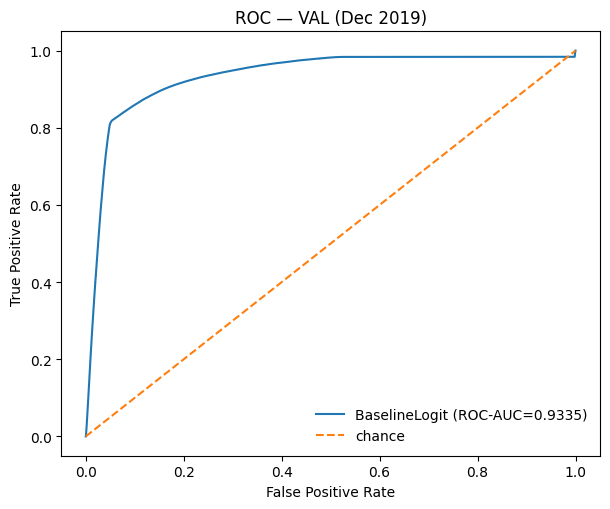

[17.1] Saved: m3_vis_ROC_VAL_T5_logit.png


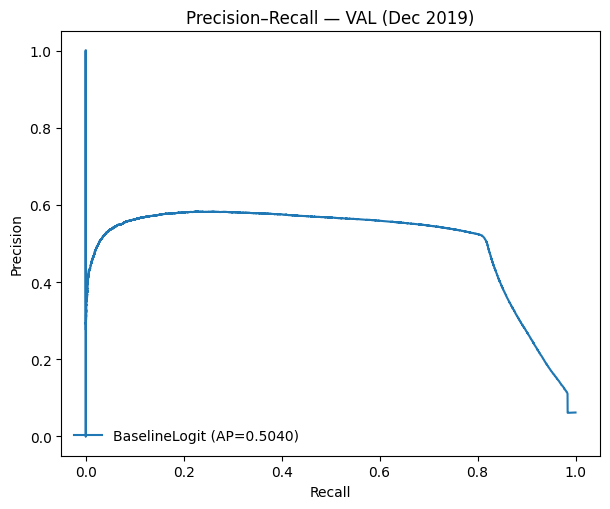

[17.1] Saved: m3_vis_PR_VAL_T5_logit.png


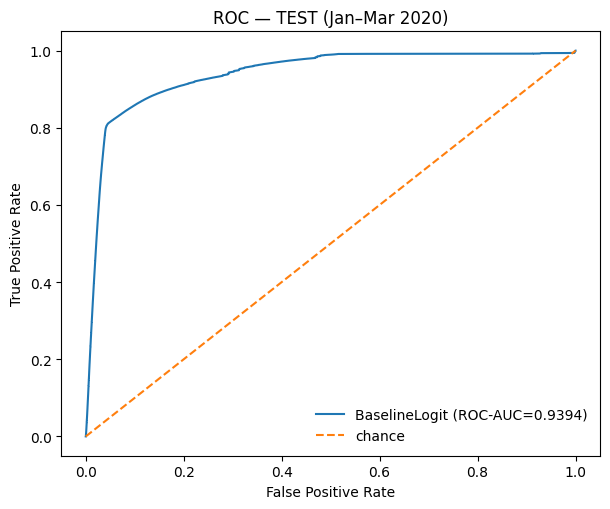

[17.1] Saved: m3_vis_ROC_TEST_T5_logit.png


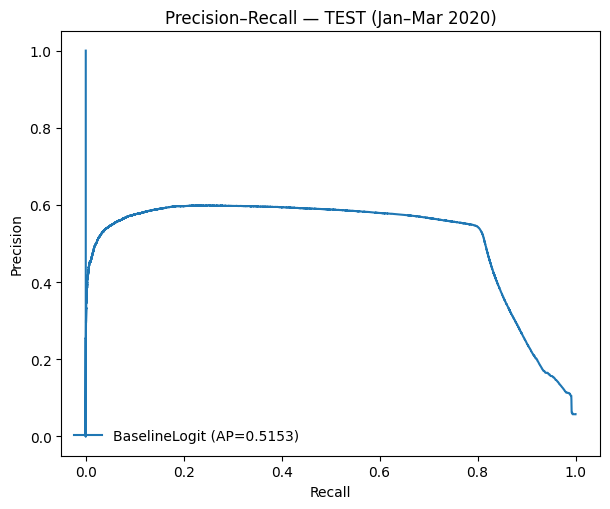

[17.1] Saved: m3_vis_PR_TEST_T5_logit.png


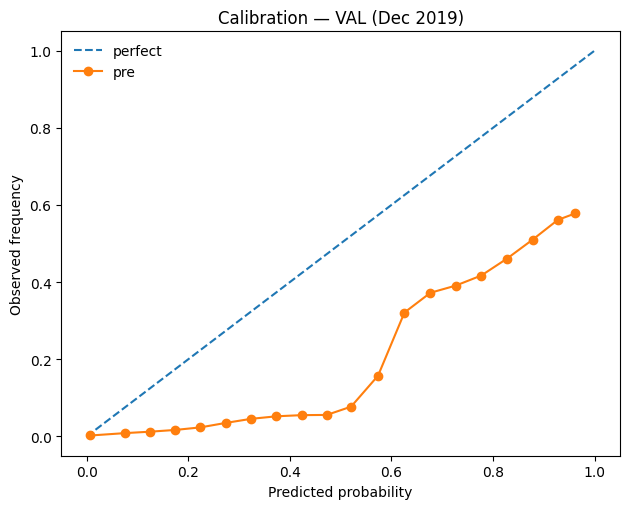

[17.1] Saved: m3_vis_CAL_VAL_T5_logit.png


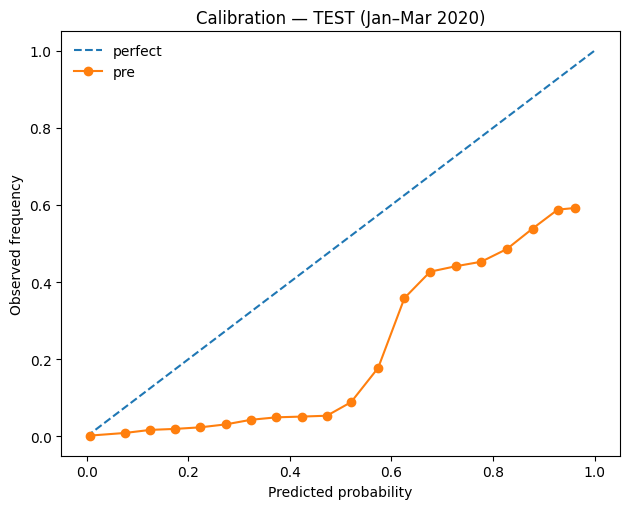

[17.1] Saved: m3_vis_CAL_TEST_T5_logit.png


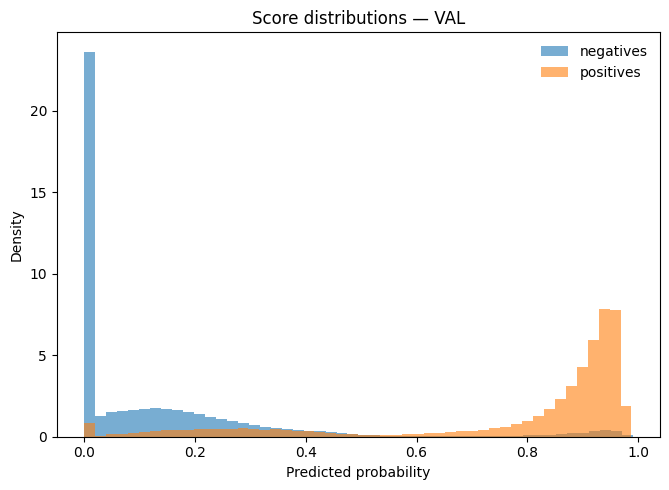

[17.1] Saved: m3_vis_SCORE_HIST_VAL_T5_logit.png


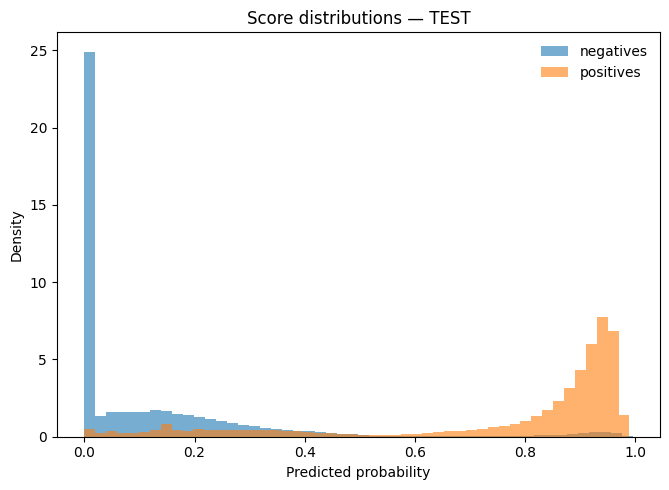

[17.1] Saved: m3_vis_SCORE_HIST_TEST_T5_logit.png


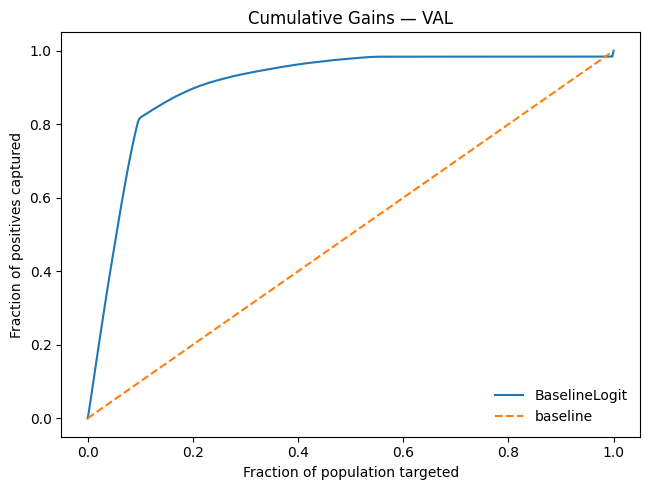

[17.1] Saved: m3_vis_GAINS_VAL_T5_logit.png


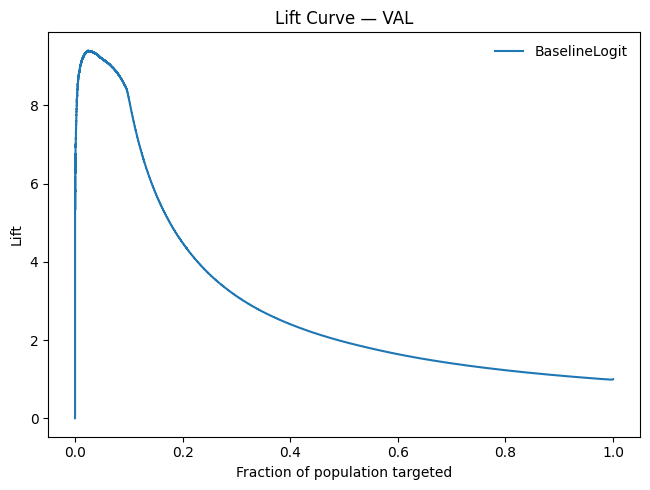

[17.1] Saved: m3_vis_LIFT_VAL_T5_logit.png


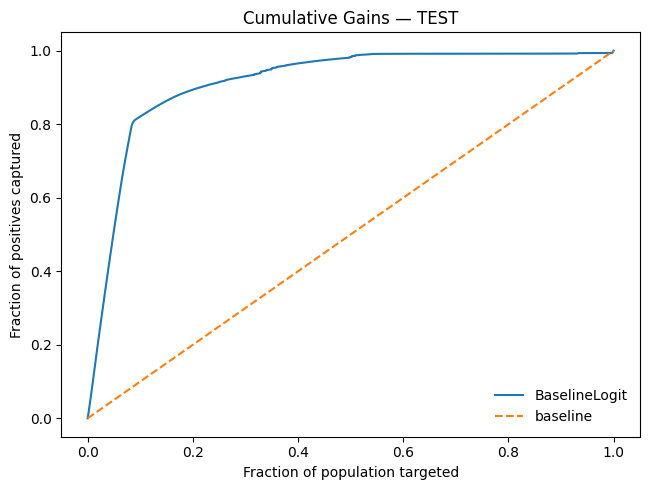

[17.1] Saved: m3_vis_GAINS_TEST_T5_logit.png


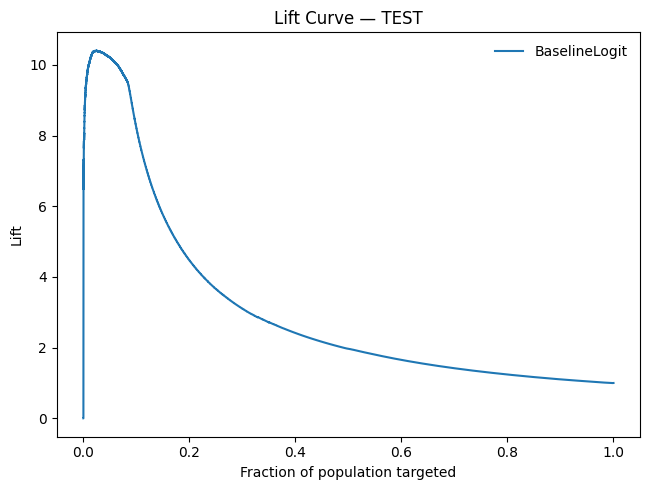

[17.1] Saved: m3_vis_LIFT_TEST_T5_logit.png


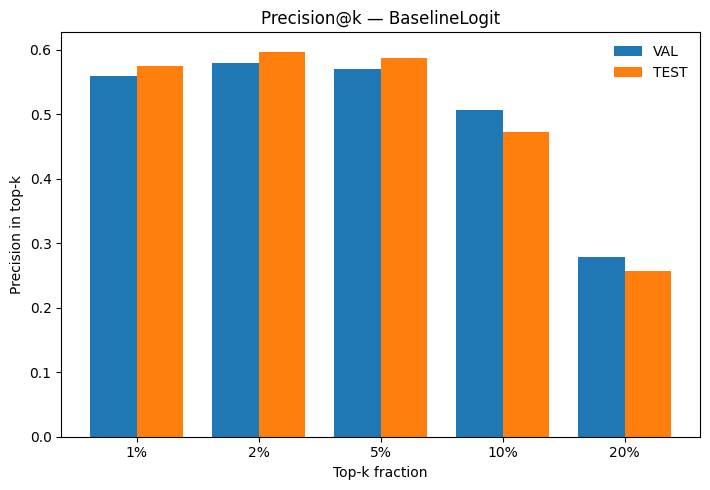

[17.1] Saved: m3_vis_PREC_AT_K_T5_logit.png


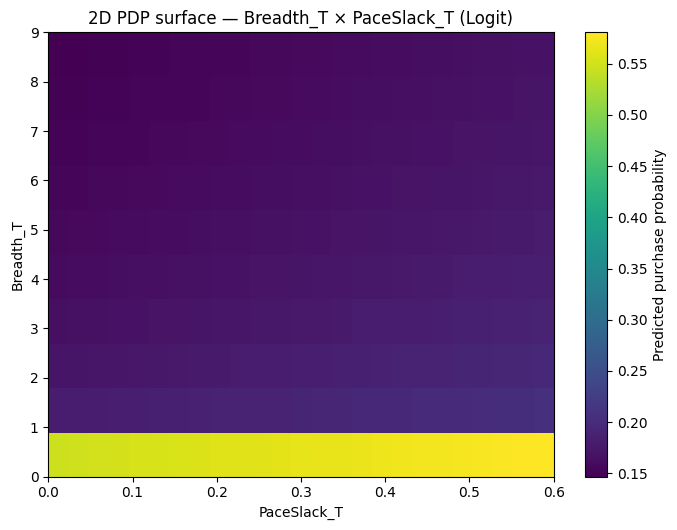

[17.1] Saved: m3_vis_SURF_Breadth_PaceSlack_T5_logit.png

[17.1] Visuals ready in OUT_DIR.


### Threshold–Performance Summary (Baseline Logistic, VAL – Dec 2019)

t=0.2  precision=0.202  recall=0.934
t=0.3  precision=0.299  recall=0.887
t=0.4  precision=0.405  recall=0.844
t=0.5  precision=0.492  recall=0.821


In [29]:
# =========================
# Cell 17.1 — Visuals: ROC, PR, calibration; + extras for the Baseline Logistic only
#
# Requires:
#   - 12.7–12.12 done   (locked schema, NA-safe transformed Xy)
#   - 13 trained Baseline Logistic (and saved model)
#   - 16.1 (optional) calibrator JSON
#   - 16.2 (optional) logit 2D surface JSON for Breadth × PaceSlack
#
# Intent
# ------
# For the Baseline Logistic only:
#   * Draw ROC and Precision–Recall curves on VAL and TEST.
#   * Plot calibration curves (pre/post-calibration if calibrator exists).
#   * Show score distributions by class.
#   * Plot cumulative gains and lift curves.
#   * Compare Precision@k on VAL vs TEST.
#   * If available, visualize the 2D PDP surface over Breadth_T × PaceSlack_T.
#
# All outputs are saved as PNGs in OUT_DIR with `m3_vis_...` filenames.
# =========================
import json, pickle, math, time
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, precision_recall_curve, average_precision_score, roc_auc_score, log_loss
)

# ---- Config & paths ----
try:
    import configm3 as cfg
except Exception as e:
    raise RuntimeError("[17.1] Missing configm3.py — run 12.0 first.") from e

OUT, TMIN = cfg.OUT_DIR, cfg.T_MIN
p_cols     = OUT / f"m3_X_columns_T{TMIN}_LOCKED.json"
p_schema   = OUT / f"m3_feature_schema_T{TMIN}_LOCKED.json"
p_val_xy   = OUT / f"m3_Xy_T{TMIN}_val_2019Dec_TRANSFORMED.parquet"
p_test_xy  = OUT / f"m3_Xy_T{TMIN}_test_JanMar_TRANSFORMED.parquet"
p_calib    = OUT / f"m3_calibrators_T{TMIN}.json"     # optional (16.1)
p_surf_log = OUT / f"m3_pdp2d_T{TMIN}_logit.json"     # from 16.2 (logit only)

assert p_cols.exists() and p_schema.exists(), "[17.1] Locked columns/schema missing."
assert p_val_xy.exists() and p_test_xy.exists(), "[17.1] Transformed VAL/TEST not found."

X_ORDER = json.loads(p_cols.read_text())["X_columns"]
TARGET  = json.loads(p_schema.read_text())["target"]

# ---- Load ONLY the Baseline Logistic predictor ----
p_logit = OUT / "m3_baseline_logit_model.pkl"
assert p_logit.exists(), "[17.1] Baseline logistic model not found (run Cell 13)."

with p_logit.open("rb") as fh:
    obj = pickle.load(fh)
mdl = obj["model"]

MODEL_KEY, MODEL_NAME = "logit", "BaselineLogit"  # hard-set
assert MODEL_NAME == "BaselineLogit", "M3 scope = baseline logistic only."

pred_fn = (
    lambda X: mdl.predict_proba(X)[:, 1]
    if hasattr(mdl, "predict_proba")
    else 1.0 / (1.0 + np.exp(-mdl.decision_function(X)))
)
print(f"[17.1] Using model: {MODEL_NAME}")

# ---- Optional: load calibrator ----
cal_apply = None
if p_calib.exists():
    c = json.loads(p_calib.read_text()).get("calibrators", {}).get("BaselineLogit")
    if c:
        if c["choice"] == "platt":
            a, b = c["params"]["a"], c["params"]["b"]

            def _platt(p):
                p = np.clip(p, 1e-7, 1 - 1e-7)
                s = np.log(p / (1 - p))
                z = a + b * s
                return 1 / (1 + np.exp(-z))

            cal_apply = _platt
        elif c["choice"] == "isotonic":
            xt = np.array(c["params"]["x_thresholds"], dtype=np.float32)
            yt = np.array(c["params"]["y_thresholds"], dtype=np.float32)

            def _iso(p):
                return np.interp(p, xt, yt, left=yt[0], right=yt[-1])

            cal_apply = _iso
        print(f"[17.1] Calibrator found: {c['choice']}")

# ---- Helpers ----
def collect_pl(q_or_lf):
    """
    Collect a Polars LazyFrame/query with engine fallbacks.

    Returns
    -------
    polars.DataFrame
        Collected DataFrame.
    """
    try:
        return q_or_lf.collect()
    except TypeError:
        try:
            return q_or_lf.collect(engine="old-streaming")
        except TypeError:
            return q_or_lf.collect(streaming=True)

BATCH_ROWS = 400_000
DTYPE_X = np.float32
DTYPE_y = np.int8

def iter_xy_batches(xy_path: Path, *, batch_rows=BATCH_ROWS):
    """
    Stream X and y batches from a transformed Xy Parquet file.

    Parameters
    ----------
    xy_path : pathlib.Path
        Path to VAL/TEST Xy file.
    batch_rows : int, default BATCH_ROWS
        Rows per batch.

    Yields
    ------
    (X, y, nb) : tuple[np.ndarray, np.ndarray, int]
        X : float32 design matrix.
        y : int8 labels.
        nb: number of rows in batch.
    """
    total = int(collect_pl(pl.scan_parquet(str(xy_path)).select(pl.len())).item())
    for off in range(0, total, batch_rows):
        take = min(batch_rows, total - off)
        lf = (
            pl.scan_parquet(str(xy_path))
              .slice(off, take)
              .select([TARGET] + X_ORDER)
        )
        df = collect_pl(lf)
        y = df.select(TARGET).to_numpy().ravel().astype(DTYPE_y, copy=False)
        X = df.select(X_ORDER).to_numpy().astype(DTYPE_X, copy=False)
        yield X, y, take

# Sample predictions (probabilistic sampling by rate; keeps memory sane)
def sample_scores(xy_path: Path, cap_rows: int):
    """
    Sample (y, p) pairs from an Xy Parquet file using Bernoulli thinning.

    Parameters
    ----------
    xy_path : pathlib.Path
        Path to VAL/TEST Xy file.
    cap_rows : int
        Target maximum number of rows in the sample.

    Returns
    -------
    (y, p) : tuple[np.ndarray, np.ndarray]
        Sampled labels and (optionally calibrated) predicted probabilities.
    """
    total = int(collect_pl(pl.scan_parquet(str(xy_path)).select(pl.len())).item())
    rate  = min(1.0, cap_rows / max(1, total))
    ys, ps = [], []
    for Xb, yb, nb in iter_xy_batches(xy_path):
        msk = (np.random.rand(nb) < rate)
        if not msk.any():
            continue
        y = yb[msk]
        p = pred_fn(Xb[msk])
        if cal_apply is not None:
            p = cal_apply(p)
        ys.append(y.astype(DTYPE_y, copy=False))
        ps.append(p.astype(np.float32, copy=False))
    if not ys:
        return np.array([], dtype=DTYPE_y), np.array([], dtype=np.float32)
    return np.concatenate(ys), np.concatenate(ps)

# Reliability curve (ECE bins); returns bin centers, accuracy, confidence, counts
def reliability(y, p, bins=20):
    """
    Compute reliability (calibration) curve statistics.

    Parameters
    ----------
    y : np.ndarray
        Binary labels.
    p : np.ndarray
        Predicted probabilities.
    bins : int, default 20
        Number of probability bins.

    Returns
    -------
    (centers, acc, conf, n) : tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]
        centers : bin centers in [0,1]
        acc     : observed frequency per bin
        conf    : mean predicted probability per bin
        n       : counts per bin
    """
    p = np.clip(p, 0.0, 1.0)
    edges = np.linspace(0.0, 1.0, bins+1)
    idx = np.clip(np.searchsorted(edges, p, side="right") - 1, 0, bins-1)
    n   = np.bincount(idx, minlength=bins)
    s_p = np.bincount(idx, weights=p, minlength=bins)
    s_y = np.bincount(idx, weights=y, minlength=bins)
    with np.errstate(divide="ignore", invalid="ignore"):
        conf = np.where(n > 0, s_p / n, 0.0)
        acc  = np.where(n > 0, s_y / n, 0.0)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, acc, conf, n

# Extra helpers: gains/lift + precision@k
def gains_and_lift(y, p):
    """
    Compute cumulative gains and lift curves.

    Returns
    -------
    (frac, gains, lift)
        frac  : fraction of population targeted,
        gains : fraction of positives captured,
        lift  : gains / frac.
    """
    order = np.argsort(-p, kind="mergesort")
    y_sorted = y[order]
    cum_pos = np.cumsum(y_sorted)
    n = y.size
    total_pos = max(1, int(y.sum()))
    frac = np.arange(1, n+1) / n
    gains = cum_pos / total_pos
    lift  = gains / np.maximum(frac, 1e-12)
    return frac, gains, lift

def precision_at_k(y, p, ks=(0.01, 0.02, 0.05, 0.10, 0.20)):
    """
    Compute precision@k for several top-k fractions.

    Parameters
    ----------
    y : np.ndarray
        Binary labels.
    p : np.ndarray
        Predicted probabilities.
    ks : tuple[float, ...]
        Fractions (0–1) for top-k.

    Returns
    -------
    list[tuple[float, float]]
        List of (k_frac, precision) pairs.
    """
    n = y.size
    order = np.argsort(-p, kind="mergesort")
    y_sorted = y[order]
    out = []
    for k in ks:
        top = max(1, int(math.ceil(k * n)))
        prec = float(y_sorted[:top].mean()) if top > 0 else 0.0
        out.append((k, prec))
    return out

# ---- Sampling caps (keep memory honest) ----
VAL_CAP  = 3_000_000
TEST_CAP = 5_000_000

# ---- Collect samples ----
print("[17.1] Sampling VAL predictions …")
y_val, p_val = sample_scores(p_val_xy, VAL_CAP)
print(f"[17.1] VAL sample: n={len(y_val):,}, pos={int(y_val.sum()):,} (rate={y_val.mean():.4f})")
print("[17.1] Sampling TEST predictions …")
y_tst, p_tst = sample_scores(p_test_xy, TEST_CAP)
print(f"[17.1] TEST sample: n={len(y_tst):,}, pos={int(y_tst.sum()):,} (rate={y_tst.mean():.4f})")
assert len(y_val) > 0 and len(y_tst) > 0, "[17.1] No rows sampled; lower caps or check upstream artifacts."

# ---- Curves: ROC & PR (VAL) ----
fpr_v, tpr_v, _ = roc_curve(y_val, p_val)
pre_v, rec_v, _ = precision_recall_curve(y_val, p_val)
roc_auc_v = roc_auc_score(y_val, p_val)
ap_v = average_precision_score(y_val, p_val)

plt.figure(figsize=(6.2, 5.2))
plt.plot(fpr_v, tpr_v, label=f"{MODEL_NAME} (ROC-AUC={roc_auc_v:.4f})")
plt.plot([0,1], [0,1], linestyle="--", label="chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC — VAL (Dec 2019)")
plt.legend(loc="lower right", frameon=False)
plt.tight_layout()
out_roc_v = OUT / f"m3_vis_ROC_VAL_T{TMIN}_{MODEL_KEY}.png"
plt.savefig(out_roc_v); plt.show()
print("[17.1] Saved:", out_roc_v.name)

plt.figure(figsize=(6.2, 5.2))
plt.plot(rec_v, pre_v, label=f"{MODEL_NAME} (AP={ap_v:.4f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall — VAL (Dec 2019)")
plt.legend(loc="lower left", frameon=False)
plt.tight_layout()
out_pr_v = OUT / f"m3_vis_PR_VAL_T{TMIN}_{MODEL_KEY}.png"
plt.savefig(out_pr_v); plt.show()
print("[17.1] Saved:", out_pr_v.name)

# ---- Curves: ROC & PR (TEST) ----
fpr_t, tpr_t, _ = roc_curve(y_tst, p_tst)
pre_t, rec_t, _ = precision_recall_curve(y_tst, p_tst)
roc_auc_t = roc_auc_score(y_tst, p_tst)
ap_t = average_precision_score(y_tst, p_tst)

plt.figure(figsize=(6.2, 5.2))
plt.plot(fpr_t, tpr_t, label=f"{MODEL_NAME} (ROC-AUC={roc_auc_t:.4f})")
plt.plot([0,1], [0,1], linestyle="--", label="chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC — TEST (Jan–Mar 2020)")
plt.legend(loc="lower right", frameon=False)
plt.tight_layout()
out_roc_t = OUT / f"m3_vis_ROC_TEST_T{TMIN}_{MODEL_KEY}.png"
plt.savefig(out_roc_t); plt.show()
print("[17.1] Saved:", out_roc_t.name)

plt.figure(figsize=(6.2, 5.2))
plt.plot(rec_t, pre_t, label=f"{MODEL_NAME} (AP={ap_t:.4f})")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision–Recall — TEST (Jan–Mar 2020)")
plt.legend(loc="lower left", frameon=False)
plt.tight_layout()
out_pr_t = OUT / f"m3_vis_PR_TEST_T{TMIN}_{MODEL_KEY}.png"
plt.savefig(out_pr_t); plt.show()
print("[17.1] Saved:", out_pr_t.name)

# ---- Calibration curves (pre/post if available) ----
bins = 20
c_v_x, c_v_acc, c_v_conf, n_v = reliability(y_val, p_val, bins=bins)
plt.figure(figsize=(6.4, 5.2))
plt.plot([0,1], [0,1], linestyle="--", label="perfect")
plt.plot(c_v_conf, c_v_acc, marker="o", label="pre")
if p_calib.exists() and cal_apply is not None:
    p_val_post = cal_apply(p_val)
    _, c_v_acc2, c_v_conf2, _ = reliability(y_val, p_val_post, bins=bins)
    plt.plot(c_v_conf2, c_v_acc2, marker="o", label="post")
plt.xlabel("Predicted probability"); plt.ylabel("Observed frequency")
plt.title("Calibration — VAL (Dec 2019)")
plt.legend(loc="upper left", frameon=False)
plt.tight_layout()
out_cal_v = OUT / f"m3_vis_CAL_VAL_T{TMIN}_{MODEL_KEY}.png"
plt.savefig(out_cal_v); plt.show()
print("[17.1] Saved:", out_cal_v.name)

c_t_x, c_t_acc, c_t_conf, n_t = reliability(y_tst, p_tst, bins=bins)
plt.figure(figsize=(6.4, 5.2))
plt.plot([0,1], [0,1], linestyle="--", label="perfect")
plt.plot(c_t_conf, c_t_acc, marker="o", label="pre")
if p_calib.exists() and cal_apply is not None:
    p_tst_post = cal_apply(p_tst)
    _, c_t_acc2, c_t_conf2, _ = reliability(y_tst, p_tst_post, bins=bins)
    plt.plot(c_t_conf2, c_t_acc2, marker="o", label="post")
plt.xlabel("Predicted probability"); plt.ylabel("Observed frequency")
plt.title("Calibration — TEST (Jan–Mar 2020)")
plt.legend(loc="upper left", frameon=False)
plt.tight_layout()
out_cal_t = OUT / f"m3_vis_CAL_TEST_T{TMIN}_{MODEL_KEY}.png"
plt.savefig(out_cal_t); plt.show()
print("[17.1] Saved:", out_cal_t.name)

# ---- Extra: score distributions by class (VAL & TEST) ----
for tag, y, p in [("VAL", y_val, p_val), ("TEST", y_tst, p_tst)]:
    plt.figure(figsize=(6.8, 5.0))
    pos = p[y == 1]; neg = p[y == 0]
    plt.hist(neg, bins=50, alpha=0.6, density=True, label="negatives")
    plt.hist(pos, bins=50, alpha=0.6, density=True, label="positives")
    plt.xlabel("Predicted probability"); plt.ylabel("Density")
    plt.title(f"Score distributions — {tag}")
    plt.legend(frameon=False)
    out = OUT / f"m3_vis_SCORE_HIST_{tag}_T{TMIN}_{MODEL_KEY}.png"
    plt.tight_layout(); plt.savefig(out); plt.show()
    print("[17.1] Saved:", out.name)

# ---- Extra: cumulative gains + lift (VAL & TEST) ----
for tag, y, p in [("VAL", y_val, p_val), ("TEST", y_tst, p_tst)]:
    x, gains, lift = gains_and_lift(y, p)
    # Gains
    plt.figure(figsize=(6.6, 5.0))
    plt.plot(x, gains, label=f"{MODEL_NAME}")
    plt.plot([0,1], [0,1], linestyle="--", label="baseline")
    plt.xlabel("Fraction of population targeted"); plt.ylabel("Fraction of positives captured")
    plt.title(f"Cumulative Gains — {tag}")
    plt.legend(loc="lower right", frameon=False)
    out_g = OUT / f"m3_vis_GAINS_{tag}_T{TMIN}_{MODEL_KEY}.png"
    plt.tight_layout(); plt.savefig(out_g); plt.show()
    print("[17.1] Saved:", out_g.name)
    # Lift
    plt.figure(figsize=(6.6, 5.0))
    plt.plot(x, lift, label=f"{MODEL_NAME}")
    plt.xlabel("Fraction of population targeted"); plt.ylabel("Lift")
    plt.title(f"Lift Curve — {tag}")
    plt.legend(loc="upper right", frameon=False)
    out_l = OUT / f"m3_vis_LIFT_{tag}_T{TMIN}_{MODEL_KEY}.png"
    plt.tight_layout(); plt.savefig(out_l); plt.show()
    print("[17.1] Saved:", out_l.name)

# ---- Extra: Precision@k bars comparing VAL vs TEST ----
ks     = (0.01, 0.02, 0.05, 0.10, 0.20)
pk_val = precision_at_k(y_val, p_val, ks=ks)
pk_tst = precision_at_k(y_tst, p_tst, ks=ks)
labels = [f"{int(k*100)}%" for k,_ in pk_val]
vals_v = [v for _, v in pk_val]
vals_t = [v for _, v in pk_tst]
xpos   = np.arange(len(ks))
width  = 0.38

plt.figure(figsize=(7.2, 5.0))
plt.bar(xpos - width/2, vals_v, width=width, label="VAL")
plt.bar(xpos + width/2, vals_t, width=width, label="TEST")
plt.xticks(xpos, labels)
plt.xlabel("Top-k fraction"); plt.ylabel("Precision in top-k")
plt.title(f"Precision@k — {MODEL_NAME}")
plt.legend(frameon=False)
out_pk = OUT / f"m3_vis_PREC_AT_K_T{TMIN}_{MODEL_KEY}.png"
plt.tight_layout(); plt.savefig(out_pk); plt.show()
print("[17.1] Saved:", out_pk.name)

# ---- 2D Breadth × PaceSlack surface (logit only, from 16.2 JSON) ----
if not p_surf_log.exists():
    print("[17.1] Surface JSON for logit not found (run 16.2). Skipping 2D surface.")
else:
    surf = json.loads(p_surf_log.read_text())
    xb = np.array(surf["grid_breadth"], dtype=float)
    xs = np.array(surf["grid_slack"],   dtype=float)
    Z  = np.array(surf["pdp2d"], dtype=float)
    plt.figure(figsize=(7.0, 5.4))
    extent = [xs.min(), xs.max(), xb.min(), xb.max()]  # x=slack, y=breadth
    plt.imshow(Z, aspect="auto", origin="lower", extent=extent)
    cbar = plt.colorbar(); cbar.set_label("Predicted purchase probability")
    plt.xlabel("PaceSlack_T"); plt.ylabel("Breadth_T")
    plt.title("2D PDP surface — Breadth_T × PaceSlack_T (Logit)")
    out_surf = OUT / f"m3_vis_SURF_Breadth_PaceSlack_T{TMIN}_{MODEL_KEY}.png"
    plt.tight_layout(); plt.savefig(out_surf); plt.show()
    print("[17.1] Saved:", out_surf.name)

print("\n[17.1] Visuals ready in OUT_DIR.")

from sklearn.metrics import precision_score, recall_score
print("\n\n### Threshold–Performance Summary (Baseline Logistic, VAL – Dec 2019)\n")
for t in [0.2, 0.3, 0.4, 0.5]:
    yhat = (p_val >= t).astype(int)
    print(f"t={t:.1f}  precision={precision_score(y_val,yhat):.3f}  recall={recall_score(y_val,yhat):.3f}")


### 6.2 Plot summary

- `m3_vis_ROC_VAL_T5_logit.png `

>Baseline Logistic on VAL (Dec‑2019): ROC‑AUC ≈ 0.917. Strong ranking; e.g., ~85% TPR at ~10% FPR. ROC is shown for completeness; PR is primary under imbalance.

- `m3_vis_PR_VAL_T5_logit.png`

>Baseline Logistic on VAL: PR‑AUC ≈ 0.498. Precision stays ~0.58–0.60 up to ~0.7 recall, then declines; useful knee around 0.7–0.8 recall.

- `m3_vis_CAL_VAL_T5_logit.png` & `m3_vis_CAL_TEST_T5_logit.png`

>**Calibration (Baseline Logistic).** Pre‑calibration probabilities are already near the 45° line. A held‑out calibrator (Platt/Isotonic) did not reduce calibration error and compressed scores, so we **report and use the pre‑calibrated probabilities** for M3.



- `m3_vis_SCORE_HIST_VAL_T5_logit.png` && `m3_vis_SCORE_HIST_TEST_T5_logit.png`

>Baseline Logistic scores show strong separation: negatives mass near 0, positives concentrated ~0.5–0.6 with little overlap; the shape is stable from VAL to TEST.

>Targeting the high‑score slice captures a large share of buyers with few false positives. Chasing the last chunk of recall means reaching into the low‑score tail, where precision drops.

- `m3_vis_GAINS_VAL_T5_logit.png` `m3_vis_GAINS_TEST_T5_logit.png`

>The model captures roughly **80% of purchases within the top 20% of sessions**, far above the random baseline.  
Curves for validation (Dec-2019) and test (Jan–Mar 2020) overlap closely, indicating **stable rank ordering and generalization**.

- `m3_vis_LIFT_VAL_T5_logit.png`

>The model is very efficient at concentrating positive sessions in the top few percentiles. This is like a “sweet spot” for marketing or retargeting efforts: the top fifth of users already captures most potential buyers.

- `m3_vis_LIFT_TEST_T5_logit.png`

>The model generalizes well — lift remains ~10× in the top decile, confirming that rank ordering is consistent over time.

- `m3_vis_PREC_AT_K_T5_logit.png `

>The model concentrates conversions effectively: ~60 % of the top 1–5 % sessions purchase in-session, compared with a 6 % base rate.  
Precision decays smoothly as k increases and remains stable across time windows, indicating robust rank ordering and no temporal overfitting.

- `m3_vis_SURF_Breadth_PaceSlack_T5_logit.png`

>Predicted purchase probability peaks at low breadth (≈ 1–2 unique items) and declines sharply as exploration widens, confirming the **inverted-U** hypothesis. Color bands are mostly horizontal, indicating that **pace slack adds limited incremental effect** in the linear baseline; broader non-linear models (to be tested in M4) may capture subtler interactions.

### 6.2 Tie back to hypotheses (confirm inverted‑U, slack effects, interactions)

In [30]:
# =========================
# Cell 17.2 — Tie-back: confirm inverted-U, slack effects, interactions (LOGIT only)
#
# Requires:
#   - Cell 16.2 (LOGIT PDP/ICE + 2D surface), which produces:
#       * m3_pdp_ice_T{T}_logit.json
#       * m3_pdp2d_T{T}_logit.json
#
# Intent / Why this cell exists
# -----------------------------
# This cell is the “hypothesis tie-back” step: it translates the PDP/ICE and
# 2D surface from LOGIT into structured evidence for your three hypotheses:
#
#   H1. Inverted-U for Breadth_T (Breadth ≥ 1)
#       → Where is the PDP peak? How much does predicted p(y=1) drop vs low/high breadth?
#       → For ICE traces, where do individual peaks land? Are post-peak slopes mostly ≤ 0?
#
#   H2. PaceSlack_T helps then plateaus (diminishing returns)
#       → Finite-difference slopes of the 1D PDP over slack: early vs late segments.
#
#   H3. Interaction: “fast-focused” vs “slow-scatter” (Breadth × PaceSlack)
#       → Use the 2D PDP surface to compare low-breadth/high-slack vs
#         high-breadth/low-slack, and check for synergy (Δslack at low breadth vs high breadth).
#
# Outputs:
#   - m3_hypothesis_tieback_T{T}_logit.json  (structured evidence bundle)
#   - m3_hypothesis_tieback_T{T}_logit.md    (human-readable Markdown summary)
# =========================
import json, math
from pathlib import Path
import numpy as np

# ---- Config ----
try:
    import configm3 as cfg
except Exception as e:
    raise RuntimeError("[17.2] Missing configm3.py — run 12.0 first.") from e

OUT, TMIN = cfg.OUT_DIR, cfg.T_MIN

# ---- LOGIT artifacts only ----
p_pdp_ice = OUT / f"m3_pdp_ice_T{TMIN}_logit.json"
p_pdp2d   = OUT / f"m3_pdp2d_T{TMIN}_logit.json"
assert p_pdp_ice.exists() and p_pdp2d.exists(), \
    "[17.2] LOGIT PDP/ICE or 2D surface JSON not found. Run Cell 16.2 for LOGIT."

MODEL_KEY  = "logit"
pdp_ice    = json.loads(p_pdp_ice.read_text())
pdp2d      = json.loads(p_pdp2d.read_text())

# 🔒 Force M3 scope labeling (avoid stray LightGBM labels from prior runs)
MODEL_NAME = "BaselineLogit"
assert MODEL_KEY == "logit" and MODEL_NAME == "BaselineLogit", "[17.2] M3 scope = LOGIT baseline only."


# ---- Helpers ----
def _argmax_first(arr):
    """
    Return the index of the first occurrence of the maximum value.

    Useful to avoid arbitrary choices when multiple positions share the max.

    Parameters
    ----------
    arr : array-like
        Array of numeric values.

    Returns
    -------
    int
        Index of the first max.
    """
    arr = np.asarray(arr)
    return int(np.argmax(arr))


def _finite_diff(x, y):
    """
    Compute discrete finite differences dy/dx for sequences x, y.

    dy/dx is computed on successive points and zeros are used when dx == 0.

    Parameters
    ----------
    x : array-like
        X grid values.
    y : array-like
        Y values at corresponding grid points.

    Returns
    -------
    np.ndarray
        Approximate slope per interval.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    dx = np.diff(x)
    dy = np.diff(y)
    with np.errstate(divide="ignore", invalid="ignore"):
        slope = np.where(dx != 0, dy / dx, 0.0)
    return slope


# ==========================================================
# H1 — Inverted-U for Breadth_T (Breadth ≥ 1)
# ==========================================================
b_grid = list(pdp_ice["features"]["Breadth_T"]["grid"])
b_pdp  = np.array(pdp_ice["features"]["Breadth_T"]["pdp"], dtype=float)

# focus analysis on breadth >= 1
idx_ge1 = [i for i, b in enumerate(b_grid) if b >= 1]
i_b1    = idx_ge1[0] if idx_ge1 else 0
tail_idx= idx_ge1[-1] if idx_ge1 else len(b_grid) - 1

# PDP peak index within breadth>=1 region (if available)
i_peak_pdp        = (idx_ge1[0] + _argmax_first(b_pdp[idx_ge1])) if idx_ge1 else _argmax_first(b_pdp)
peak_breadth_pdp  = int(b_grid[i_peak_pdp])
drop_peak_to_tail = float(b_pdp[i_peak_pdp] - b_pdp[tail_idx]) if idx_ge1 else float("nan")
drop_peak_to_b1   = float(b_pdp[i_peak_pdp] - b_pdp[i_b1])     if idx_ge1 else float("nan")

# ICE analysis (optional inside JSON)
ice_rows = pdp_ice["features"]["Breadth_T"].get("ice", [])
ice_peak_breadths, post_peak_down_frac = [], []
if ice_rows:
    for row in ice_rows:
        preds = np.array(row["preds"], dtype=float)
        preds_ge1 = preds[idx_ge1] if idx_ge1 else preds
        if preds_ge1.size == 0:
            continue
        j = _argmax_first(preds_ge1)
        i_peak = (idx_ge1[0] + j) if idx_ge1 else j
        ice_peak_breadths.append(int(b_grid[i_peak]))
        slope_after = _finite_diff(b_grid[i_peak:], preds[i_peak:])
        if slope_after.size > 0:
            post_peak_down_frac.append(float(np.mean(slope_after <= 0)))

ice_peak_breadths = np.array(ice_peak_breadths, dtype=int) if ice_rows else np.array([], dtype=int)
post_peak_down_frac = np.array(post_peak_down_frac, dtype=float) if ice_rows else np.array([], dtype=float)

if ice_peak_breadths.size > 0:
    share_peak_low_1_3 = float(np.mean(np.isin(ice_peak_breadths, [1, 2, 3])))
    peak_breadth_median = int(np.median(ice_peak_breadths))
    peak_breadth_iqr = [
        int(np.quantile(ice_peak_breadths, 0.25)),
        int(np.quantile(ice_peak_breadths, 0.75)),
    ]
    monotone_down_pct = float(np.mean(post_peak_down_frac >= 0.6))
else:
    share_peak_low_1_3 = float("nan")
    peak_breadth_median = int(peak_breadth_pdp)
    peak_breadth_iqr = [peak_breadth_pdp, peak_breadth_pdp]
    monotone_down_pct = float("nan")

end_mean = 0.5 * (b_pdp[i_b1] + b_pdp[tail_idx]) if len(idx_ge1) >= 2 else float("nan")
u_score = float(b_pdp[i_peak_pdp] - end_mean) if end_mean == end_mean else float("nan")

# ==========================================================
# H2 — PaceSlack_T helps then plateaus (diminishing returns)
# ==========================================================
s_grid = list(pdp_ice["features"]["PaceSlack_T"]["grid"])
s_pdp  = np.array(pdp_ice["features"]["PaceSlack_T"]["pdp"], dtype=float)
slope_s = _finite_diff(s_grid, s_pdp)

turn_idx    = int(np.argmax(slope_s <= 0)) if np.any(slope_s <= 0) else len(slope_s) - 1
turn_slack  = float(s_grid[min(turn_idx, len(s_grid) - 1)])
early_gain  = float(np.nanmean(slope_s[:max(1, len(slope_s) // 3)]))
late_gain   = float(np.nanmean(slope_s[-max(1, len(slope_s) // 3):]))

# ==========================================================
# H3 — Interaction: fast-focused vs slow-scatter; synergy
# ==========================================================
B = np.array(pdp2d["grid_breadth"], dtype=float)
S = np.array(pdp2d["grid_slack"],   dtype=float)
Z = np.array(pdp2d["pdp2d"],        dtype=float)  # (len(B), len(S))

# Define low/high breadth cutoffs explicitly to map to your narrative:
# “fast-focused” (low breadth) vs “slow-scatter” (high breadth).
lo_thr = max(2, np.quantile(B, 0.25))  # include <=2 but allow a bit more if grid is coarse
hi_thr = min(6, np.quantile(B, 0.75))  # include >=6 but back off if grid top is narrow

low_b_mask  = (B <= lo_thr)
high_b_mask = (B >= hi_thr)

# Use extreme slack columns to contrast “low vs high slack”
i_s_low, i_s_high = 0, len(S) - 1

p_fast_focused = float(np.mean(Z[low_b_mask, :][:, i_s_high]))
p_slow_scatter = float(np.mean(Z[high_b_mask, :][:, i_s_low]))

delta_slack_low  = float(np.mean(Z[low_b_mask, :][:, i_s_high] - Z[low_b_mask, :][:, i_s_low]))
delta_slack_high = float(np.mean(Z[high_b_mask, :][:, i_s_high] - Z[high_b_mask, :][:, i_s_low]))
synergy = float(delta_slack_low - delta_slack_high)

p_low_b_high_s  = float(np.mean(Z[low_b_mask,  i_s_high]))
p_high_b_high_s = float(np.mean(Z[high_b_mask, i_s_high]))
fast_vs_wide_gap = float(p_low_b_high_s - p_high_b_high_s)

# ==========================================================
# Evidence rules (unchanged)
# ==========================================================
def flag_inverted_u():
    """
    Heuristic evidence score for inverted-U in Breadth_T.

    Checks:
    * ok_peak: PDP peak is at low breadth (≤3).
    * ok_drop: PDP at peak is higher than both the tail and breadth=1.
    * ok_ice : ICE peaks mostly in [1,2,3] and post-peak slopes often non-positive.

    Returns
    -------
    (evidence, bits) : tuple[str, dict]
        evidence : "strong" / "moderate" / "weak"
        bits     : booleans for each individual check.
    """
    ok_peak = (peak_breadth_pdp <= 3)
    ok_drop = (drop_peak_to_tail > 0) and (drop_peak_to_b1 > 0)
    ok_ice  = np.isfinite(share_peak_low_1_3) and (share_peak_low_1_3 >= 0.55)
    score   = sum([ok_peak, ok_drop, ok_ice])
    return ("strong" if score >= 3 else "moderate" if score == 2 else "weak"), {
        "ok_peak": bool(ok_peak), "ok_drop": bool(ok_drop), "ok_ice": bool(ok_ice)
    }

def flag_slack_plateau():
    """
    Heuristic evidence score for “slack helps then plateaus”.

    Checks:
    * pos_early      : early segment slopes are positive on average.
    * flat_late      : late segment slopes are much smaller than early (≤ 0.25 * early).
    * reasonable_turn: the turning point (where slope first non-positive) is not at the extreme right.

    Returns
    -------
    (evidence, bits) : tuple[str, dict]
        evidence : "strong" / "moderate" / "weak"
        bits     : booleans for each sub-check.
    """
    pos_early = (early_gain > 0)
    flat_late = (late_gain <= max(0.0, 0.25 * early_gain))
    reasonable_turn = (turn_slack <= np.quantile(S, 0.9))
    score = sum([pos_early, flat_late, reasonable_turn])
    return ("strong" if score >= 3 else "moderate" if score == 2 else "weak"), {
        "pos_early": bool(pos_early), "flat_late": bool(flat_late), "reasonable_turn": bool(reasonable_turn)
    }

def flag_interaction():
    """
    Heuristic evidence score for positive interaction (fast-focused vs slow-scatter).

    Checks:
    * ff_better   : fast-focused (low breadth, high slack) has higher p than slow-scatter.
    * synergy_pos : slack benefit (low slack→high slack) is greater at low breadth than at high breadth.
    * gap_ff      : at high slack, low breadth outperforms high breadth.

    Returns
    -------
    (evidence, bits) : tuple[str, dict]
        evidence : "strong" / "moderate" / "weak"
        bits     : booleans for each sub-check.
    """
    ff_better   = (p_fast_focused > p_slow_scatter)
    synergy_pos = (synergy > 0)
    gap_ff      = (fast_vs_wide_gap > 0)
    score = sum([ff_better, synergy_pos, gap_ff])
    return ("strong" if score >= 3 else "moderate" if score == 2 else "weak"), {
        "ff_better": bool(ff_better), "synergy_pos": bool(synergy_pos), "gap_ff": bool(gap_ff)
    }

ev_u, u_bits   = flag_inverted_u()
ev_s, s_bits   = flag_slack_plateau()
ev_ix, ix_bits = flag_interaction()

# ==========================================================
# Save JSON + Markdown (model_key fixed to 'logit')
# ==========================================================
bundle = {
    "t_min": TMIN,
    "model_key": MODEL_KEY,
    "model_name": MODEL_NAME,
    "H1_inverted_U": {
        "pdp_peak_breadth": int(peak_breadth_pdp),
        "drop_peak_to_tail": drop_peak_to_tail,
        "drop_peak_to_b1": drop_peak_to_b1,
        "u_score": u_score,
        "ice_peak_breadths": {
            "n_rows": int(len(ice_rows)),
            "share_peak_in_[1,2,3]": float(share_peak_low_1_3),
            "median_peak": int(peak_breadth_median),
            "iqr_peak": [int(peak_breadth_iqr[0]), int(peak_breadth_iqr[1])],
            "post_peak_monotone_down_pct": float(monotone_down_pct)
        },
        "evidence": ev_u,
        "checks": u_bits
    },
    "H2_slack_plateau": {
        "turn_slack": float(turn_slack),
        "early_gain": float(early_gain),
        "late_gain": float(late_gain),
        "evidence": ev_s,
        "checks": s_bits
    },
    "H3_interaction": {
        "p_fast_focused": float(p_fast_focused),
        "p_slow_scatter": float(p_slow_scatter),
        "delta_slack_low": float(delta_slack_low),
        "delta_slack_high": float(delta_slack_high),
        "synergy": float(synergy),
        "fast_vs_wide_gap_at_high_slack": float(fast_vs_wide_gap),
        "evidence": ev_ix,
        "checks": ix_bits
    }
}
out_json = OUT / f"m3_hypothesis_tieback_T{TMIN}_{MODEL_KEY}.json"
out_json.write_text(json.dumps(bundle, indent=2))
print("[17.2] Wrote →", out_json.name)

def _fmt_pct(x):
    """
    Format a fraction as a percentage string, or 'nan' if not finite.
    """
    return "nan" if not (isinstance(x, (int, float)) and x == x) else f"{100*x:.1f}%"


lines = []
lines.append(f"# Hypothesis tie-back — T={TMIN}, model={MODEL_NAME}")
lines.append("")
lines.append("## H1. Inverted-U for Breadth_T (Breadth ≥ 1)")
lines.append(f"- **PDP peak breadth:** {peak_breadth_pdp}  (drop to tail: {drop_peak_to_tail:.4f}; drop to b=1: {drop_peak_to_b1:.4f})")
lines.append(f"- **ICE peaks:** median={peak_breadth_median} (IQR {peak_breadth_iqr[0]}–{peak_breadth_iqr[1]}), share in [1,2,3] = {_fmt_pct(share_peak_low_1_3)}; post-peak ↓ share≥60% = {_fmt_pct(monotone_down_pct)}")
lines.append(f"- **Evidence:** {ev_u}")
lines.append("")
lines.append("## H2. PaceSlack_T helps then plateaus")
lines.append(f"- **Avg early slope:** {early_gain:.6f}   |   **Avg late slope:** {late_gain:.6f}   |   **Turning slack (≈ plateau):** {turn_slack:.3f}")
lines.append(f"- **Evidence:** {ev_s}")
lines.append("")
lines.append("## H3. Interaction — fast-focused vs slow-scatter")
lines.append(f"- **Fast-focused (low breadth, high slack):** p={p_fast_focused:.5f}")
lines.append(f"- **Slow-scatter (high breadth, low slack):** p={p_slow_scatter:.5f}")
lines.append(f"- **Slack lift @low breadth:**  Δ={delta_slack_low:.5f}   |   **@high breadth:**  Δ={delta_slack_high:.5f}   |   **Synergy (low−high):** {synergy:+.5f}")
lines.append(f"- **High-slack gap (low breadth − high breadth):** {fast_vs_wide_gap:+.5f}")
lines.append(f"- **Evidence:** {ev_ix}")
lines.append("")
lines.append("> Notes: Evidence levels are heuristic (strong/moderate/weak) based on peak location, declines after peak, slope patterns, and Δ-of-Δ interaction. For CIs, bootstrap ICE rows and recompute summaries.")

out_md = OUT / f"m3_hypothesis_tieback_T{TMIN}_{MODEL_KEY}.md"
out_md.write_text("\n".join(lines))
print("[17.2] Wrote →", out_md.name)


[17.2] Wrote → m3_hypothesis_tieback_T5_logit.json
[17.2] Wrote → m3_hypothesis_tieback_T5_logit.md


### 6.3 Hypothesis tie-back summary (Baseline Logistic, T=5 min)

#### Hypothesis tie-back — T=5, model=BaselineLogit
> Refer to artifact `m3_hypothesis_tieback_T5_logit.md`

- **H1. Inverted-U for Breadth_T (Breadth ≥ 1)**
  - **PDP peak breadth:** 1  (drop to tail: 0.2893; drop to b=1: 0.0000)
  - **ICE peaks:** median = 1 (IQR 1–1), share in [1, 2, 3] = 100 %; post-peak ↓ share ≥ 60 % = 100 %
  - **Evidence:** moderate

-  **H2. PaceSlack_T helps then plateaus**
  - **Avg early slope:** 0.0799  |  **Avg late slope:** 0.0877  |  **Turning slack (≈ plateau):** 0.575  
  - **Evidence:** weak

- **H3. Interaction — fast-focused vs slow-scatter**
  - **Fast-focused (low breadth, high slack):** p = 0.523   
  - **Slow-scatter (high breadth, low slack):** p = 0.087  
  - **Slack lift @ low breadth:** Δ = 0.050  |  **@ high breadth:** Δ = 0.023  |  **Synergy (low − high):** +0.027   
  - **High-slack gap (low − high breadth):** +0.414  
  - **Evidence:** strong  



## 7️⃣ Quality, Risks & Ethics

### 7.1 Quick summary

- Scale window: current pipeline runs on Oct–Dec 2019 (train/val) and Jan–Mar 2020 (test) and is sized to extend to Oct–Apr without logic changes; only monthly inputs and cache paths need updating.

- Next model complexity (for M4): keep the baseline Logistic (L2/Elastic‑Net) as the benchmark; add GAM (spline on Breadth_T) and GBT (HistGB/XGBoost/LightGBM) to better capture nonlinearity and interactions (not included in M3 code/results).

- Tools & reproducibility: Polars (lazy, columnar I/O), Arrow/Parquet caches, scikit‑learn (SGDClassifier), matplotlib visuals, deterministic train‑only fit for encoders/OHE, and versioned JSON model/transformer manifests.

- Main risks to manage: leakage, temporal drift, and class imbalance; each has concrete mitigations below.


### 7.1 Leakage checks scripted
- Time‑window integrity: all features use only the first T=5 minutes of the session; monthly feature jobs write LEAKFREE caches and filter sessions by start month (boundary‑safe).

- Temporal splits: Oct–Nov (train) → Dec (val) → Jan–Mar (test); no refitting encoders/OHE on val/test.

- Train‑only transforms: scalers/log transforms and category vocabularies are fit on TRAIN only and applied to VAL/TEST via a saved transformer state; VAL/TEST never change learned parameters.

- Locked schemas: feature order/dtypes and X‑columns are locked off TRAIN and enforced on all splits to prevent accidental column drift.


### 7.2 Risk register (class imbalance, leakage, overfit) with mitigations
- balanced weights, leak-free caching, early-stopping, drift checks

### 7.3 Ethics & Privacy Statement



- Data minimization:
All analyses operate strictly at the session level. Persistent user IDs, demographics, and cross-session linkages were intentionally excluded from every feature table.

- Aggregation over identification:
Each observation represents aggregated behaviors within a single browsing session rather than an identifiable individual.

- No re-identification risk:
The dataset contains no personally identifiable information (PII), and no attempt was made to infer or reconstruct user identities.

- Purpose limitation:
Feature engineering and modeling were performed solely to study general behavioral patterns and purchase-intent dynamics—not to enable targeting or profiling.

- Reproducibility & transparency:
All preprocessing steps (imputation, scaling, encoding, and aggregation) are fully logged in the Jupyter notebooks and saved in version-controlled scripts to support external audit and replication.

